# TriageIQ: AI-Powered Support Ticket Triage System  


This notebook builds **TriageIQ**, an AI-assisted support ticket triage system. The goal is to help support teams quickly understand incoming tickets, predict urgency, route tickets to the right support group, identify SLA risk, and generate a first-response draft for human review.

The project follows this flow:

**Load data → Clean data → Train models → Improve routing → Score SLA risk → Build final triage workflow → Generate dashboard outputs**

## Section 1: Project Setup, Imports, Paths, and Helper Functions

This section sets up the full project environment. It imports the required Python libraries, connects to Google Drive, defines the dataset, output, and model folders, and creates helper functions used throughout the notebook.

These helper functions make the rest of the project cleaner by handling repeated tasks such as saving files, loading models, cleaning text, displaying tables, plotting charts, and evaluating model performance.

In [15]:
# 1. Basic imports

import os
import re
import json
import pickle
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns

warnings.filterwarnings("ignore")

# 2. Machine learning imports

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

# 3. Optional XGBoost import

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("XGBoost imported successfully.")
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not available. XGBoost sections will be skipped if needed.")
    print("Error:", e)


# 4. Mount Google Drive

from google.colab import drive
drive.mount("/content/drive")


# 5. Project folder paths

PROJECT_FOLDER = "/content/drive/MyDrive/BUDT 751 AI Project - Group 2"

DATASET_FOLDER = os.path.join(PROJECT_FOLDER, "Datasets")
OUTPUT_FOLDER = os.path.join(DATASET_FOLDER, "Output Datasets")
MODEL_FOLDER = os.path.join(PROJECT_FOLDER, "Models")

os.makedirs(DATASET_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
os.makedirs(MODEL_FOLDER, exist_ok=True)

print("Project folder:", PROJECT_FOLDER)
print("Dataset folder:", DATASET_FOLDER)
print("Output folder:", OUTPUT_FOLDER)
print("Model folder:", MODEL_FOLDER)


# PART A: DISPLAY AND FORMATTING HELPERS

def section_header(title, width=120):
    """
    Prints a clean section header.
    """
    print("\n" + "=" * width)
    print(title)
    print("=" * width)


def subsection_header(title, width=100):
    """
    Prints a clean subsection header.
    """
    print("\n" + "-" * width)
    print(title)
    print("-" * width)


def display_table(df, title=None, max_rows=10):
    """
    Displays a dataframe neatly with optional title and row limit.
    """
    if title:
        print("\n" + title)

    if df is None:
        print("No dataframe to display.")
        return

    if len(df) > max_rows:
        display(df.head(max_rows))
        print(f"Showing first {max_rows} rows out of {len(df):,} rows.")
    else:
        display(df)


def basic_df_summary(df, name):
    """
    Creates a clean summary of a dataframe.
    """
    summary = {
        "dataset_name": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicate_rows": df.duplicated().sum(),
        "total_missing_values": int(df.isna().sum().sum())
    }

    return pd.DataFrame([summary])


def missing_value_summary(df):
    """
    Shows missing values by column.
    """
    missing_df = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_percent": (df.isna().mean().values * 100).round(2),
        "dtype": df.dtypes.astype(str).values
    })

    missing_df = missing_df.sort_values("missing_percent", ascending=False)

    return missing_df


def categorical_distribution(df, column, top_n=20):
    """
    Creates a clean count and percentage table for a categorical column.
    """
    if column not in df.columns:
        print(f"Column not found: {column}")
        return pd.DataFrame()

    dist = (
        df[column]
        .fillna("Missing")
        .astype(str)
        .value_counts()
        .head(top_n)
        .reset_index()
    )

    dist.columns = [column, "count"]
    dist["percent"] = (dist["count"] / len(df) * 100).round(2)

    return dist


def numeric_summary(df, numeric_cols=None):
    """
    Displays summary statistics for numeric columns.
    """
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_cols) == 0:
        return pd.DataFrame()

    return df[numeric_cols].describe().T.round(3)


# PART B: FILE SAVE / LOAD HELPERS

SAVE_ONLY_FINAL_FILES = True

FINAL_OUTPUT_FILES = {
    # Streamlit / dashboard files
    "triageiq_dashboard_data.csv",
    "triageiq_dashboard_data_with_rule_sla.csv",
    "final_business_kpi_cards.csv",
    "final_business_kpi_summary.csv",

    # Demo files
    "triageiq_demo_tickets.csv",
    "triageiq_demo_predictions_with_responses.csv",
    "final_demo_prediction_summary.csv",

    # App config
    "triageiq_app_config.csv",

    # Model/report summary files
    "final_model_comparison_summary.csv",
    "final_model_performance_all.csv",
    "routing_confidence_bucket_summary.csv",
    "routing_group_mapping.csv",

    # Responsible AI / report files
    "final_responsible_ai_summary.csv",
    "final_executive_summary.csv",
    "final_project_narrative_summary.csv",
    "final_submission_checklist.csv"
}


def save_output(df, file_name):
    """
    Saves dataframe only if it is part of the final approved output list.
    This prevents saving unnecessary intermediate files.
    """
    if SAVE_ONLY_FINAL_FILES and file_name not in FINAL_OUTPUT_FILES:
        print(f"Skipped intermediate file: {file_name}")
        return

    file_path = os.path.join(OUTPUT_FOLDER, file_name)
    df.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")


# FINAL MODEL SAVE CONTROL

SAVE_ONLY_FINAL_MODELS = True

FINAL_MODEL_FILES = {
    "final_priority_model.pkl",
    "final_grouped_queue_routing_model.pkl"
}


def save_model(model, file_name):
    """
    Saves model only if it is part of the final approved model list.
    """
    if SAVE_ONLY_FINAL_MODELS and file_name not in FINAL_MODEL_FILES:
        print(f"Skipped intermediate model: {file_name}")
        return

    file_path = os.path.join(MODEL_FOLDER, file_name)

    with open(file_path, "wb") as f:
        pickle.dump(model, f)

    print(f"Saved model: {file_path}")


def load_model(file_name):
    """
    Loads saved model from Models folder.
    """
    file_path = os.path.join(MODEL_FOLDER, file_name)

    with open(file_path, "rb") as f:
        model = pickle.load(f)

    print(f"Loaded model: {file_path}")

    return model


def safe_load_csv(file_path, encoding_attempts=["utf-8", "latin1", "ISO-8859-1"]):
    """
    Loads CSV safely by trying multiple encodings.
    """
    for enc in encoding_attempts:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except Exception:
            continue

    raise ValueError(f"Could not read file with attempted encodings: {file_path}")


def safe_load_excel(file_path):
    """
    Loads Excel file safely.
    """
    return pd.read_excel(file_path)


# PART C: TEXT CLEANING HELPERS

def clean_text_basic(text):
    """
    Basic text cleaning for ticket text.
    """
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s\.\,\!\?\-}]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def combine_text_columns(df, columns, new_col_name="combined_text"):
    """
    Combines multiple text columns into one cleaned text field.
    """
    available_cols = [col for col in columns if col in df.columns]

    if len(available_cols) == 0:
        df[new_col_name] = ""
        return df

    df[new_col_name] = (
        df[available_cols]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .apply(clean_text_basic)
    )

    return df


def create_keyword_flags(df, text_col):
    """
    Adds explainable keyword-based features.
    """
    if text_col not in df.columns:
        print(f"Text column not found: {text_col}")
        return df

    text_series = df[text_col].fillna("").astype(str).str.lower()

    keyword_groups = {
        "has_outage_keyword": [
            "down", "outage", "unavailable", "system down", "not working",
            "service unavailable", "production issue", "blocked", "critical"
        ],
        "has_payment_keyword": [
            "payment", "invoice", "billing", "charge", "refund", "transaction",
            "credit card", "checkout", "fee"
        ],
        "has_access_keyword": [
            "login", "password", "reset", "access", "permission", "account",
            "locked", "authentication", "sign in"
        ],
        "has_technical_keyword": [
            "api", "server", "error", "bug", "crash", "500", "integration",
            "latency", "database", "technical"
        ],
        "has_hardware_keyword": [
            "laptop", "screen", "printer", "keyboard", "monitor", "device",
            "hardware", "mouse"
        ],
        "has_urgent_keyword": [
            "urgent", "asap", "immediately", "critical", "emergency",
            "high priority", "business impact", "revenue impact"
        ]
    }

    for flag_col, keywords in keyword_groups.items():
        pattern = "|".join([re.escape(k) for k in keywords])
        df[flag_col] = text_series.str.contains(pattern, regex=True).astype(int)

    df["text_length"] = text_series.str.len()
    df["word_count"] = text_series.apply(lambda x: len(x.split()))
    df["question_mark_count"] = text_series.str.count(r"\?")
    df["exclamation_count"] = text_series.str.count(r"\!")

    return df


# PART D: PLOTTING HELPERS

def plot_value_counts(df, column, title=None, top_n=10, rotation=30):
    """
    Bar chart for top categorical values.
    """
    if column not in df.columns:
        print(f"Column not found: {column}")
        return

    counts = df[column].fillna("Missing").astype(str).value_counts().head(top_n)

    plt.figure(figsize=(9, 5))
    plt.bar(counts.index, counts.values)
    plt.title(title if title else f"Top {top_n} Values: {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=rotation, ha="right")

    for i, v in enumerate(counts.values):
        plt.text(i, v + max(counts.values) * 0.01, f"{v:,}", ha="center")

    plt.tight_layout()
    plt.show()


def plot_clean_confusion_matrix(y_true, y_pred, labels, title):
    """
    Displays confusion matrix as both table and chart.
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {label}" for label in labels],
        columns=[f"Predicted {label}" for label in labels]
    )

    print(title)
    display(cm_df)

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    return cm_df


# PART E: MODEL EVALUATION HELPERS

def evaluate_binary_model(y_true, y_pred, y_proba, model_name):
    """
    Evaluates binary classification model.
    """
    try:
        auc = roc_auc_score(y_true, y_proba)
    except Exception:
        auc = np.nan

    return {
        "model_name": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": auc
    }


def evaluate_multiclass_model(y_true, y_pred, model_name):
    """
    Evaluates multi-class classification model.
    """
    return {
        "model_name": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }


def safe_predict_proba(model, X):
    """
    Returns probability/confidence if model supports predict_proba.
    If not, converts decision_function scores into softmax-like probabilities.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)

    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)

        if len(scores.shape) == 1:
            scores = np.vstack([-scores, scores]).T

        exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
        probs = exp_scores / exp_scores.sum(axis=1, keepdims=True)

        return probs

    raise ValueError("Model does not support probability or decision function.")


def get_queue_action(confidence):
    """
    Converts routing confidence into business action.
    """
    if confidence >= 0.80:
        return "Auto-route to predicted queue"
    elif confidence >= 0.50:
        return "Route with human review"
    else:
        return "Manual triage required"


# PART F: GLOBAL THRESHOLDS

NORMAL_PRIORITY_THRESHOLD = 0.35
HIGH_PRIORITY_THRESHOLD = 0.60


XGBoost imported successfully.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/BUDT 751 AI Project - Group 2
Dataset folder: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets
Output folder: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets
Model folder: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Models


## Section 2: Load All Datasets and Display Initial Summaries

This section loads all raw datasets used in the project from Google Drive. It standardizes column names, removes exact duplicate rows, and creates summary tables to understand the structure of each dataset.

The purpose of this step is to inspect the data before modeling. We check the number of rows and columns, missing values, available text fields, target-like columns, and basic distributions such as priority, queue, status, language, SLA breach, and escalation.


SECTION 2: LOAD ALL DATASETS + CLEAN DATASET SUMMARY DISPLAY
Expected dataset files:
- multi_lang_tickets: aa_dataset-tickets-multi-lang-5-2-50-version.csv
- it_ticket_classification: all_tickets_processed_improved_v3.csv
- customer_support_200k: customer_support_tickets_200k.csv
- issues_snapshot: issues_snapshot.csv
- issues: issues.csv
- issues_change_history: issues_change_history.csv
- issues_snapshot_sample: issues_snapshot_sample.xlsx
- sample_utterances: sample_utterances.csv

----------------------------------------------------------------------------------------------------
Loading dataset: multi_lang_tickets
----------------------------------------------------------------------------------------------------
Loaded aa_dataset-tickets-multi-lang-5-2-50-version.csv: 28,587 rows, 16 columns

----------------------------------------------------------------------------------------------------
Loading dataset: it_ticket_classification
----------------------------------------------

,dataset_name,rows,columns,duplicate_rows_after_cleaning,total_missing_values,missing_value_percent_overall
0,multi_lang_tickets,28587,16,0,98376,21.51
1,it_ticket_classification,47837,2,0,0,0.00
2,customer_support_200k,200000,30,0,40023,0.67
3,issues_snapshot,90963,60,0,1659372,30.40
4,issues,66691,58,0,1198700,30.99
5,issues_change_history,257508,6,0,1840,0.12
6,issues_snapshot_sample,747,19,0,2983,21.02
7,sample_utterances,30104,9,0,23,0.01


Skipped intermediate file: dataset_overview_summary.csv

DATASET COLUMN LIST


,dataset_name,column_count,columns
0,multi_lang_tickets,16,"subject, body, answer, type, queue, priority, ..."
1,it_ticket_classification,2,"document, topic_group"
2,customer_support_200k,30,"ticket_id, customer_name, customer_email, prod..."
3,issues_snapshot,60,"idx, id, started, ended, issue_num, issue_proj..."
4,issues,58,"id, started, ended, issue_num, issue_proj, iss..."
5,issues_change_history,6,"id, issueid, field, value, created, change_gro..."
6,issues_snapshot_sample,19,"id, no, project, reporter, type, priority, con..."
7,sample_utterances,9,"issueid, id, comment_seq, utr_seq, author, cre..."


Skipped intermediate file: dataset_column_summary.csv

MISSING VALUE SUMMARY BY DATASET

----------------------------------------------------------------------------------------------------
Missing values: multi_lang_tickets
----------------------------------------------------------------------------------------------------


...


Column: is_private


,dataset_name,column_name,is_private,count,percent
0,sample_utterances,is_private,0.0,21397,71.08
1,sample_utterances,is_private,1.0,8707,28.92


Skipped intermediate file: target_like_column_distributions.csv

TEXT COLUMN SUMMARY


,dataset_name,text_column,non_empty_rows,empty_rows,avg_char_length,median_char_length,avg_word_count,median_word_count
0,multi_lang_tickets,subject,24749,3838,38.55,39.0,4.66,5.0
1,multi_lang_tickets,body,28587,0,387.26,386.0,53.50,54.0
2,multi_lang_tickets,answer,28580,7,387.17,390.0,56.55,58.0
3,it_ticket_classification,document,47837,0,291.88,175.0,43.60,26.0
4,customer_support_200k,issue_description,200000,0,65.92,68.0,11.01,11.0
5,customer_support_200k,resolution_notes,200000,0,69.02,70.0,9.30,9.0
6,issues_snapshot_sample,notes,492,255,44.75,50.0,8.01,9.0
7,sample_utterances,actionbody,30081,23,40.19,13.0,6.64,2.0


Skipped intermediate file: text_column_summary.csv

BASIC VISUAL CHECKS

----------------------------------------------------------------------------------------------------
Multilingual ticket dataset charts
----------------------------------------------------------------------------------------------------


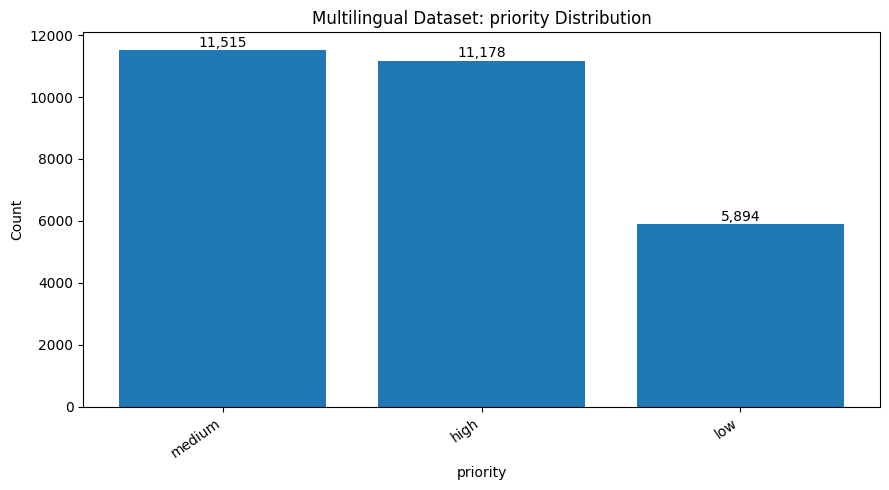

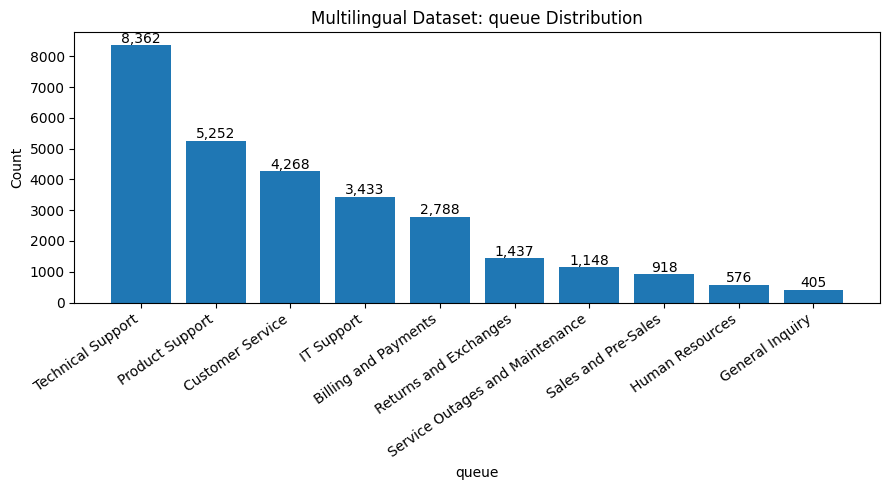

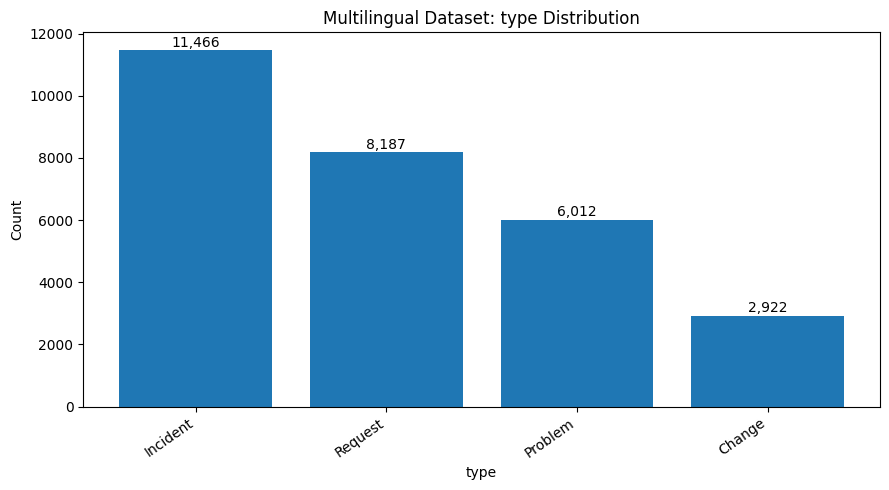

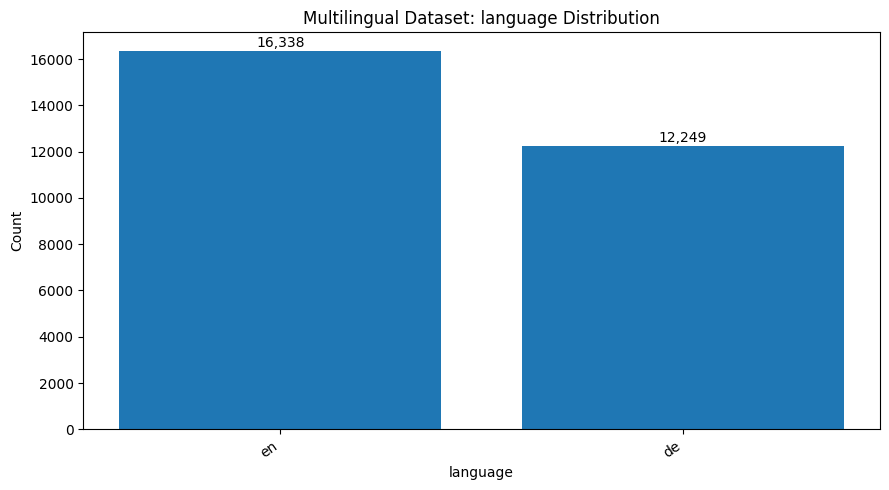


----------------------------------------------------------------------------------------------------
IT ticket classification dataset charts
----------------------------------------------------------------------------------------------------


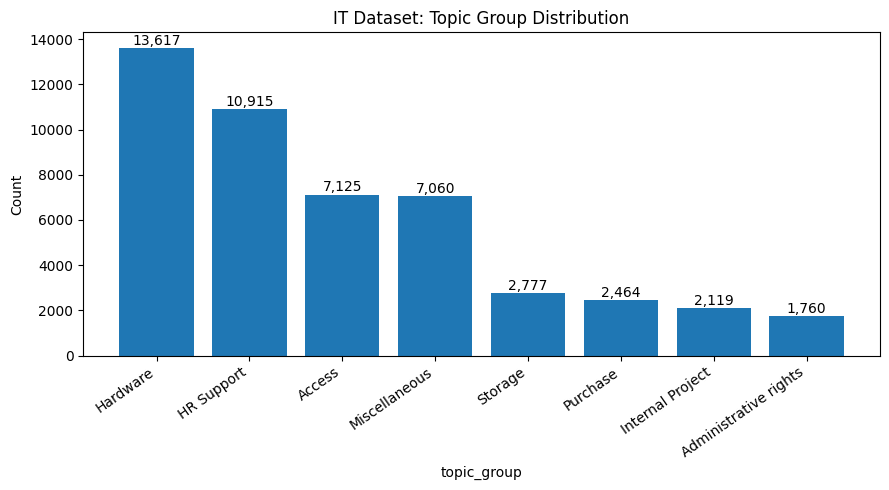


----------------------------------------------------------------------------------------------------
Customer support 200K dataset charts
----------------------------------------------------------------------------------------------------


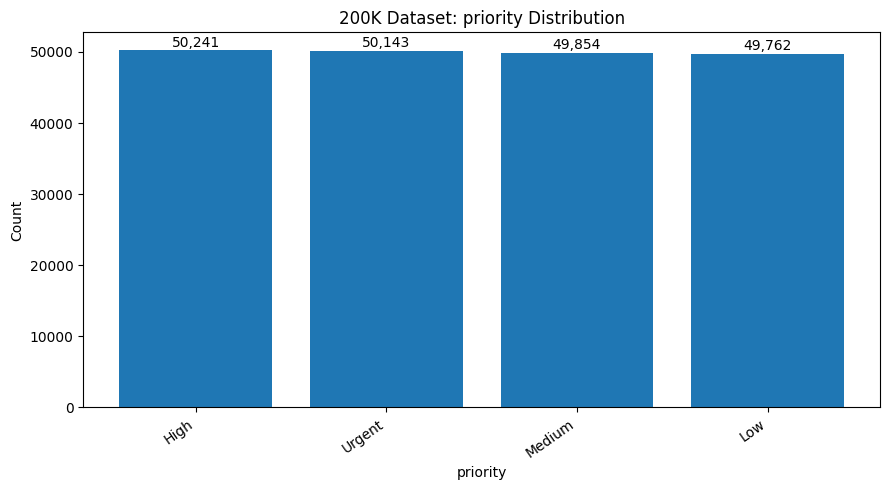

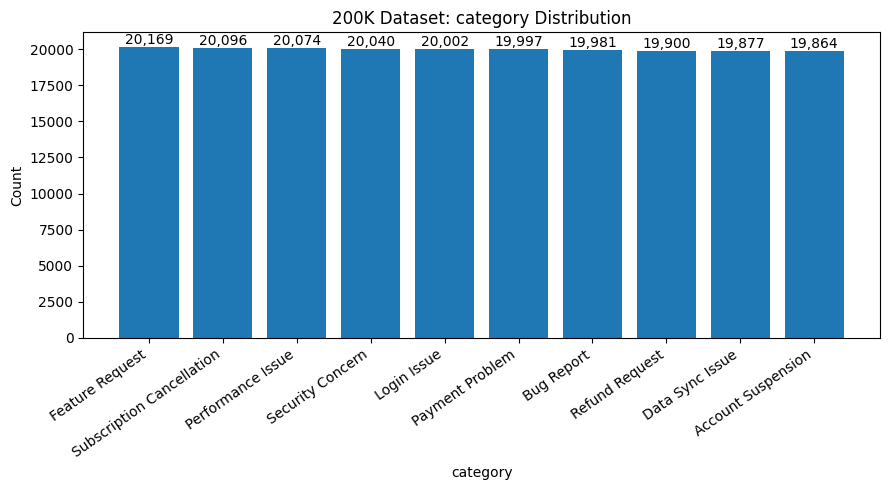

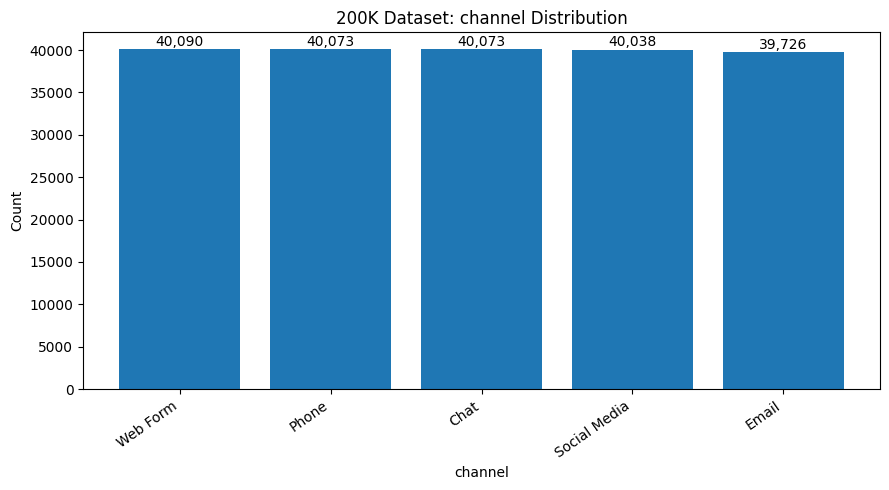

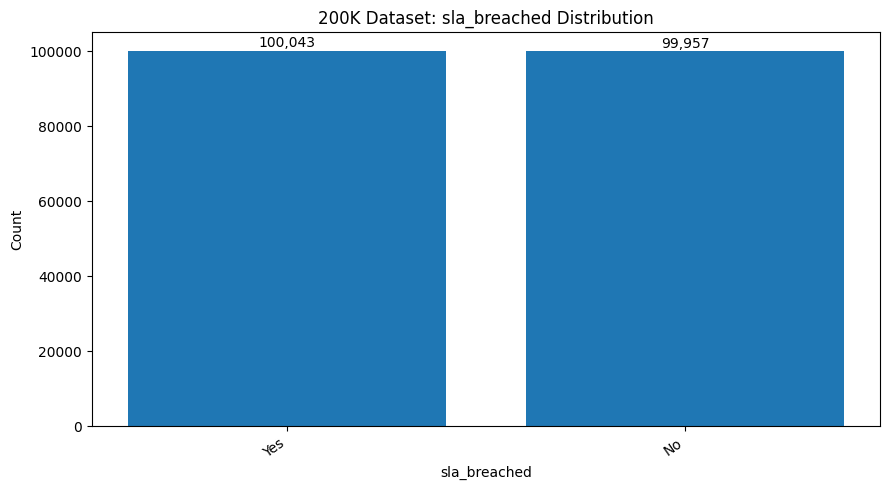

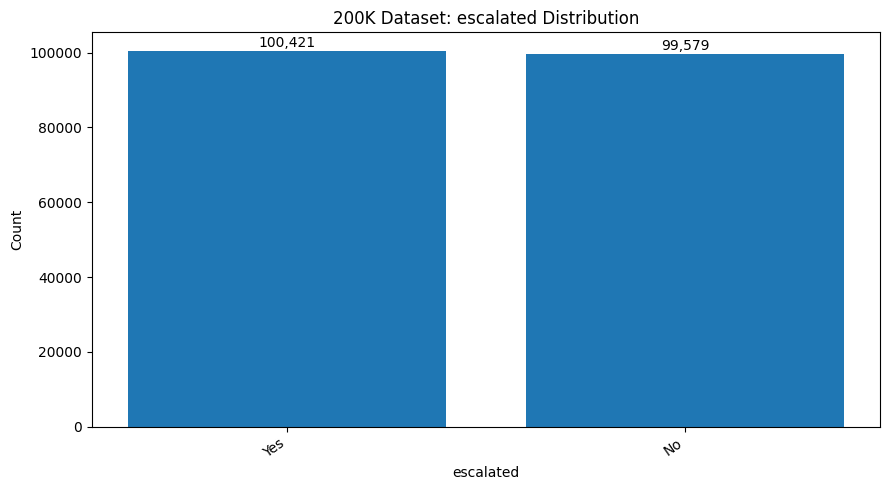

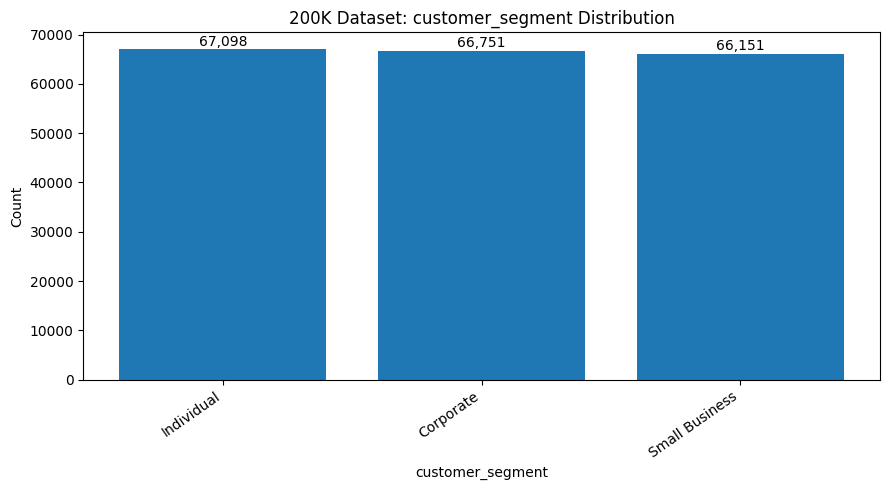


----------------------------------------------------------------------------------------------------
Mendeley issues dataset charts
----------------------------------------------------------------------------------------------------


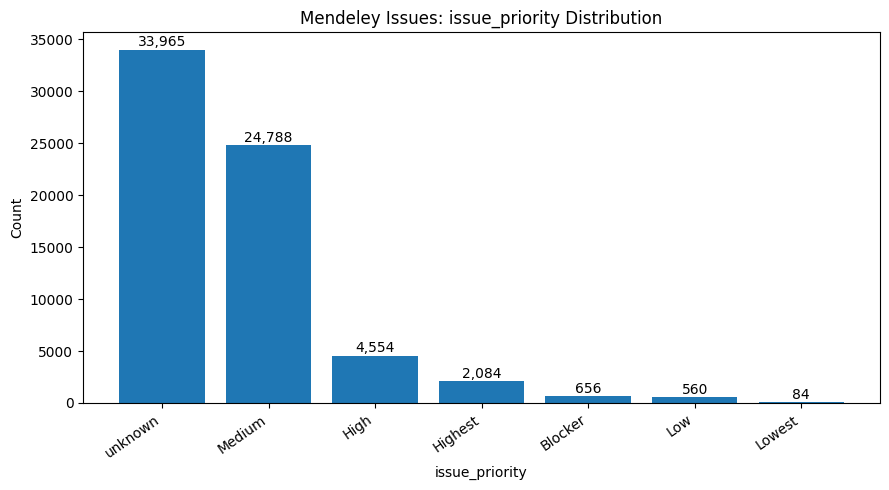

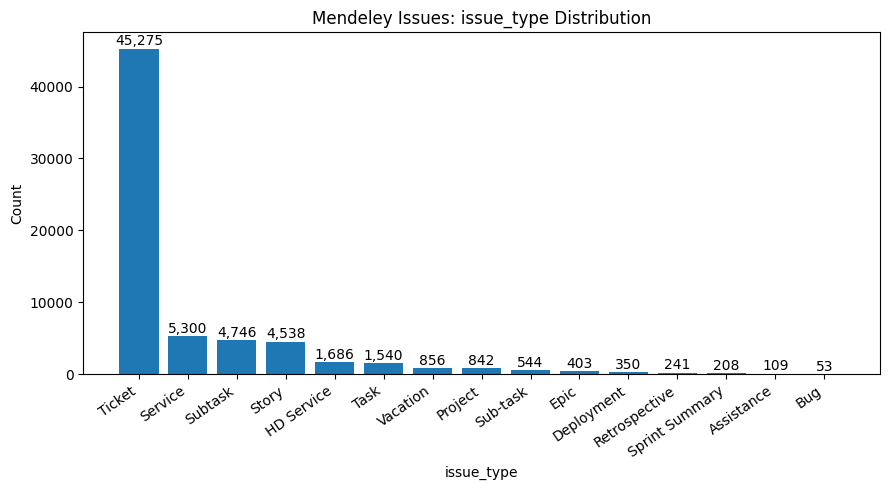

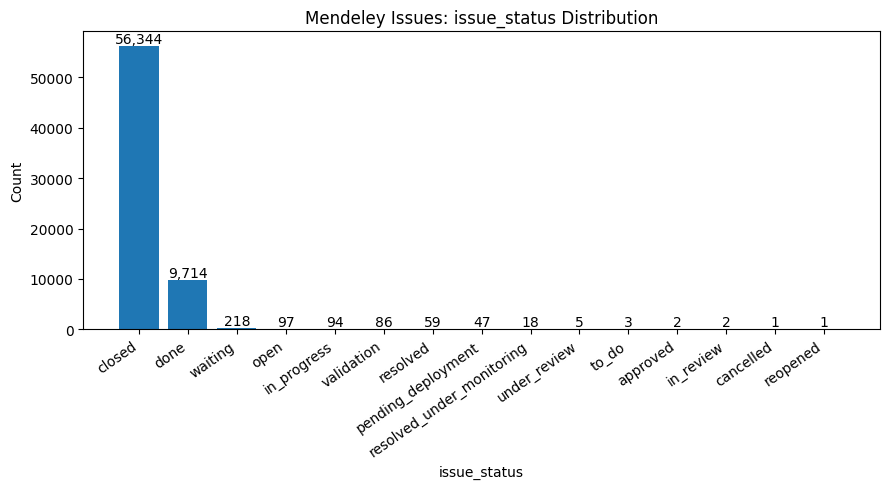


----------------------------------------------------------------------------------------------------
Sample utterances dataset charts
----------------------------------------------------------------------------------------------------


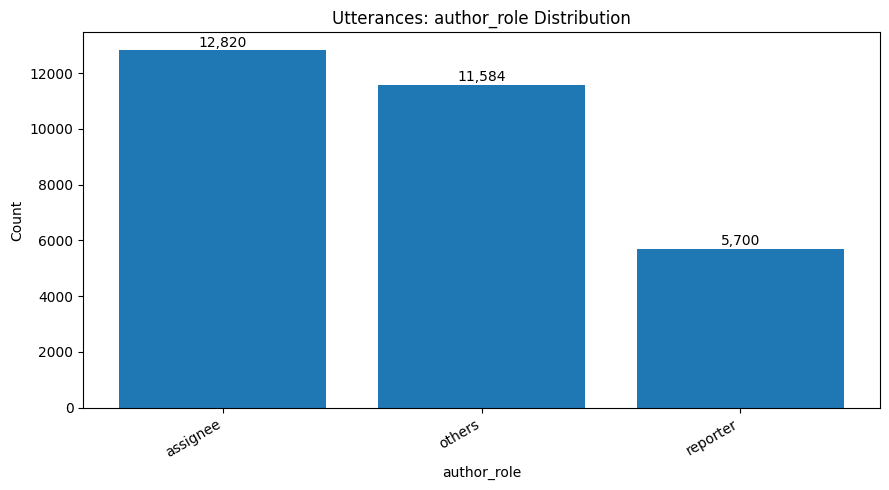

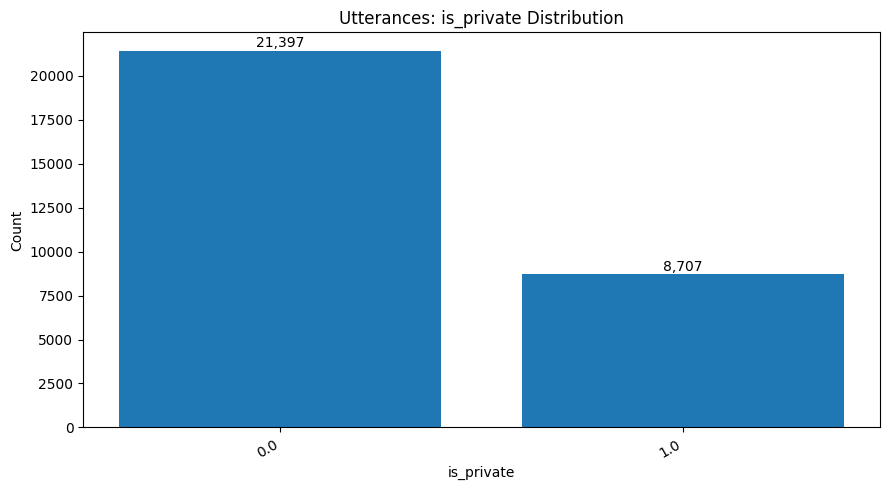


DATASET PREVIEWS

Preview: multi_lang_tickets


,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN


Showing first 3 rows out of 28,587 rows.

Preview: it_ticket_classification


,document,topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware


Showing first 3 rows out of 47,837 rows.

Preview: customer_support_200k


...

Showing first 3 rows out of 257,508 rows.

Preview: issues_snapshot_sample


,id,no,project,reporter,type,priority,contributors,turn_no,assignee,started,ended,spent_hours,steps,comments_count,valid,q1,q2,q3,notes
0,1004298.0,346.0,C11gg0w13,.wy0w13yhr,Ticket,High,1.0,1,4ops,2022-01-02 11:12:51+00:00,2022-05-24 05:40:13+00:00,3402.456,2,49,True,5,5,5,This is an HD-Service
1,1004357.0,155.0,C01gg1_3_,z8y1_3_ygi,Ticket,Medium,1.0,1,4lip,2022-01-05 05:27:14+00:00,2022-01-12 07:47:47+00:00,170.342,3,4,True,3,4,4,This is an HD-Service and looks like communica...
2,1004361.0,14.0,C02hk0x93,0ny0x93yik,Ticket,Medium,3.0,1,4hghs,2022-01-05 06:50:56+00:00,2022-01-05 06:55:23+00:00,0.074,2,3,True,5,5,5,Service Desk user did his work perfectly same ...


Showing first 3 rows out of 747 rows.

Preview: sample_utterances


,issueid,id,comment_seq,utr_seq,author,created,is_private,actionbody,author_role
0,1004298.0,211718014.0,0,0,.wy0w13yhr,2022-01-02 11:12:51+00:00,0.0,dear ph_name team,reporter
1,1004298.0,211718014.0,0,1,.wy0w13yhr,2022-01-02 11:12:51+00:00,0.0,we need your urgent support to fix list of vul...,reporter
2,1004298.0,211718014.0,0,2,.wy0w13yhr,2022-01-02 11:12:51+00:00,0.0,please provide resolution date before end of ‘...,reporter


Showing first 3 rows out of 30,104 rows.


In [16]:
section_header("SECTION 2: LOAD ALL DATASETS + CLEAN DATASET SUMMARY DISPLAY")

# PART A: DEFINE RAW DATASET FILE

DATA_FILES = {
    "multi_lang_tickets": "aa_dataset-tickets-multi-lang-5-2-50-version.csv",
    "it_ticket_classification": "all_tickets_processed_improved_v3.csv",
    "customer_support_200k": "customer_support_tickets_200k.csv",
    "issues_snapshot": "issues_snapshot.csv",
    "issues": "issues.csv",
    "issues_change_history": "issues_change_history.csv",
    "issues_snapshot_sample": "issues_snapshot_sample.xlsx",
    "sample_utterances": "sample_utterances.csv"
}

print("Expected dataset files:")
for dataset_name, file_name in DATA_FILES.items():
    print(f"- {dataset_name}: {file_name}")

# PART B: HELPER FUNCTION TO STANDARDIZE COLUMN NAME

def clean_column_names(df):
    """
    Standardizes column names:
    - lowercase
    - removes spaces/special characters
    - replaces them with underscores
    """
    df = df.copy()

    clean_cols = []

    for col in df.columns:
        new_col = str(col).strip().lower()
        new_col = re.sub(r"[^a-zA-Z0-9]+", "_", new_col)
        new_col = re.sub(r"_+", "_", new_col)
        new_col = new_col.strip("_")
        clean_cols.append(new_col)

    df.columns = clean_cols

    return df


def load_dataset_from_folder(file_name):
    """
    Loads CSV or Excel file from DATASET_FOLDER.
    """
    file_path = os.path.join(DATASET_FOLDER, file_name)

    if not os.path.exists(file_path):
        print(f"File not found: {file_path}")
        return None

    try:
        if file_name.lower().endswith(".csv"):
            df = safe_load_csv(file_path)
        elif file_name.lower().endswith((".xlsx", ".xls")):
            df = safe_load_excel(file_path)
        else:
            print(f"Unsupported file type: {file_name}")
            return None

        print(f"Loaded {file_name}: {df.shape[0]:,} rows, {df.shape[1]:,} columns")
        return df

    except Exception as e:
        print(f"Error loading {file_name}: {e}")
        return None

# PART C: LOAD RAW DATASET

raw_datasets = {}

for dataset_name, file_name in DATA_FILES.items():
    subsection_header(f"Loading dataset: {dataset_name}")

    df = load_dataset_from_folder(file_name)

    if df is not None:
        raw_datasets[dataset_name] = df

print("\nLoaded datasets:")
for name, df in raw_datasets.items():
    print(f"- {name}: {df.shape[0]:,} rows, {df.shape[1]:,} columns")

# PART D: STANDARDIZE COLUMNS AND REMOVE EXACT DUPLICATE

section_header("STANDARDIZE COLUMNS AND REMOVE EXACT DUPLICATES")

datasets = {}

for name, df in raw_datasets.items():
    subsection_header(f"Processing dataset: {name}")

    cleaned_df = clean_column_names(df)

    before_rows = len(cleaned_df)
    before_cols = cleaned_df.shape[1]

    cleaned_df = cleaned_df.drop_duplicates().copy()

    after_rows = len(cleaned_df)
    removed_duplicates = before_rows - after_rows

    print(f"Original shape: {before_rows:,} rows, {before_cols:,} columns")
    print(f"Duplicate rows removed: {removed_duplicates:,}")
    print(f"Cleaned shape: {cleaned_df.shape[0]:,} rows, {cleaned_df.shape[1]:,} columns")

    datasets[name] = cleaned_df

# PART E: ASSIGN DATASETS TO EASY VARIABLE NAME

multi_lang_df = datasets.get("multi_lang_tickets")
it_class_df = datasets.get("it_ticket_classification")
support_200k_df = datasets.get("customer_support_200k")
issues_snapshot_df = datasets.get("issues_snapshot")
issues_df = datasets.get("issues")
change_history_df = datasets.get("issues_change_history")
snapshot_sample_df = datasets.get("issues_snapshot_sample")
utterances_df = datasets.get("sample_utterances")

print("\nEasy variable names created:")
print("- multi_lang_df")
print("- it_class_df")
print("- support_200k_df")
print("- issues_snapshot_df")
print("- issues_df")
print("- change_history_df")
print("- snapshot_sample_df")
print("- utterances_df")

# PART F: DATASET OVERVIEW TABL

section_header("DATASET OVERVIEW TABLE")

overview_rows = []

for name, df in datasets.items():
    overview_rows.append({
        "dataset_name": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "duplicate_rows_after_cleaning": df.duplicated().sum(),
        "total_missing_values": int(df.isna().sum().sum()),
        "missing_value_percent_overall": round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2)
    })

dataset_overview_df = pd.DataFrame(overview_rows)

display(dataset_overview_df)

save_output(dataset_overview_df, "dataset_overview_summary.csv")

# PART G: DATASET COLUMN LIS

section_header("DATASET COLUMN LIST")

column_summary_rows = []

for name, df in datasets.items():
    column_summary_rows.append({
        "dataset_name": name,
        "column_count": df.shape[1],
        "columns": ", ".join(df.columns.tolist())
    })

dataset_column_summary_df = pd.DataFrame(column_summary_rows)

display(dataset_column_summary_df)

save_output(dataset_column_summary_df, "dataset_column_summary.csv")

# PART H: MISSING VALUE SUMMARY FOR EACH DATASE

section_header("MISSING VALUE SUMMARY BY DATASET")

missing_summary_all = []

for name, df in datasets.items():
    subsection_header(f"Missing values: {name}")

    miss_df = missing_value_summary(df)
    miss_df.insert(0, "dataset_name", name)

    missing_summary_all.append(miss_df)

    # Display only columns with missing values first
    miss_nonzero = miss_df[miss_df["missing_count"] > 0].copy()

    if miss_nonzero.empty:
        print("No missing values found.")
    else:
        display(miss_nonzero.head(25))

if missing_summary_all:
    full_missing_summary_df = pd.concat(missing_summary_all, ignore_index=True)
    save_output(full_missing_summary_df, "full_missing_value_summary.csv")

# PART I: TARGET-LIKE COLUMN DISTRIBUTION

section_header("TARGET-LIKE COLUMN DISTRIBUTIONS")

target_like_columns = [
    "priority",
    "issue_priority",
    "queue",
    "topic_group",
    "category",
    "type",
    "issue_type",
    "status",
    "issue_status",
    "sla_breached",
    "escalated",
    "author_role",
    "is_private",
    "language",
    "channel",
    "customer_segment",
    "subscription_type"
]

target_distribution_outputs = []

for name, df in datasets.items():
    subsection_header(f"Target-like distributions: {name}")

    found_any = False

    for col in target_like_columns:
        if col in df.columns:
            found_any = True

            dist_df = categorical_distribution(df, col, top_n=20)
            dist_df.insert(0, "dataset_name", name)
            dist_df.insert(1, "column_name", col)

            target_distribution_outputs.append(dist_df)

            print(f"\nColumn: {col}")
            display(dist_df.head(20))

    if not found_any:
        print("No common target-like columns found.")

if target_distribution_outputs:
    full_target_distribution_df = pd.concat(target_distribution_outputs, ignore_index=True)
    save_output(full_target_distribution_df, "target_like_column_distributions.csv")

# PART J: TEXT COLUMN SUMMAR

section_header("TEXT COLUMN SUMMARY")

known_text_columns_by_dataset = {
    "multi_lang_tickets": ["subject", "body", "answer"],
    "it_ticket_classification": ["document"],
    "customer_support_200k": ["issue_description", "resolution_notes"],
    "sample_utterances": ["actionbody"],
    "issues": [],
    "issues_snapshot": [],
    "issues_change_history": [],
    "issues_snapshot_sample": ["notes"]
}


def text_column_summary(df, text_cols):
    """
    Summarizes text columns by length and word count.
    """
    rows = []

    for col in text_cols:
        if col in df.columns:
            temp = df[col].fillna("").astype(str)

            rows.append({
                "text_column": col,
                "non_empty_rows": int((temp.str.strip() != "").sum()),
                "empty_rows": int((temp.str.strip() == "").sum()),
                "avg_char_length": round(temp.str.len().mean(), 2),
                "median_char_length": round(temp.str.len().median(), 2),
                "avg_word_count": round(temp.apply(lambda x: len(x.split())).mean(), 2),
                "median_word_count": round(temp.apply(lambda x: len(x.split())).median(), 2)
            })

    return pd.DataFrame(rows)


text_summary_outputs = []

for name, df in datasets.items():
    text_cols = known_text_columns_by_dataset.get(name, [])

    summary_df = text_column_summary(df, text_cols)

    if not summary_df.empty:
        summary_df.insert(0, "dataset_name", name)
        text_summary_outputs.append(summary_df)

if text_summary_outputs:
    full_text_summary_df = pd.concat(text_summary_outputs, ignore_index=True)
    display(full_text_summary_df)
    save_output(full_text_summary_df, "text_column_summary.csv")
else:
    print("No known text columns found for summary.")

# PART K: BASIC VISUAL CHECK

section_header("BASIC VISUAL CHECKS")

# Multilingual dataset
if multi_lang_df is not None:
    subsection_header("Multilingual ticket dataset charts")

    for col in ["priority", "queue", "type", "language"]:
        if col in multi_lang_df.columns:
            plot_value_counts(
                multi_lang_df,
                col,
                title=f"Multilingual Dataset: {col} Distribution",
                top_n=12,
                rotation=35
            )

# IT classification dataset
if it_class_df is not None:
    subsection_header("IT ticket classification dataset charts")

    if "topic_group" in it_class_df.columns:
        plot_value_counts(
            it_class_df,
            "topic_group",
            title="IT Dataset: Topic Group Distribution",
            top_n=12,
            rotation=35
        )

# Customer support 200K dataset
if support_200k_df is not None:
    subsection_header("Customer support 200K dataset charts")

    for col in ["priority", "category", "channel", "sla_breached", "escalated", "customer_segment"]:
        if col in support_200k_df.columns:
            plot_value_counts(
                support_200k_df,
                col,
                title=f"200K Dataset: {col} Distribution",
                top_n=12,
                rotation=35
            )

# Mendeley issues dataset
if issues_df is not None:
    subsection_header("Mendeley issues dataset charts")

    for col in ["issue_priority", "issue_type", "issue_status"]:
        if col in issues_df.columns:
            plot_value_counts(
                issues_df,
                col,
                title=f"Mendeley Issues: {col} Distribution",
                top_n=15,
                rotation=35
            )

# Utterances dataset
if utterances_df is not None:
    subsection_header("Sample utterances dataset charts")

    for col in ["author_role", "is_private"]:
        if col in utterances_df.columns:
            plot_value_counts(
                utterances_df,
                col,
                title=f"Utterances: {col} Distribution",
                top_n=10,
                rotation=30
            )

# PART L: PREVIEW EACH DATASET

section_header("DATASET PREVIEWS")

for name, df in datasets.items():
    display_table(
        df,
        title=f"Preview: {name}",
        max_rows=3
    )

## Section 3: Clean and Prepare Modeling Datasets

This section prepares the raw datasets for modeling and analysis. It cleans text fields, standardizes labels, maps priorities into simple categories, creates binary targets, processes dates, and adds useful keyword-based features.

The output of this section is a set of clean datasets for different project tasks, including priority prediction, queue routing, SLA analysis, dashboard creation, and response generation examples. This step is important because clean and consistent data improves model quality and makes the final outputs easier to explain.


SECTION 3: CLEAN AND PREPARE MODELING DATASETS

PART B: CLEAN MULTILINGUAL TICKET DATASET
Rows removed due to short ticket text: 25
Clean multilingual dataset shape: (28562, 44)

Multilingual Priority Model Dataset Preview


,ticket_text,ticket_text_with_tags,subject_clean,body_clean,priority_3class,is_high_priority,queue_label,ticket_type_label,language_label,has_outage_keyword,has_payment_keyword,has_access_keyword,has_technical_keyword,has_hardware_keyword,has_urgent_keyword,text_length,word_count,question_mark_count,exclamation_count
0,wesentlicher sicherheitsvorfall sehr geehrtes ...,wesentlicher sicherheitsvorfall sehr geehrtes ...,wesentlicher sicherheitsvorfall,"sehr geehrtes support-team, n nich m chte eine...",High,1,Technical Support,Incident,De,0,0,0,0,0,0,783,101,0,0
1,"account disruption dear customer support team,...","account disruption dear customer support team,...",account disruption,"dear customer support team, n ni am writing to...",High,1,Technical Support,Incident,En,1,0,1,0,1,0,563,88,2,0
2,query about smart home system integration feat...,query about smart home system integration feat...,query about smart home system integration feat...,"dear customer support team, n ni hope this mes...",Medium,0,Returns And Exchanges,Request,En,0,0,0,1,0,0,585,87,1,0
3,inquiry regarding invoice details dear custome...,inquiry regarding invoice details dear custome...,inquiry regarding invoice details,"dear customer support team, n ni hope this mes...",Low,0,Billing And Payments,Request,En,0,1,1,0,0,0,639,101,0,0
4,question about marketing agency software compa...,question about marketing agency software compa...,question about marketing agency software compa...,"dear support team, n ni hope this message reac...",Medium,0,Sales And Pre Sales,Problem,En,0,0,0,0,0,0,732,107,1,0


Showing first 5 rows out of 28,562 rows.

Priority distribution:


,priority_3class,count,percent
0,Medium,11505,40.28
1,High,11168,39.10
2,Low,5889,20.62



Queue distribution:


,queue_label,count,percent
0,Technical Support,8351,29.24
1,Product Support,5251,18.38
2,Customer Service,4266,14.94
3,It Support,3432,12.02
4,Billing And Payments,2783,9.74
5,Returns And Exchanges,1434,5.02
6,Service Outages And Maintenance,1148,4.02
7,Sales And Pre Sales,918,3.21
8,Human Resources,576,2.02
9,General Inquiry,403,1.41


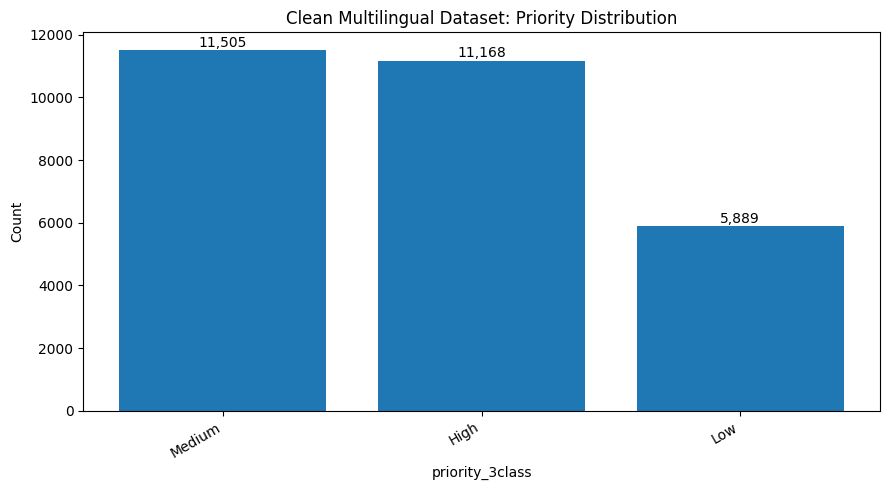

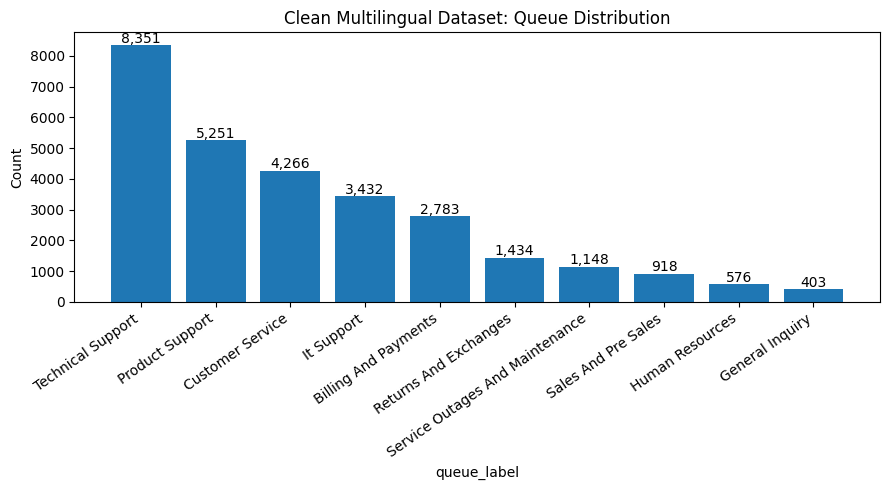

Skipped intermediate file: cleaned_multilingual_priority_model.csv
Skipped intermediate file: cleaned_multilingual_queue_model.csv
Skipped intermediate file: cleaned_multilingual_response_genai.csv

PART C: CLEAN IT TICKET CLASSIFICATION DATASET
Rows removed from IT dataset: 14
Clean IT dataset shape: (47823, 6)

IT Routing Model Dataset Preview


,ticket_text,document_word_count,routing_label,routing_description
0,connection with icon icon dear please setup ic...,18,Hardware,Physical device or equipment-related issue.
1,work experience user work experience user hi w...,19,Access,"Login, permission, account access, or system a..."
2,requesting for meeting requesting meeting hi p...,14,Hardware,Physical device or equipment-related issue.
3,reset passwords for external accounts re expir...,145,Access,"Login, permission, account access, or system a..."
4,mail verification warning hi has got attached ...,15,Miscellaneous,General issue that does not fit a specific cat...


Showing first 5 rows out of 47,823 rows.

IT routing label distribution:


,routing_label,count,percent
0,Hardware,13611,28.46
1,Hr Support,10911,22.82
2,Access,7124,14.90
3,Miscellaneous,7058,14.76
4,Storage,2777,5.81
5,Purchase,2463,5.15
6,Internal Project,2119,4.43
7,Administrative Rights,1760,3.68


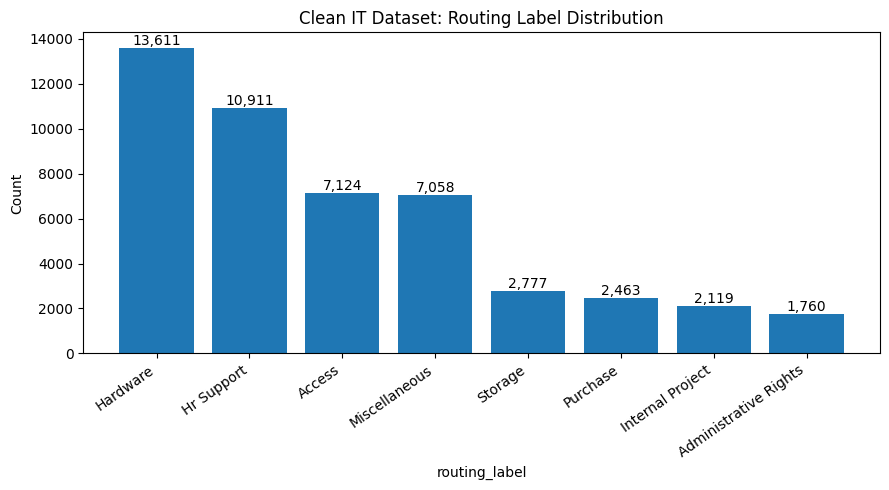

Skipped intermediate file: cleaned_it_routing_model.csv

PART D: CLEAN CUSTOMER SUPPORT 200K DATASET
Clean 200K support dataset shape: (200000, 76)
Dashboard dataset shape: (200000, 32)
SLA model dataset shape: (200000, 29)
Escalation model dataset shape: (200000, 29)
Support priority model dataset shape: (200000, 30)

Customer Support 200K Dashboard Dataset Preview


,ticket_id,product,category,priority,priority_3class,status,channel,region,subscription_type,customer_tenure_months,...,issue_complexity_score,customer_segment,responded_within_4_hours,long_resolution_over_72_hours,low_satisfaction,high_complexity_issue,sla_breached_label,escalated_label,first_response_time_bucket,resolution_time_bucket
0,1,Web Portal,Account Suspension,Urgent,High,Open,Email,North America,Free,36.0,...,4.0,Small Business,0,1,0,0,SLA Breach,Not Escalated,1-3 days,3-5 days
1,2,Mobile App,Performance Issue,Urgent,High,Closed,Email,South America,Premium,54.0,...,2.0,Small Business,0,1,0,0,SLA Breach,Escalated,1-3 days,3-5 days
2,3,Web Portal,Performance Issue,Medium,Medium,Closed,Chat,Europe,Premium,60.0,...,4.0,Corporate,0,1,0,0,SLA Breach,Escalated,12-24 hours,3-5 days
3,4,Payment Gateway,Subscription Cancellation,Medium,Medium,Closed,Social Media,Asia,Enterprise,58.0,...,7.0,Corporate,0,1,0,0,No SLA Breach,Escalated,1-3 days,Over 7 days
4,5,Web Portal,Feature Request,High,High,Pending Customer,Email,Asia,Enterprise,1.0,...,3.0,Corporate,0,1,0,0,No SLA Breach,Escalated,1-3 days,5-7 days


Showing first 5 rows out of 200,000 rows.

Priority distribution:


,priority_3class,count,percent
0,High,100384,50.19
1,Medium,49854,24.93
2,Low,49762,24.88



SLA breach distribution:


...

Skipped intermediate file: cleaned_mendeley_priority_model_safe_features.csv

PART F: RECONSTRUCT SAMPLE UTTERANCES INTO RESPONSE PAIRS
Mendeley response pairs shape: (325, 11)

Mendeley Customer Message to Agent Response Pairs Preview


,issueid,customer_message_time,customer_message,support_response_time,support_response,first_response_time_minutes,id,issue_type,priority_3class,is_high_priority,source_dataset
0,1004298.0,2022-01-02 11:12:51+00:00,dear ph name team we need your urgent support ...,2022-01-02 11:17:42+00:00,greetings report is not clear and contains poi...,4.850000,1004298.0,Ticket,High,1.0,mendeley_sample_utterances
1,1004361.0,2022-01-05 06:50:56+00:00,greetings we are encountering a force logout i...,2022-01-05 06:52:24+00:00,greetings kindly be informed that your ticket ...,1.466667,1004361.0,Ticket,Medium,0.0,mendeley_sample_utterances
2,1004362.0,2022-01-05 07:37:19+00:00,greetings in the ph item ph user when the user...,2022-01-05 07:39:28+00:00,greetings kindly be informed that your ticket ...,2.150000,1004362.0,Ticket,Medium,0.0,mendeley_sample_utterances
3,1004364.0,2022-01-05 08:06:25+00:00,greetings please find the attached files as re...,2022-01-05 08:08:03+00:00,greetings kindly be informed that your ticket ...,1.633333,1004364.0,Ticket,Medium,0.0,mendeley_sample_utterances
4,1004368.0,2022-01-05 09:00:41+00:00,dears i have inward ph item hang on ph technic...,2022-01-05 09:01:46+00:00,greetings kindly be informed that your ticket ...,1.083333,1004368.0,Ticket,High,1.0,mendeley_sample_utterances


Showing first 5 rows out of 325 rows.
Skipped intermediate file: cleaned_mendeley_response_pairs.csv

SECTION 3 OUTPUT OBJECT CHECK


,object_name,rows,columns,ready
0,multi_priority_model_df,28562,19,True
1,multi_queue_model_df,28562,20,True
2,multi_response_genai_df,28430,8,True
3,it_routing_model_df,47823,4,True
4,support_dashboard_df,200000,32,True
5,sla_model_df,200000,29,True
6,escalation_model_df,200000,29,True
7,support_priority_model_df,200000,30,True
8,support_response_genai_df,200000,9,True
9,mendeley_priority_model_df,23153,12,True


Skipped intermediate file: section3_clean_dataset_object_summary.csv


In [17]:
section_header("SECTION 3: CLEAN AND PREPARE MODELING DATASETS")

# PART A: GENERAL LABEL CLEANING FUNCTIONS

def clean_label(value):
    """
    Cleans categorical labels.
    """
    if pd.isna(value):
        return "unknown"

    value = str(value).strip().lower()
    value = re.sub(r"[_\-]+", " ", value)
    value = re.sub(r"\s+", " ", value)

    if value in ["", "nan", "none", "null", "na", "n/a"]:
        return "unknown"

    return value


def title_label(value):
    """
    Converts cleaned label to readable title case.
    """
    value = clean_label(value)

    if value == "unknown":
        return "Unknown"

    return value.title()


def map_priority_to_3class(priority):
    """
    Maps many possible priority labels into Low / Medium / High.
    """
    p = clean_label(priority)

    high_values = [
        "high", "urgent", "critical", "blocker", "p1", "sev1",
        "severity 1", "major", "emergency", "highest"
    ]

    medium_values = [
        "medium", "normal", "moderate", "p2", "p3",
        "sev2", "severity 2", "standard"
    ]

    low_values = [
        "low", "minor", "trivial", "p4", "p5",
        "sev3", "sev4", "lowest"
    ]

    if p in high_values:
        return "High"
    elif p in medium_values:
        return "Medium"
    elif p in low_values:
        return "Low"
    else:
        return np.nan


def binary_yes_no(value):
    """
    Converts yes/no-style values into 1/0.
    """
    v = clean_label(value)

    yes_values = ["yes", "y", "true", "1", "breached", "escalated"]
    no_values = ["no", "n", "false", "0", "not breached", "not escalated"]

    if v in yes_values:
        return 1
    elif v in no_values:
        return 0
    else:
        return np.nan


# PART B: CLEAN MULTILINGUAL TICKET DATASET

section_header("PART B: CLEAN MULTILINGUAL TICKET DATASET")

if multi_lang_df is not None:
    multi_df = multi_lang_df.copy()

    # 1. Clean categorical columns

    for col in ["type", "queue", "priority", "language"]:
        if col in multi_df.columns:
            multi_df[col + "_clean"] = multi_df[col].apply(clean_label)
            multi_df[col + "_label"] = multi_df[col].apply(title_label)

    # 2. Clean text columns

    for col in ["subject", "body", "answer"]:
        if col in multi_df.columns:
            multi_df[col + "_clean"] = multi_df[col].apply(clean_text_basic)

    # 3. Create ticket text

    subject_col = "subject_clean" if "subject_clean" in multi_df.columns else "subject"
    body_col = "body_clean" if "body_clean" in multi_df.columns else "body"

    multi_df["ticket_text"] = (
        multi_df[subject_col].fillna("").astype(str) + " " +
        multi_df[body_col].fillna("").astype(str)
    ).str.strip()

    multi_df["ticket_text"] = multi_df["ticket_text"].apply(clean_text_basic)
    multi_df["ticket_text_word_count"] = multi_df["ticket_text"].apply(lambda x: len(x.split()))

    # 4. Standardize priority

    if "priority_clean" in multi_df.columns:
        multi_df["priority_3class"] = multi_df["priority_clean"].apply(map_priority_to_3class)
    elif "priority" in multi_df.columns:
        multi_df["priority_3class"] = multi_df["priority"].apply(map_priority_to_3class)
    else:
        multi_df["priority_3class"] = np.nan

    multi_df = multi_df[multi_df["priority_3class"].notna()].copy()

    multi_df["is_high_priority"] = np.where(
        multi_df["priority_3class"] == "High",
        1,
        0
    )

    # 5. Standardize queue, type, and language labels

    if "queue_label" not in multi_df.columns and "queue" in multi_df.columns:
        multi_df["queue_label"] = multi_df["queue"].apply(title_label)

    if "type_label" in multi_df.columns:
        multi_df["ticket_type_label"] = multi_df["type_label"]
    elif "type" in multi_df.columns:
        multi_df["ticket_type_label"] = multi_df["type"].apply(title_label)
    else:
        multi_df["ticket_type_label"] = "Unknown"

    if "language_label" not in multi_df.columns and "language" in multi_df.columns:
        multi_df["language_label"] = multi_df["language"].apply(title_label)
    elif "language_label" not in multi_df.columns:
        multi_df["language_label"] = "Unknown"

    # 6. Combine tag columns if present

    tag_cols = [col for col in multi_df.columns if col.startswith("tag")]

    for col in tag_cols:
        multi_df[col] = multi_df[col].fillna("").astype(str).apply(clean_label)

    def combine_tags(row):
        tags = []

        for col in tag_cols:
            value = row.get(col, "")
            if value not in ["", "unknown", "nan", "none"]:
                tags.append(value)

        return " ".join(tags)

    if tag_cols:
        multi_df["combined_tags"] = multi_df.apply(combine_tags, axis=1)
    else:
        multi_df["combined_tags"] = ""

    multi_df["ticket_text_with_tags"] = (
        multi_df["ticket_text"] + " " + multi_df["combined_tags"]
    ).str.strip()

    multi_df["ticket_text_with_tags"] = multi_df["ticket_text_with_tags"].apply(clean_text_basic)

    # 7. Add explainable keyword features

    multi_df = create_keyword_flags(multi_df, "ticket_text")

    # 8. Remove weak rows

    before_rows = len(multi_df)

    multi_df = multi_df[
        multi_df["ticket_text_word_count"] >= 5
    ].copy()

    removed_rows = before_rows - len(multi_df)

    print(f"Rows removed due to short ticket text: {removed_rows:,}")
    print("Clean multilingual dataset shape:", multi_df.shape)

    # 9. Create priority model dataset

    priority_cols = [
        "ticket_text",
        "ticket_text_with_tags",
        "subject_clean",
        "body_clean",
        "priority_3class",
        "is_high_priority",
        "queue_label",
        "ticket_type_label",
        "language_label",
        "has_outage_keyword",
        "has_payment_keyword",
        "has_access_keyword",
        "has_technical_keyword",
        "has_hardware_keyword",
        "has_urgent_keyword",
        "text_length",
        "word_count",
        "question_mark_count",
        "exclamation_count"
    ]

    priority_cols = [col for col in priority_cols if col in multi_df.columns]

    multi_priority_model_df = multi_df[priority_cols].copy()

    # 10. Create queue routing dataset

    queue_cols = [
        "ticket_text",
        "ticket_text_with_tags",
        "subject_clean",
        "body_clean",
        "queue_label",
        "priority_3class",
        "is_high_priority",
        "ticket_type_label",
        "language_label",
        "combined_tags",
        "has_outage_keyword",
        "has_payment_keyword",
        "has_access_keyword",
        "has_technical_keyword",
        "has_hardware_keyword",
        "has_urgent_keyword",
        "text_length",
        "word_count",
        "question_mark_count",
        "exclamation_count"
    ]

    queue_cols = [col for col in queue_cols if col in multi_df.columns]

    multi_queue_model_df = multi_df[queue_cols].copy()

    # 11. Create response example dataset

    if "answer_clean" in multi_df.columns:
        multi_df["answer_text"] = multi_df["answer_clean"].fillna("").astype(str).str.strip()
    elif "answer" in multi_df.columns:
        multi_df["answer_text"] = multi_df["answer"].fillna("").astype(str).apply(clean_text_basic)
    else:
        multi_df["answer_text"] = ""

    multi_df["answer_word_count"] = multi_df["answer_text"].apply(lambda x: len(x.split()))

    response_cols = [
        "ticket_text",
        "subject_clean",
        "body_clean",
        "answer_text",
        "priority_3class",
        "queue_label",
        "ticket_type_label",
        "language_label"
    ]

    response_cols = [col for col in response_cols if col in multi_df.columns]

    multi_response_genai_df = multi_df[
        multi_df["answer_word_count"] >= 5
    ][response_cols].copy()

    # 12. Display summaries

    display_table(
        multi_priority_model_df,
        title="Multilingual Priority Model Dataset Preview",
        max_rows=5
    )

    print("\nPriority distribution:")
    display(categorical_distribution(multi_priority_model_df, "priority_3class"))

    print("\nQueue distribution:")
    display(categorical_distribution(multi_queue_model_df, "queue_label", top_n=15))

    plot_value_counts(
        multi_priority_model_df,
        "priority_3class",
        title="Clean Multilingual Dataset: Priority Distribution",
        top_n=10
    )

    plot_value_counts(
        multi_queue_model_df,
        "queue_label",
        title="Clean Multilingual Dataset: Queue Distribution",
        top_n=12,
        rotation=35
    )

    # 13. Save clean datasets

    save_output(multi_priority_model_df, "cleaned_multilingual_priority_model.csv")
    save_output(multi_queue_model_df, "cleaned_multilingual_queue_model.csv")
    save_output(multi_response_genai_df, "cleaned_multilingual_response_genai.csv")

else:
    print("multi_lang_df not loaded.")
    multi_priority_model_df = pd.DataFrame()
    multi_queue_model_df = pd.DataFrame()
    multi_response_genai_df = pd.DataFrame()


# PART C: CLEAN IT TICKET CLASSIFICATION DATASET

section_header("PART C: CLEAN IT TICKET CLASSIFICATION DATASET")

if it_class_df is not None:
    it_df = it_class_df.copy()

    # 1. Clean text and labels

    if "document" in it_df.columns:
        it_df["document_clean"] = it_df["document"].apply(clean_text_basic)
    else:
        it_df["document_clean"] = ""

    if "topic_group" in it_df.columns:
        it_df["topic_group_clean"] = it_df["topic_group"].apply(clean_label)
        it_df["topic_group_label"] = it_df["topic_group"].apply(title_label)
    else:
        it_df["topic_group_clean"] = "unknown"
        it_df["topic_group_label"] = "Unknown"

    it_df["document_word_count"] = it_df["document_clean"].apply(lambda x: len(x.split()))

    # 2. Remove weak rows and duplicate text-label pairs

    before_rows = len(it_df)

    it_df = it_df[
        (it_df["document_word_count"] >= 3) &
        (it_df["topic_group_clean"] != "unknown")
    ].copy()

    it_df = it_df.drop_duplicates(
        subset=["document_clean", "topic_group_label"]
    ).copy()

    removed_rows = before_rows - len(it_df)

    print(f"Rows removed from IT dataset: {removed_rows:,}")
    print("Clean IT dataset shape:", it_df.shape)

    # 3. Create routing model dataset

    it_routing_model_df = it_df[
        [
            "document_clean",
            "document_word_count",
            "topic_group_label"
        ]
    ].rename(columns={
        "document_clean": "ticket_text",
        "topic_group_label": "routing_label"
    }).copy()

    # 4. Add descriptions

    routing_descriptions = {
        "Hardware": "Physical device or equipment-related issue.",
        "Hr Support": "HR or employee support request.",
        "Access": "Login, permission, account access, or system access issue.",
        "Miscellaneous": "General issue that does not fit a specific category.",
        "Storage": "Storage, disk, backup, or shared folder issue.",
        "Purchase": "Purchase, procurement, or vendor request.",
        "Internal Project": "Internal project support request.",
        "Administrative Rights": "Admin rights or elevated permission request."
    }

    it_routing_model_df["routing_description"] = (
        it_routing_model_df["routing_label"]
        .map(routing_descriptions)
        .fillna("Support ticket category.")
    )

    display_table(
        it_routing_model_df,
        title="IT Routing Model Dataset Preview",
        max_rows=5
    )

    print("\nIT routing label distribution:")
    display(categorical_distribution(it_routing_model_df, "routing_label", top_n=15))

    plot_value_counts(
        it_routing_model_df,
        "routing_label",
        title="Clean IT Dataset: Routing Label Distribution",
        top_n=12,
        rotation=35
    )

    save_output(it_routing_model_df, "cleaned_it_routing_model.csv")

else:
    print("it_class_df not loaded.")
    it_routing_model_df = pd.DataFrame()


# PART D: CLEAN CUSTOMER SUPPORT 200K DATASET

section_header("PART D: CLEAN CUSTOMER SUPPORT 200K DATASET")

if support_200k_df is not None:
    support_df = support_200k_df.copy()

    # 1. Clean text columns

    for col in ["issue_description", "resolution_notes"]:
        if col in support_df.columns:
            support_df[col + "_clean"] = support_df[col].apply(clean_text_basic)

    if "issue_description_clean" in support_df.columns:
        support_df["issue_text"] = support_df["issue_description_clean"].fillna("").astype(str)
    else:
        support_df["issue_text"] = ""

    support_df["issue_text_word_count"] = support_df["issue_text"].apply(lambda x: len(x.split()))

    if "resolution_notes_clean" in support_df.columns:
        support_df["resolution_text"] = support_df["resolution_notes_clean"].fillna("").astype(str)
        support_df["resolution_text_word_count"] = support_df["resolution_text"].apply(lambda x: len(x.split()))
    else:
        support_df["resolution_text"] = ""
        support_df["resolution_text_word_count"] = 0

    # 2. Clean categorical columns

    support_categorical_cols = [
        "product",
        "category",
        "priority",
        "status",
        "channel",
        "region",
        "customer_gender",
        "subscription_type",
        "operating_system",
        "browser",
        "payment_method",
        "language",
        "preferred_contact_time",
        "customer_segment",
        "escalated",
        "sla_breached"
    ]

    for col in support_categorical_cols:
        if col in support_df.columns:
            support_df[col + "_clean"] = support_df[col].apply(clean_label)

    # 3. Standardize priority

    if "priority_clean" in support_df.columns:
        support_df["priority_3class"] = support_df["priority_clean"].apply(map_priority_to_3class)
    elif "priority" in support_df.columns:
        support_df["priority_3class"] = support_df["priority"].apply(map_priority_to_3class)
    else:
        support_df["priority_3class"] = np.nan

    support_df = support_df[
        support_df["priority_3class"].notna()
    ].copy()

    support_df["is_high_priority"] = np.where(
        support_df["priority_3class"] == "High",
        1,
        0
    )

    # 4. Convert binary fields

    if "sla_breached_clean" in support_df.columns:
        support_df["sla_breached_binary"] = support_df["sla_breached_clean"].apply(binary_yes_no)
    else:
        support_df["sla_breached_binary"] = np.nan

    if "escalated_clean" in support_df.columns:
        support_df["escalated_binary"] = support_df["escalated_clean"].apply(binary_yes_no)
    else:
        support_df["escalated_binary"] = np.nan

    # 5. Convert dates and create date features

    for col in ["ticket_created_date", "ticket_resolved_date"]:
        if col in support_df.columns:
            support_df[col] = pd.to_datetime(support_df[col], errors="coerce")

    if "ticket_created_date" in support_df.columns:
        support_df["created_year"] = support_df["ticket_created_date"].dt.year
        support_df["created_month"] = support_df["ticket_created_date"].dt.month
        support_df["created_dayofweek"] = support_df["ticket_created_date"].dt.dayofweek
        support_df["created_hour"] = support_df["ticket_created_date"].dt.hour
        support_df["created_is_weekend"] = support_df["created_dayofweek"].isin([5, 6]).astype(int)
        support_df["created_is_business_hours"] = support_df["created_hour"].between(8, 18).astype(int)
    else:
        support_df["created_year"] = 0
        support_df["created_month"] = 0
        support_df["created_dayofweek"] = 0
        support_df["created_hour"] = 0
        support_df["created_is_weekend"] = 0
        support_df["created_is_business_hours"] = 0

    # 6. Convert numeric columns

    support_numeric_cols = [
        "customer_age",
        "customer_tenure_months",
        "previous_tickets",
        "customer_satisfaction_score",
        "first_response_time_hours",
        "resolution_time_hours",
        "issue_complexity_score"
    ]

    for col in support_numeric_cols:
        if col in support_df.columns:
            support_df[col] = pd.to_numeric(support_df[col], errors="coerce")
            support_df.loc[support_df[col] < 0, col] = np.nan
            support_df[col] = support_df[col].fillna(support_df[col].median())

    # 7. Add keyword/text features

    support_df = create_keyword_flags(support_df, "issue_text")

    # 8. Create KPI flags

    if "first_response_time_hours" in support_df.columns:
        support_df["responded_within_4_hours"] = (
            support_df["first_response_time_hours"] <= 4
        ).astype(int)

    if "resolution_time_hours" in support_df.columns:
        support_df["long_resolution_over_72_hours"] = (
            support_df["resolution_time_hours"] > 72
        ).astype(int)

    if "customer_satisfaction_score" in support_df.columns:
        support_df["low_satisfaction"] = (
            support_df["customer_satisfaction_score"] <= 2
        ).astype(int)

    if "issue_complexity_score" in support_df.columns:
        support_df["high_complexity_issue"] = (
            support_df["issue_complexity_score"] >= 8
        ).astype(int)

    # 9. Create dashboard dataset

    dashboard_cols = [
        "ticket_id",
        "product",
        "category",
        "priority",
        "priority_3class",
        "status",
        "channel",
        "region",
        "subscription_type",
        "customer_tenure_months",
        "previous_tickets",
        "customer_satisfaction_score",
        "first_response_time_hours",
        "resolution_time_hours",
        "ticket_created_date",
        "ticket_resolved_date",
        "escalated_binary",
        "sla_breached_binary",
        "operating_system",
        "browser",
        "language",
        "preferred_contact_time",
        "issue_complexity_score",
        "customer_segment",
        "responded_within_4_hours",
        "long_resolution_over_72_hours",
        "low_satisfaction",
        "high_complexity_issue"
    ]

    dashboard_cols = [col for col in dashboard_cols if col in support_df.columns]

    support_dashboard_df = support_df[dashboard_cols].copy()

    if "sla_breached_binary" in support_dashboard_df.columns:
        support_dashboard_df["sla_breached_label"] = support_dashboard_df["sla_breached_binary"].map({
            0: "No SLA Breach",
            1: "SLA Breach"
        })

    if "escalated_binary" in support_dashboard_df.columns:
        support_dashboard_df["escalated_label"] = support_dashboard_df["escalated_binary"].map({
            0: "Not Escalated",
            1: "Escalated"
        })

    if "first_response_time_hours" in support_dashboard_df.columns:
        support_dashboard_df["first_response_time_bucket"] = pd.cut(
            support_dashboard_df["first_response_time_hours"],
            bins=[-1, 1, 4, 12, 24, 72, np.inf],
            labels=["Under 1 hour", "1-4 hours", "4-12 hours", "12-24 hours", "1-3 days", "Over 3 days"]
        )

    if "resolution_time_hours" in support_dashboard_df.columns:
        support_dashboard_df["resolution_time_bucket"] = pd.cut(
            support_dashboard_df["resolution_time_hours"],
            bins=[-1, 24, 72, 120, 168, np.inf],
            labels=["Under 1 day", "1-3 days", "3-5 days", "5-7 days", "Over 7 days"]
        )

    # 10. Create optional SLA / escalation / priority datasets

    common_support_feature_cols = [
        "issue_text",
        "product_clean",
        "category_clean",
        "priority_clean",
        "channel_clean",
        "region_clean",
        "subscription_type_clean",
        "customer_tenure_months",
        "previous_tickets",
        "issue_complexity_score",
        "customer_segment_clean",
        "language_clean",
        "created_year",
        "created_month",
        "created_dayofweek",
        "created_hour",
        "created_is_weekend",
        "created_is_business_hours",
        "has_outage_keyword",
        "has_payment_keyword",
        "has_access_keyword",
        "has_technical_keyword",
        "has_hardware_keyword",
        "has_urgent_keyword",
        "text_length",
        "word_count",
        "question_mark_count",
        "exclamation_count"
    ]

    common_support_feature_cols = [col for col in common_support_feature_cols if col in support_df.columns]

    sla_model_df = support_df[
        common_support_feature_cols + ["sla_breached_binary"]
    ].dropna(subset=["sla_breached_binary"]).copy()

    if not sla_model_df.empty:
        sla_model_df["sla_breached_binary"] = sla_model_df["sla_breached_binary"].astype(int)

    escalation_model_df = support_df[
        common_support_feature_cols + ["escalated_binary"]
    ].dropna(subset=["escalated_binary"]).copy()

    if not escalation_model_df.empty:
        escalation_model_df["escalated_binary"] = escalation_model_df["escalated_binary"].astype(int)

    support_priority_model_df = support_df[
        common_support_feature_cols + ["priority_3class", "is_high_priority"]
    ].copy()

    # 11. Create response examples

    support_response_genai_df = support_df[
        [
            "issue_text",
            "resolution_text",
            "product_clean",
            "category_clean",
            "priority_3class",
            "channel_clean",
            "customer_segment_clean",
            "sla_breached_binary",
            "escalated_binary"
        ]
    ].copy()

    support_response_genai_df = support_response_genai_df[
        (support_response_genai_df["issue_text"].str.split().str.len() >= 5) &
        (support_response_genai_df["resolution_text"].str.split().str.len() >= 5)
    ].copy()

    # 12. Display summaries

    print("Clean 200K support dataset shape:", support_df.shape)
    print("Dashboard dataset shape:", support_dashboard_df.shape)
    print("SLA model dataset shape:", sla_model_df.shape)
    print("Escalation model dataset shape:", escalation_model_df.shape)
    print("Support priority model dataset shape:", support_priority_model_df.shape)

    display_table(
        support_dashboard_df,
        title="Customer Support 200K Dashboard Dataset Preview",
        max_rows=5
    )

    if "priority_3class" in support_dashboard_df.columns:
        print("\nPriority distribution:")
        display(categorical_distribution(support_dashboard_df, "priority_3class"))

    if "sla_breached_label" in support_dashboard_df.columns:
        print("\nSLA breach distribution:")
        display(categorical_distribution(support_dashboard_df, "sla_breached_label"))

    if "escalated_label" in support_dashboard_df.columns:
        print("\nEscalation distribution:")
        display(categorical_distribution(support_dashboard_df, "escalated_label"))

    # 13. Save useful files

    save_output(support_dashboard_df, "cleaned_support_200k_dashboard.csv")
    save_output(sla_model_df, "cleaned_sla_model_data.csv")
    save_output(escalation_model_df, "cleaned_escalation_model_data.csv")
    save_output(support_priority_model_df, "cleaned_support_200k_priority_model.csv")
    save_output(support_response_genai_df, "cleaned_support_200k_response_genai.csv")

else:
    print("support_200k_df not loaded.")
    support_df = pd.DataFrame()
    support_dashboard_df = pd.DataFrame()
    sla_model_df = pd.DataFrame()
    escalation_model_df = pd.DataFrame()
    support_priority_model_df = pd.DataFrame()
    support_response_genai_df = pd.DataFrame()


# PART E: CLEAN MENDELEY ISSUES DATASET

section_header("PART E: CLEAN MENDELEY ISSUES DATASET")

if issues_df is not None:
    issues_model_df = issues_df.copy()

    # 1. Keep support-style issue types

    if "issue_type" in issues_model_df.columns:
        relevant_issue_types = ["Ticket", "Service", "HD Service", "Bug", "Assistance"]

        issues_model_df = issues_model_df[
            issues_model_df["issue_type"].isin(relevant_issue_types)
        ].copy()

    # 2. Remove missing/unknown priority

    if "issue_priority" in issues_model_df.columns:
        issues_model_df = issues_model_df[
            issues_model_df["issue_priority"].notna()
        ].copy()

        issues_model_df = issues_model_df[
            issues_model_df["issue_priority"].astype(str).str.lower().str.strip() != "unknown"
        ].copy()

        issues_model_df["priority_3class"] = issues_model_df["issue_priority"].apply(map_priority_to_3class)
    else:
        issues_model_df["priority_3class"] = np.nan

    issues_model_df = issues_model_df[
        issues_model_df["priority_3class"].notna()
    ].copy()

    issues_model_df["is_high_priority"] = np.where(
        issues_model_df["priority_3class"] == "High",
        1,
        0
    )

    # 3. Convert dates

    date_cols = [
        "started",
        "ended",
        "issue_created",
        "issue_resolution_date",
        "last_change_date"
    ]

    for col in date_cols:
        if col in issues_model_df.columns:
            issues_model_df[col] = pd.to_datetime(issues_model_df[col], errors="coerce", utc=True)

    if "issue_created" in issues_model_df.columns:
        issues_model_df["created_year"] = issues_model_df["issue_created"].dt.year
        issues_model_df["created_month"] = issues_model_df["issue_created"].dt.month
        issues_model_df["created_dayofweek"] = issues_model_df["issue_created"].dt.dayofweek
        issues_model_df["created_hour"] = issues_model_df["issue_created"].dt.hour
        issues_model_df["created_is_weekend"] = issues_model_df["created_dayofweek"].isin([5, 6]).astype(int)
        issues_model_df["created_is_business_hours"] = issues_model_df["created_hour"].between(8, 18).astype(int)
    else:
        issues_model_df["created_year"] = 0
        issues_model_df["created_month"] = 0
        issues_model_df["created_dayofweek"] = 0
        issues_model_df["created_hour"] = 0
        issues_model_df["created_is_weekend"] = 0
        issues_model_df["created_is_business_hours"] = 0

    # 4. Use only real-time-safe features

    mendeley_safe_feature_columns = [
        "issue_type",
        "issue_proj",
        "issue_reporter",
        "created_year",
        "created_month",
        "created_dayofweek",
        "created_hour",
        "created_is_weekend",
        "created_is_business_hours"
    ]

    mendeley_safe_feature_columns = [
        col for col in mendeley_safe_feature_columns
        if col in issues_model_df.columns
    ]

    for col in mendeley_safe_feature_columns:
        if issues_model_df[col].dtype == "object":
            issues_model_df[col] = issues_model_df[col].fillna("unknown").astype(str)
        else:
            issues_model_df[col] = issues_model_df[col].fillna(0)

    id_col = "id" if "id" in issues_model_df.columns else None

    mendeley_cols = []

    if id_col:
        mendeley_cols.append(id_col)

    mendeley_cols += ["priority_3class", "is_high_priority"] + mendeley_safe_feature_columns

    mendeley_priority_model_df = issues_model_df[mendeley_cols].copy()

    print("Clean Mendeley issues dataset shape:", issues_model_df.shape)
    print("Mendeley priority model dataset shape:", mendeley_priority_model_df.shape)

    display_table(
        mendeley_priority_model_df,
        title="Mendeley Real/Anonymized Priority Dataset Preview",
        max_rows=5
    )

    print("\nMendeley priority distribution:")
    display(categorical_distribution(mendeley_priority_model_df, "priority_3class"))

    save_output(mendeley_priority_model_df, "cleaned_mendeley_priority_model_safe_features.csv")

else:
    print("issues_df not loaded.")
    issues_model_df = pd.DataFrame()
    mendeley_priority_model_df = pd.DataFrame()


# PART F: RECONSTRUCT SAMPLE UTTERANCES INTO RESPONSE PAIRS

section_header("PART F: RECONSTRUCT SAMPLE UTTERANCES INTO RESPONSE PAIRS")

if utterances_df is not None:
    utter_df = utterances_df.copy()

    required_cols = ["issueid", "id", "comment_seq", "utr_seq", "created", "is_private", "author_role", "actionbody"]

    missing_required = [col for col in required_cols if col not in utter_df.columns]

    if missing_required:
        print("Missing columns in utterances dataset:", missing_required)
        mendeley_response_pairs_df = pd.DataFrame()

    else:
        # 1. Clean and convert fields

        utter_df["issueid"] = pd.to_numeric(utter_df["issueid"], errors="coerce")
        utter_df["id"] = pd.to_numeric(utter_df["id"], errors="coerce")
        utter_df["comment_seq"] = pd.to_numeric(utter_df["comment_seq"], errors="coerce")
        utter_df["utr_seq"] = pd.to_numeric(utter_df["utr_seq"], errors="coerce")
        utter_df["created"] = pd.to_datetime(utter_df["created"], errors="coerce", utc=True)
        utter_df["is_private"] = pd.to_numeric(utter_df["is_private"], errors="coerce").fillna(0).astype(int)
        utter_df["author_role"] = utter_df["author_role"].apply(clean_label)
        utter_df["actionbody_clean"] = utter_df["actionbody"].apply(clean_text_basic)

        utter_df = utter_df[
            (utter_df["actionbody_clean"] != "") &
            (~utter_df["actionbody_clean"].isin([".", "-", "_"]))
        ].copy()

        # 2. Reconstruct full comments

        utter_df = utter_df.sort_values(["issueid", "comment_seq", "utr_seq"])

        comments_df = (
            utter_df
            .groupby(["issueid", "id", "comment_seq", "author", "author_role", "is_private"], as_index=False)
            .agg(
                comment_created=("created", "min"),
                full_comment=("actionbody_clean", lambda x: " ".join(x))
            )
        )

        comments_df["full_comment"] = (
            comments_df["full_comment"]
            .astype(str)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

        comments_df["comment_word_count"] = comments_df["full_comment"].apply(lambda x: len(x.split()))

        comments_useful_df = comments_df[
            comments_df["comment_word_count"] >= 3
        ].copy()

        # 3. First customer/reporter message

        reporter_comments = comments_useful_df[
            comments_useful_df["author_role"] == "reporter"
        ].sort_values(["issueid", "comment_seq", "comment_created"])

        first_customer_message_df = (
            reporter_comments
            .groupby("issueid", as_index=False)
            .first()
            .rename(columns={
                "full_comment": "customer_message",
                "comment_created": "customer_message_time"
            })
        )

        first_customer_message_df = first_customer_message_df[
            ["issueid", "customer_message_time", "customer_message"]
        ].copy()

        # 4. First public assignee response

        assignee_public_comments = comments_useful_df[
            (comments_useful_df["author_role"] == "assignee") &
            (comments_useful_df["is_private"] == 0)
        ].sort_values(["issueid", "comment_seq", "comment_created"])

        first_agent_response_df = (
            assignee_public_comments
            .groupby("issueid", as_index=False)
            .first()
            .rename(columns={
                "full_comment": "support_response",
                "comment_created": "support_response_time"
            })
        )

        first_agent_response_df = first_agent_response_df[
            ["issueid", "support_response_time", "support_response"]
        ].copy()

        # 5. Create customer-response pairs

        mendeley_response_pairs_df = first_customer_message_df.merge(
            first_agent_response_df,
            on="issueid",
            how="inner"
        )

        mendeley_response_pairs_df["first_response_time_minutes"] = (
            mendeley_response_pairs_df["support_response_time"] -
            mendeley_response_pairs_df["customer_message_time"]
        ).dt.total_seconds() / 60

        mendeley_response_pairs_df = mendeley_response_pairs_df[
            mendeley_response_pairs_df["first_response_time_minutes"] >= 0
        ].copy()

        # 6. Add issue context if possible

        if not issues_model_df.empty and "id" in issues_model_df.columns:
            issue_context_cols = [
                "id",
                "issue_type",
                "priority_3class",
                "is_high_priority"
            ]

            issue_context_cols = [col for col in issue_context_cols if col in issues_model_df.columns]

            issue_context_df = issues_model_df[issue_context_cols].copy()

            mendeley_response_pairs_df = mendeley_response_pairs_df.merge(
                issue_context_df,
                left_on="issueid",
                right_on="id",
                how="left"
            )

        mendeley_response_pairs_df["source_dataset"] = "mendeley_sample_utterances"

        print("Mendeley response pairs shape:", mendeley_response_pairs_df.shape)

        display_table(
            mendeley_response_pairs_df,
            title="Mendeley Customer Message to Agent Response Pairs Preview",
            max_rows=5
        )

        save_output(mendeley_response_pairs_df, "cleaned_mendeley_response_pairs.csv")

else:
    print("utterances_df not loaded.")
    mendeley_response_pairs_df = pd.DataFrame()


# PART G: FINAL SECTION 3 OBJECT CHECK

section_header("SECTION 3 OUTPUT OBJECT CHECK")

section3_objects = {
    "multi_priority_model_df": multi_priority_model_df,
    "multi_queue_model_df": multi_queue_model_df,
    "multi_response_genai_df": multi_response_genai_df,
    "it_routing_model_df": it_routing_model_df,
    "support_dashboard_df": support_dashboard_df,
    "sla_model_df": sla_model_df,
    "escalation_model_df": escalation_model_df,
    "support_priority_model_df": support_priority_model_df,
    "support_response_genai_df": support_response_genai_df,
    "mendeley_priority_model_df": mendeley_priority_model_df,
    "mendeley_response_pairs_df": mendeley_response_pairs_df
}

section3_summary = []

for obj_name, df in section3_objects.items():
    section3_summary.append({
        "object_name": obj_name,
        "rows": df.shape[0] if isinstance(df, pd.DataFrame) else 0,
        "columns": df.shape[1] if isinstance(df, pd.DataFrame) else 0,
        "ready": isinstance(df, pd.DataFrame) and not df.empty
    })

section3_summary_df = pd.DataFrame(section3_summary)

display(section3_summary_df)

save_output(section3_summary_df, "section3_clean_dataset_object_summary.csv")


## Section 4: Train Priority Models with Outer and Inner Holdout

This section trains the priority detection model. The goal is to predict whether a ticket should be treated as **High**, **Needs Review**, or **Normal** based on the ticket text.

The model is evaluated using an outer train-test split and an inner validation split. This gives a more reliable evaluation because the model is selected using validation data and tested only once on unseen test data. Since missing urgent tickets is costly, the model focuses more on catching high-priority tickets than simply maximizing overall accuracy.


SECTION 4: TRAIN PRIORITY MODELS WITH OUTER/INNER HOLDOUT

PART A: PREPARE PRIORITY MODEL DATASET
Priority model dataset shape:
(28562, 20)

Binary high-priority distribution:


,label,count,percent
0,Not High,17394,60.9
1,High,11168,39.1


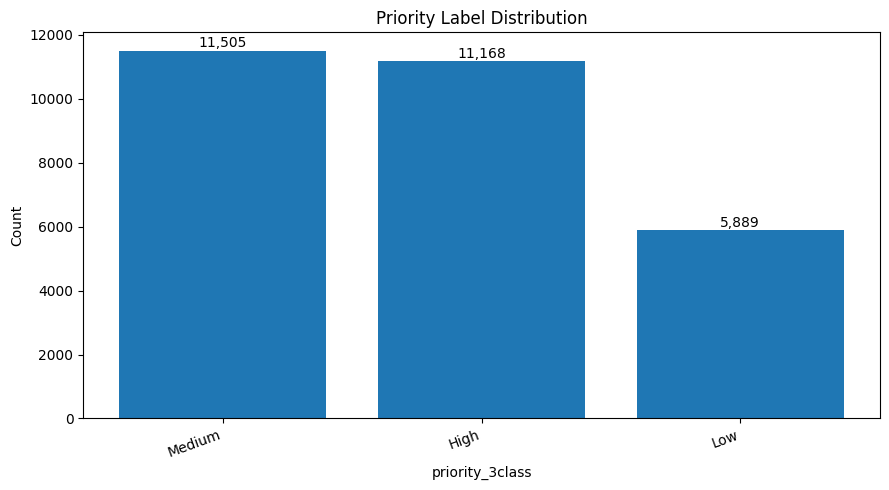


PART B: PRIORITY MODEL HELPER FUNCTIONS

PART B COMPLETE: PRIORITY HELPER FUNCTIONS READY

PART C: OUTER HOLDOUT + INNER VALIDATION SPLIT
Outer train size: 22849
Outer test size: 5713
Inner train size: 17136
Inner validation size: 5713

Inner validation target distribution:


,count,count
0,0,3479
1,1,2234



Outer test target distribution:


,count,count
0,0,3479
1,1,2234



PART D: DEFINE PRIORITY CANDIDATE MODELS
Priority candidate models:
- Priority Logistic Regression - word 1-2gram
- Priority Logistic Regression - word 1-3gram
- Priority SGD Logistic
- Priority XGBoost

PART E: INNER VALIDATION MODEL SELECTION

----------------------------------------------------------------------------------------------------
Training candidate priority model: Priority Logistic Regression - word 1-2gram
----------------------------------------------------------------------------------------------------

Best validation threshold result:


...

,model_name,selected_threshold,validation_accuracy,validation_high_precision,validation_high_recall,validation_high_f1,validation_high_false_negative_rate,validation_roc_auc
2,Priority SGD Logistic,0.2,0.5568,0.4668,0.9364,0.623,0.0636,0.7837



PART G: TRAIN FINAL PRIORITY MODEL ON OUTER TRAIN

FINAL PRIORITY MODEL OUTER TEST METRICS:


,model_name,threshold,accuracy,high_precision,high_recall,high_f1,high_false_negative_rate,roc_auc,true_positive_high,missed_high_false_negative,false_high_alarms,true_negative_not_high
0,Final Priority Model - Priority SGD Logistic,0.2,0.5491,0.4628,0.9526,0.623,0.0474,0.7996,2128,106,2470,1009



Classification report on untouched outer test:
              precision    recall  f1-score   support

    Not High       0.90      0.29      0.44      3479
        High       0.46      0.95      0.62      2234

    accuracy                           0.55      5713
   macro avg       0.68      0.62      0.53      5713
weighted avg       0.73      0.55      0.51      5713

Final Priority Model - Outer Test Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,1009,2470
Actual 1,106,2128


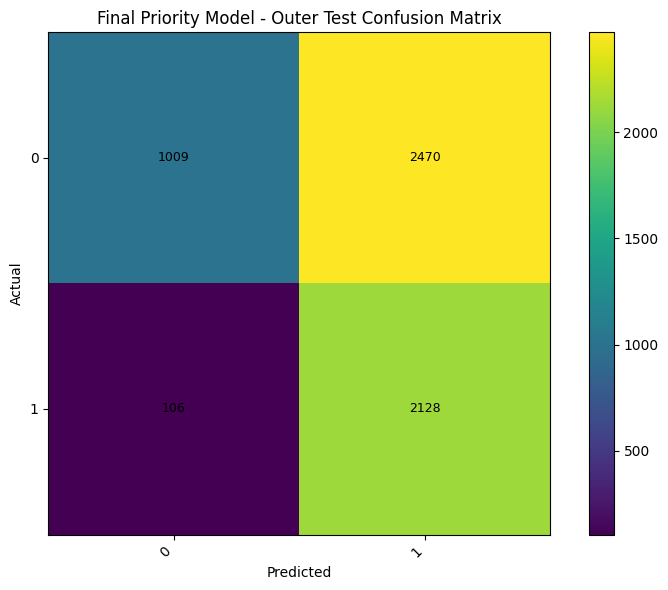


PART H: UPDATE GLOBAL PRIORITY THRESHOLDS
NORMAL_PRIORITY_THRESHOLD: 0.15
HIGH_PRIORITY_THRESHOLD: 0.2

PART I: FINAL PRIORITY TEST OUTPUT TABLE
Priority test prediction examples:


,ticket_text,actual_is_high_priority,predicted_is_high_priority,probability_high,predicted_priority_label,priority_action,correct_binary_prediction
0,"geh rte kundensupport, ich habe schwierigkeite...",0,1,0.4974,High,Escalate immediately,0
1,request for information on digital strategies ...,0,1,0.3213,High,Escalate immediately,0
2,betreff rechnungsfehler und zahlungsprobleme d...,1,1,0.4969,High,Escalate immediately,1
3,festgestellte probleme mit der data analytics ...,0,1,0.5648,High,Escalate immediately,0
4,notwendigkeit von sicherheitsunterst tzung es ...,1,1,0.5829,High,Escalate immediately,1
5,rails financial data integration customer supp...,1,1,0.6257,High,Escalate immediately,1
6,systemic issues in the marketing agency the ma...,1,1,0.8740,High,Escalate immediately,1
7,marketing plans for achieving anticipated expa...,0,0,0.1807,Needs Review,Send to human triage review,1
8,inquiry regarding digital brand size dear cust...,1,1,0.5118,High,Escalate immediately,1
9,meldung ber unbefugten zugriff sehr geehrte ku...,1,1,0.3891,High,Escalate immediately,1



Predicted priority label distribution:


,predicted_priority_label,count,percent
0,High,4598,80.48
1,Normal,675,11.82
2,Needs Review,440,7.70


Skipped intermediate file: final_priority_test_predictions.csv

PART J: TEST PRIORITY MODEL ON DEMO TICKETS


,subject,probability_high,predicted_priority,priority_action
0,Payment gateway down for all customers,0.6729,High,Escalate immediately
1,Need password reset,0.2958,High,Escalate immediately
2,Laptop screen flickering during meetings,0.0988,Normal,Normal priority queue
3,API returning 500 errors,0.6630,High,Escalate immediately
4,Question about invoice,0.3255,High,Escalate immediately



PART K: SAVE FINAL PRIORITY MODEL AND CONFIG
Saved model: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Models/final_priority_model.pkl


,final_priority_model_name,split_strategy,selected_threshold_from_validation,normal_priority_threshold,high_priority_threshold,outer_test_accuracy,outer_test_high_precision,outer_test_high_recall,outer_test_high_f1,outer_test_high_false_negative_rate,outer_test_roc_auc,business_reason
0,Final Priority Model - Priority SGD Logistic,outer_train_test_plus_inner_validation_holdout,0.2,0.15,0.2,0.5491,0.4628,0.9526,0.623,0.0474,0.7996,High recall is prioritized because missing urg...


Skipped intermediate file: priority_model_config.csv


In [18]:
section_header("SECTION 4: TRAIN PRIORITY MODELS WITH OUTER/INNER HOLDOUT")


# PART A: PREPARE PRIORITY MODEL DATASET

section_header("PART A: PREPARE PRIORITY MODEL DATASET")

priority_df = multi_priority_model_df.copy()

# 1. Choose model text

if "ticket_text_with_tags" in priority_df.columns:
    priority_df["model_text"] = priority_df["ticket_text_with_tags"].fillna("").astype(str)
else:
    priority_df["model_text"] = priority_df["ticket_text"].fillna("").astype(str)

priority_df["model_text"] = priority_df["model_text"].apply(clean_text_basic)

# 2. Keep valid target rows

priority_df = priority_df[
    (priority_df["model_text"].str.strip() != "") &
    (priority_df["is_high_priority"].notna())
].copy()

priority_df["is_high_priority"] = priority_df["is_high_priority"].astype(int)

print("Priority model dataset shape:")
print(priority_df.shape)

print("\nBinary high-priority distribution:")
priority_binary_dist = (
    priority_df["is_high_priority"]
    .value_counts()
    .reset_index()
)

priority_binary_dist.columns = ["is_high_priority", "count"]
priority_binary_dist["label"] = priority_binary_dist["is_high_priority"].map({
    0: "Not High",
    1: "High"
})
priority_binary_dist["percent"] = (
    priority_binary_dist["count"] / len(priority_df) * 100
).round(2)

display(priority_binary_dist[["label", "count", "percent"]])

plot_value_counts(
    priority_df,
    "priority_3class",
    title="Priority Label Distribution",
    top_n=10,
    rotation=20
)


# PART B: HELPER FUNCTIONS FOR PRIORITY MODELING

section_header("PART B: PRIORITY MODEL HELPER FUNCTIONS")

def evaluate_binary_at_threshold(y_true, y_proba, threshold, model_name):
    """
    Evaluates binary classifier at a selected threshold.
    Target:
    1 = High priority
    0 = Not high priority
    """

    y_pred = (y_proba >= threshold).astype(int)

    tp = ((y_true == 1) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()

    high_false_negative_rate = fn / (tp + fn) if (tp + fn) > 0 else np.nan

    try:
        auc = roc_auc_score(y_true, y_proba)
    except Exception:
        auc = np.nan

    return {
        "model_name": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "high_precision": precision_score(y_true, y_pred, zero_division=0),
        "high_recall": recall_score(y_true, y_pred, zero_division=0),
        "high_f1": f1_score(y_true, y_pred, zero_division=0),
        "high_false_negative_rate": high_false_negative_rate,
        "roc_auc": auc,
        "true_positive_high": tp,
        "missed_high_false_negative": fn,
        "false_high_alarms": fp,
        "true_negative_not_high": tn
    }


def create_threshold_table(y_true, y_proba, model_name):
    """
    Creates threshold tuning table.
    Threshold is tuned on validation set only.
    """

    rows = []

    for threshold in np.arange(0.10, 0.91, 0.05):
        rows.append(
            evaluate_binary_at_threshold(
                y_true=y_true,
                y_proba=y_proba,
                threshold=round(float(threshold), 2),
                model_name=model_name
            )
        )

    return pd.DataFrame(rows)


def choose_priority_threshold(threshold_df, target_false_negative_rate=0.10):
    """
    Business rule:
    - First try to keep missed high-priority tickets below 10%
    - Among those, choose the highest high_f1
    - If no threshold meets that false negative target, choose best high_f1
    """

    candidates = threshold_df[
        threshold_df["high_false_negative_rate"] <= target_false_negative_rate
    ].copy()

    if len(candidates) > 0:
        best_row = (
            candidates
            .sort_values(["high_f1", "high_recall"], ascending=False)
            .iloc[0]
        )
    else:
        best_row = (
            threshold_df
            .sort_values(["high_f1", "high_recall"], ascending=False)
            .iloc[0]
        )

    return best_row


def classify_priority_from_probability(prob_high):
    """
    Converts probability of High into business-friendly label.
    These thresholds are updated after validation.
    """

    if prob_high >= HIGH_PRIORITY_THRESHOLD:
        return "High"
    elif prob_high >= NORMAL_PRIORITY_THRESHOLD:
        return "Needs Review"
    else:
        return "Normal"


def get_priority_action(priority_label):
    """
    Converts priority label into recommended action.
    """

    if priority_label == "High":
        return "Escalate immediately"
    elif priority_label == "Needs Review":
        return "Send to human triage review"
    else:
        return "Normal priority queue"


def plot_priority_threshold_tradeoff(threshold_df, selected_threshold, title):
    """
    Plots precision, recall, and F1 across thresholds.
    """

    plt.figure(figsize=(9, 5))

    plt.plot(
        threshold_df["threshold"],
        threshold_df["high_precision"],
        marker="o",
        label="High Precision"
    )

    plt.plot(
        threshold_df["threshold"],
        threshold_df["high_recall"],
        marker="o",
        label="High Recall"
    )

    plt.plot(
        threshold_df["threshold"],
        threshold_df["high_f1"],
        marker="o",
        label="High F1"
    )

    plt.axvline(
        selected_threshold,
        linestyle="--",
        label=f"Selected threshold = {selected_threshold:.2f}"
    )

    plt.title(title)
    plt.xlabel("Decision Threshold")
    plt.ylabel("Score")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


section_header("PART B COMPLETE: PRIORITY HELPER FUNCTIONS READY")


# PART C: OUTER HOLDOUT + INNER VALIDATION SPLIT

section_header("PART C: OUTER HOLDOUT + INNER VALIDATION SPLIT")

X_priority = priority_df["model_text"]
y_priority = priority_df["is_high_priority"]

# Outer split: untouched final test set
X_priority_outer_train, X_priority_outer_test, y_priority_outer_train, y_priority_outer_test = train_test_split(
    X_priority,
    y_priority,
    test_size=0.20,
    random_state=42,
    stratify=y_priority
)

# Inner split: train/validation inside outer training data
X_priority_inner_train, X_priority_inner_val, y_priority_inner_train, y_priority_inner_val = train_test_split(
    X_priority_outer_train,
    y_priority_outer_train,
    test_size=0.25,
    random_state=42,
    stratify=y_priority_outer_train
)

print("Outer train size:", len(X_priority_outer_train))
print("Outer test size:", len(X_priority_outer_test))
print("Inner train size:", len(X_priority_inner_train))
print("Inner validation size:", len(X_priority_inner_val))

print("\nInner validation target distribution:")
display(
    y_priority_inner_val
    .value_counts()
    .reset_index()
    .rename(columns={"index": "is_high_priority", "is_high_priority": "count"})
)

print("\nOuter test target distribution:")
display(
    y_priority_outer_test
    .value_counts()
    .reset_index()
    .rename(columns={"index": "is_high_priority", "is_high_priority": "count"})
)


# PART D: DEFINE PRIORITY CANDIDATE MODELS

section_header("PART D: DEFINE PRIORITY CANDIDATE MODELS")

priority_candidate_models = {
    "Priority Logistic Regression - word 1-2gram": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                stop_words="english"
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                C=2.0,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "Priority Logistic Regression - word 1-3gram": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=70000,
                ngram_range=(1, 3),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                stop_words="english"
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2500,
                class_weight="balanced",
                C=2.0,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "Priority SGD Logistic": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=70000,
                ngram_range=(1, 3),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                stop_words="english"
            )
        ),
        (
            "classifier",
            SGDClassifier(
                loss="log_loss",
                alpha=1e-5,
                penalty="l2",
                class_weight="balanced",
                max_iter=2000,
                random_state=42,
                n_jobs=-1
            )
        )
    ])
}

# Optional XGBoost model
if XGBOOST_AVAILABLE:
    priority_candidate_models["Priority XGBoost"] = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=15000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                stop_words="english"
            )
        ),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.07,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ])

print("Priority candidate models:")
for model_name in priority_candidate_models.keys():
    print("-", model_name)


# PART E: INNER VALIDATION MODEL SELECTION

section_header("PART E: INNER VALIDATION MODEL SELECTION")

priority_validation_results = []
priority_threshold_tables = {}

for model_name, model in priority_candidate_models.items():
    subsection_header(f"Training candidate priority model: {model_name}")

    temp_model = clone(model)
    temp_model.fit(X_priority_inner_train, y_priority_inner_train)

    val_proba = safe_predict_proba(temp_model, X_priority_inner_val)[:, 1]

    threshold_df = create_threshold_table(
        y_true=y_priority_inner_val,
        y_proba=val_proba,
        model_name=model_name
    )

    best_threshold_row = choose_priority_threshold(
        threshold_df,
        target_false_negative_rate=0.10
    )

    priority_threshold_tables[model_name] = threshold_df

    priority_validation_results.append({
        "model_name": model_name,
        "selected_threshold": best_threshold_row["threshold"],
        "validation_accuracy": best_threshold_row["accuracy"],
        "validation_high_precision": best_threshold_row["high_precision"],
        "validation_high_recall": best_threshold_row["high_recall"],
        "validation_high_f1": best_threshold_row["high_f1"],
        "validation_high_false_negative_rate": best_threshold_row["high_false_negative_rate"],
        "validation_roc_auc": best_threshold_row["roc_auc"]
    })

    print("\nBest validation threshold result:")
    display(pd.DataFrame([best_threshold_row]).round(4))

priority_validation_results_df = pd.DataFrame(priority_validation_results)

print("\nPriority validation model comparison:")
display(
    priority_validation_results_df
    .sort_values(["validation_high_f1", "validation_high_recall"], ascending=False)
    .round(4)
)

save_output(priority_validation_results_df, "priority_inner_validation_model_comparison.csv")


# PART F: SELECT BEST PRIORITY MODEL

section_header("PART F: SELECT BEST PRIORITY MODEL")

best_priority_row = (
    priority_validation_results_df
    .sort_values(
        ["validation_high_f1", "validation_high_recall", "validation_roc_auc"],
        ascending=False
    )
    .iloc[0]
)

best_priority_model_name = best_priority_row["model_name"]
best_priority_threshold = float(best_priority_row["selected_threshold"])

print("Selected priority model:")
print(best_priority_model_name)

print("\nSelected priority threshold:")
print(best_priority_threshold)

display(pd.DataFrame([best_priority_row]).round(4))


# PART G: TRAIN FINAL PRIORITY MODEL ON OUTER TRAIN

section_header("PART G: TRAIN FINAL PRIORITY MODEL ON OUTER TRAIN")

final_priority_model = clone(priority_candidate_models[best_priority_model_name])

final_priority_model.fit(
    X_priority_outer_train,
    y_priority_outer_train
)

outer_test_proba = safe_predict_proba(
    final_priority_model,
    X_priority_outer_test
)[:, 1]

outer_test_pred = (outer_test_proba >= best_priority_threshold).astype(int)

final_priority_metrics = evaluate_binary_at_threshold(
    y_true=y_priority_outer_test,
    y_proba=outer_test_proba,
    threshold=best_priority_threshold,
    model_name=f"Final Priority Model - {best_priority_model_name}"
)

print("\nFINAL PRIORITY MODEL OUTER TEST METRICS:")
display(pd.DataFrame([final_priority_metrics]).round(4))

print("\nClassification report on untouched outer test:")
print(
    classification_report(
        y_priority_outer_test,
        outer_test_pred,
        target_names=["Not High", "High"],
        zero_division=0
    )
)

priority_cm_df = plot_clean_confusion_matrix(
    y_true=y_priority_outer_test,
    y_pred=outer_test_pred,
    labels=[0, 1],
    title="Final Priority Model - Outer Test Confusion Matrix"
)

# PART H: UPDATE GLOBAL THRESHOLDS FOR FINAL PRODUCT LOGIC

section_header("PART H: UPDATE GLOBAL PRIORITY THRESHOLDS")

HIGH_PRIORITY_THRESHOLD = best_priority_threshold

if HIGH_PRIORITY_THRESHOLD <= 0.35:
    NORMAL_PRIORITY_THRESHOLD = max(0.15, HIGH_PRIORITY_THRESHOLD - 0.15)
else:
    NORMAL_PRIORITY_THRESHOLD = 0.35

print("NORMAL_PRIORITY_THRESHOLD:", NORMAL_PRIORITY_THRESHOLD)
print("HIGH_PRIORITY_THRESHOLD:", HIGH_PRIORITY_THRESHOLD)


def classify_priority_from_probability(prob_high):
    """
    Converts probability of High into business-friendly label.
    """
    if prob_high >= HIGH_PRIORITY_THRESHOLD:
        return "High"
    elif prob_high >= NORMAL_PRIORITY_THRESHOLD:
        return "Needs Review"
    else:
        return "Normal"


def get_priority_action(priority_label):
    """
    Converts priority label into support action.
    """
    if priority_label == "High":
        return "Escalate immediately"
    elif priority_label == "Needs Review":
        return "Send to human triage review"
    else:
        return "Normal priority queue"


# PART I: CREATE FINAL PRIORITY TEST OUTPUT TABLE

section_header("PART I: FINAL PRIORITY TEST OUTPUT TABLE")

priority_test_results_df = pd.DataFrame({
    "ticket_text": X_priority_outer_test.values,
    "actual_is_high_priority": y_priority_outer_test.values,
    "predicted_is_high_priority": outer_test_pred,
    "probability_high": outer_test_proba
})

priority_test_results_df["predicted_priority_label"] = priority_test_results_df["probability_high"].apply(
    classify_priority_from_probability
)

priority_test_results_df["priority_action"] = priority_test_results_df["predicted_priority_label"].apply(
    get_priority_action
)

priority_test_results_df["correct_binary_prediction"] = (
    priority_test_results_df["actual_is_high_priority"] ==
    priority_test_results_df["predicted_is_high_priority"]
).astype(int)

print("Priority test prediction examples:")
display(priority_test_results_df.head(10).round(4))

print("\nPredicted priority label distribution:")
display(categorical_distribution(priority_test_results_df, "predicted_priority_label"))

save_output(priority_test_results_df, "final_priority_test_predictions.csv")


# PART J: TEST PRIORITY MODEL ON DEMO TICKETS

section_header("PART J: TEST PRIORITY MODEL ON DEMO TICKETS")

priority_demo_tickets = pd.DataFrame([
    {
        "subject": "Payment gateway down for all customers",
        "body": "Customers are unable to complete checkout and payment transactions are failing since this morning."
    },
    {
        "subject": "Need password reset",
        "body": "I forgot my password and cannot log in to my account."
    },
    {
        "subject": "Laptop screen flickering during meetings",
        "body": "My laptop screen keeps flickering whenever I connect it to the external monitor."
    },
    {
        "subject": "API returning 500 errors",
        "body": "Our production API integration is failing with repeated 500 errors and blocking order processing."
    },
    {
        "subject": "Question about invoice",
        "body": "I have a question about a recent invoice charge."
    }
])

priority_demo_tickets["model_text"] = (
    priority_demo_tickets["subject"] + " " +
    priority_demo_tickets["body"]
).apply(clean_text_basic)

priority_demo_tickets["probability_high"] = safe_predict_proba(
    final_priority_model,
    priority_demo_tickets["model_text"]
)[:, 1]

priority_demo_tickets["predicted_priority"] = priority_demo_tickets["probability_high"].apply(
    classify_priority_from_probability
)

priority_demo_tickets["priority_action"] = priority_demo_tickets["predicted_priority"].apply(
    get_priority_action
)

display(
    priority_demo_tickets[
        [
            "subject",
            "probability_high",
            "predicted_priority",
            "priority_action"
        ]
    ].round(4)
)


# PART K: SAVE FINAL PRIORITY MODEL AND CONFIG

section_header("PART K: SAVE FINAL PRIORITY MODEL AND CONFIG")

final_priority_model_name = f"Final Priority Model - {best_priority_model_name}"

save_model(final_priority_model, "final_priority_model.pkl")

priority_config_df = pd.DataFrame([{
    "final_priority_model_name": final_priority_model_name,
    "split_strategy": "outer_train_test_plus_inner_validation_holdout",
    "selected_threshold_from_validation": best_priority_threshold,
    "normal_priority_threshold": NORMAL_PRIORITY_THRESHOLD,
    "high_priority_threshold": HIGH_PRIORITY_THRESHOLD,
    "outer_test_accuracy": final_priority_metrics["accuracy"],
    "outer_test_high_precision": final_priority_metrics["high_precision"],
    "outer_test_high_recall": final_priority_metrics["high_recall"],
    "outer_test_high_f1": final_priority_metrics["high_f1"],
    "outer_test_high_false_negative_rate": final_priority_metrics["high_false_negative_rate"],
    "outer_test_roc_auc": final_priority_metrics["roc_auc"],
    "business_reason": "High recall is prioritized because missing urgent tickets is more costly than sending extra tickets to human review."
}])

display(priority_config_df.round(4))

save_output(priority_config_df, "priority_model_config.csv")

## Section 4.a: Business-Friendly Priority Thresholds

This section adjusts the final priority thresholds used in the product workflow. The trained priority model is optimized to catch urgent tickets, but using a very low threshold can make too many tickets appear as high priority.

To make the final system more realistic, this section separates predictions into three business-friendly groups: **Normal**, **Needs Review**, and **High**. Borderline tickets are sent to human review instead of being escalated automatically.

In [19]:
section_header("PATCH: BUSINESS-FRIENDLY PRIORITY THRESHOLDS")

# Keep a lower threshold for Needs Review, but make High stricter.
NORMAL_PRIORITY_THRESHOLD = 0.20
HIGH_PRIORITY_THRESHOLD = 0.55

def classify_priority_from_probability(prob_high):
    """
    Converts probability of High into business-friendly label.
    """
    if prob_high >= HIGH_PRIORITY_THRESHOLD:
        return "High"
    elif prob_high >= NORMAL_PRIORITY_THRESHOLD:
        return "Needs Review"
    else:
        return "Normal"


def get_priority_action(priority_label):
    """
    Converts priority label into support action.
    """
    if priority_label == "High":
        return "Escalate immediately"
    elif priority_label == "Needs Review":
        return "Send to human triage review"
    else:
        return "Normal priority queue"


print("Updated final business thresholds:")
print("NORMAL_PRIORITY_THRESHOLD:", NORMAL_PRIORITY_THRESHOLD)
print("HIGH_PRIORITY_THRESHOLD:", HIGH_PRIORITY_THRESHOLD)

# Save updated threshold config if priority_config_df already exists
try:
    priority_config_df["normal_priority_threshold"] = NORMAL_PRIORITY_THRESHOLD
    priority_config_df["high_priority_threshold"] = HIGH_PRIORITY_THRESHOLD
    priority_config_df["business_threshold_note"] = (
        "Model threshold was selected for high recall, but final product labels use stricter High threshold "
        "to reduce false escalations. Tickets between Normal and High thresholds are sent to Needs Review."
    )

    display(priority_config_df)
    save_output(priority_config_df, "priority_model_config.csv")

except Exception as e:
    print("priority_config_df not available yet. This is okay if Section 4 has not created it.")
    print("Error:", e)


PATCH: BUSINESS-FRIENDLY PRIORITY THRESHOLDS
Updated final business thresholds:
NORMAL_PRIORITY_THRESHOLD: 0.2
HIGH_PRIORITY_THRESHOLD: 0.55


,final_priority_model_name,split_strategy,selected_threshold_from_validation,normal_priority_threshold,high_priority_threshold,outer_test_accuracy,outer_test_high_precision,outer_test_high_recall,outer_test_high_f1,outer_test_high_false_negative_rate,outer_test_roc_auc,business_reason,business_threshold_note
0,Final Priority Model - Priority SGD Logistic,outer_train_test_plus_inner_validation_holdout,0.2,0.2,0.55,0.549099,0.46281,0.952551,0.622951,0.047449,0.799647,High recall is prioritized because missing urg...,"Model threshold was selected for high recall, ..."


Skipped intermediate file: priority_model_config.csv


## Section 5: Baseline Queue Routing Model and Optional IT Routing Model

This section trains baseline routing models. The first model predicts the original detailed support queue labels, such as Technical Support, Product Support, IT Support, Billing, and Customer Service. This gives us a benchmark for routing performance.

An optional IT routing model is also trained using the IT ticket dataset. This helps compare routing performance when labels are clearer and less overlapping. This section is mainly used as a baseline before improving the routing approach in the next section.


SECTION 5: BASELINE QUEUE ROUTING MODEL + OPTIONAL IT ROUTING MODEL

PART A: ROUTING HELPER FUNCTIONS

PART A COMPLETE: ROUTING HELPERS READY

PART B: BASELINE MULTILINGUAL QUEUE ROUTING MODEL
Baseline queue routing dataset shape:
(28562, 21)

Original queue label distribution:


,queue_label,count,percent
0,Technical Support,8351,29.24
1,Product Support,5251,18.38
2,Customer Service,4266,14.94
3,It Support,3432,12.02
4,Billing And Payments,2783,9.74
5,Returns And Exchanges,1434,5.02
6,Service Outages And Maintenance,1148,4.02
7,Sales And Pre Sales,918,3.21
8,Human Resources,576,2.02
9,General Inquiry,403,1.41


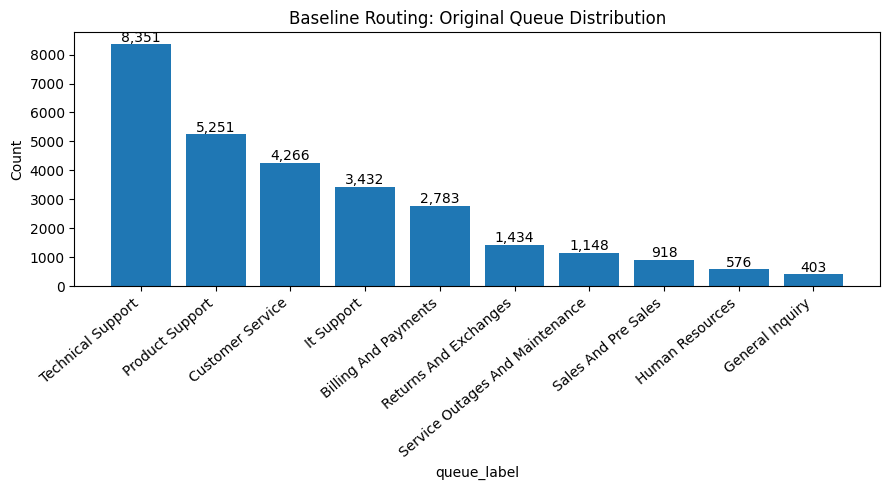


Baseline queue routing train size: 22849
Baseline queue routing test size: 5713

Routing metrics for Baseline Original Queue Routing Logistic Regression:


,model_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Baseline Original Queue Routing Logistic Regre...,0.5512,0.5295,0.581,0.5496,0.5525



Classification report:
                                 precision    recall  f1-score   support

           Billing And Payments       0.76      0.73      0.75       557
               Customer Service       0.49      0.51      0.50       853
                General Inquiry       0.51      0.59      0.55        81
                Human Resources       0.51      0.51      0.51       115
                     It Support       0.47      0.54      0.50       686
                Product Support       0.51      0.45      0.48      1050
          Returns And Exchanges       0.43      0.52      0.47       287
            Sales And Pre Sales       0.37      0.58      0.46       184
Service Outages And Maintenance       0.61      0.83      0.70       230
              Technical Support       0.64      0.55      0.59      1670

                       accuracy                           0.55      5713
                      macro avg       0.53      0.58      0.55      5713
                   weight

,Predicted Billing And Payments,Predicted Customer Service,Predicted General Inquiry,Predicted Human Resources,Predicted It Support,Predicted Product Support,Predicted Returns And Exchanges,Predicted Sales And Pre Sales,Predicted Service Outages And Maintenance,Predicted Technical Support
Actual Billing And Payments,409,61,1,3,9,24,10,15,3,22
Actual Customer Service,33,435,12,10,48,106,46,54,12,97
Actual General Inquiry,1,8,48,0,3,8,5,2,0,6
Actual Human Resources,1,17,1,59,10,9,5,4,1,8
Actual It Support,15,50,5,3,370,48,20,13,19,143
Actual Product Support,28,111,17,18,109,470,60,41,19,177
Actual Returns And Exchanges,14,37,3,5,8,29,149,10,5,27
Actual Sales And Pre Sales,2,20,2,1,7,29,5,107,3,8
Actual Service Outages And Maintenance,3,2,1,1,9,6,1,1,190,16
Actual Technical Support,30,153,5,16,217,188,49,39,61,912


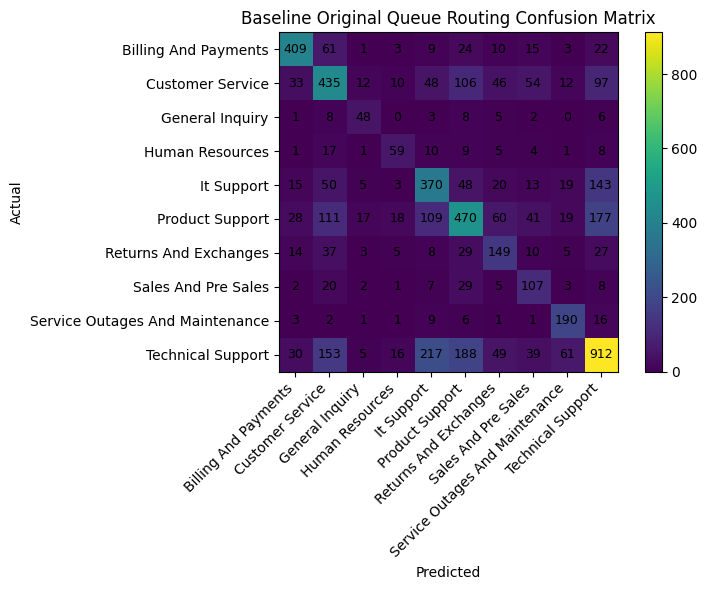


Baseline queue routing prediction examples:


,ticket_text,actual_route,predicted_route,routing_confidence,correct_prediction,routing_action
0,security concern in healthcare facility a heal...,Product Support,Product Support,0.282853,1,Manual triage required
1,issue in data analysis an error occurred durin...,It Support,Technical Support,0.449297,0,Manual triage required
2,system downtime notification an outage occurre...,Returns And Exchanges,Service Outages And Maintenance,0.298529,0,Manual triage required
3,medical data leak possibly caused by outdated ...,Product Support,Product Support,0.381603,1,Manual triage required
4,support request for server downtime users repo...,Technical Support,Service Outages And Maintenance,0.734248,0,Route with human review
5,alert for security breach in healthcare system...,Returns And Exchanges,Returns And Exchanges,0.546382,1,Route with human review
6,inquiry about saas project management solution...,Returns And Exchanges,Customer Service,0.236264,0,Manual triage required
7,medical data security practices seeking inform...,It Support,Billing And Payments,0.189880,0,Manual triage required
8,integration of cisco ios systems can you suppl...,Technical Support,Customer Service,0.426826,0,Manual triage required
9,support required for system outage our marketi...,Technical Support,Service Outages And Maintenance,0.688134,0,Route with human review



Baseline routing action distribution:


,routing_action,count,percent
0,Manual triage required,4535,79.38
1,Route with human review,826,14.46
2,Auto-route to predicted queue,352,6.16



Baseline incorrect prediction examples:


,ticket_text,actual_route,predicted_route,routing_confidence,correct_prediction,routing_action
1,issue in data analysis an error occurred durin...,It Support,Technical Support,0.449297,0,Manual triage required
2,system downtime notification an outage occurre...,Returns And Exchanges,Service Outages And Maintenance,0.298529,0,Manual triage required
4,support request for server downtime users repo...,Technical Support,Service Outages And Maintenance,0.734248,0,Route with human review
6,inquiry about saas project management solution...,Returns And Exchanges,Customer Service,0.236264,0,Manual triage required
7,medical data security practices seeking inform...,It Support,Billing And Payments,0.189880,0,Manual triage required
8,integration of cisco ios systems can you suppl...,Technical Support,Customer Service,0.426826,0,Manual triage required
9,support required for system outage our marketi...,Technical Support,Service Outages And Maintenance,0.688134,0,Route with human review
11,query on jira software integration seeking det...,Product Support,Customer Service,0.265978,0,Manual triage required
15,i am keen to learn about securing medical data...,Billing And Payments,Sales And Pre Sales,0.263774,0,Manual triage required
22,"customer support, kindly draw attention to the...",Technical Support,It Support,0.244196,0,Manual triage required


Skipped intermediate model: baseline_original_queue_routing_model.pkl


,model_name,dataset,target,input_text,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,number_of_classes,recommended_use
0,Baseline Original Queue Routing Logistic Regre...,multilingual_ticket_dataset,original_queue_label,ticket_text_with_tags_plus_type_priority_if_av...,0.5512,0.5295,0.581,0.5496,0.5525,10,Baseline only; improved grouped routing model ...


Skipped intermediate file: baseline_original_queue_routing_metrics.csv
Skipped intermediate file: baseline_original_queue_routing_predictions.csv

PART C: OPTIONAL IT ROUTING MODEL
Optional IT routing dataset shape:
(47823, 2)

IT routing label distribution:


,routing_label,count,percent
0,Hardware,13611,28.46
1,Hr Support,10911,22.82
2,Access,7124,14.90
3,Miscellaneous,7058,14.76
4,Storage,2777,5.81
5,Purchase,2463,5.15
6,Internal Project,2119,4.43
7,Administrative Rights,1760,3.68


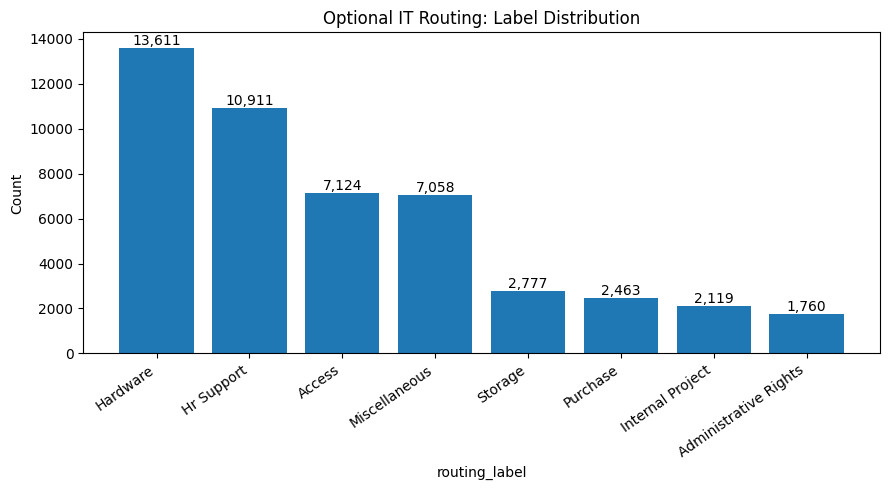


IT routing train size: 38258
IT routing test size: 9565

Routing metrics for Optional IT Routing Logistic Regression:


,model_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Optional IT Routing Logistic Regression,0.8616,0.8516,0.8767,0.863,0.862



Classification report:
                       precision    recall  f1-score   support

               Access       0.90      0.89      0.89      1425
Administrative Rights       0.72      0.86      0.78       352
             Hardware       0.86      0.83      0.85      2722
           Hr Support       0.89      0.86      0.87      2182
     Internal Project       0.83      0.90      0.86       424
        Miscellaneous       0.81      0.85      0.83      1412
             Purchase       0.94      0.92      0.93       493
              Storage       0.87      0.92      0.89       555

             accuracy                           0.86      9565
            macro avg       0.85      0.88      0.86      9565
         weighted avg       0.86      0.86      0.86      9565

Optional IT Routing Confusion Matrix


,Predicted Access,Predicted Administrative Rights,Predicted Hardware,Predicted Hr Support,Predicted Internal Project,Predicted Miscellaneous,Predicted Purchase,Predicted Storage
Actual Access,1270,14,59,29,8,41,1,3
Actual Administrative Rights,4,301,35,3,1,8,0,0
Actual Hardware,69,80,2251,122,18,116,21,45
Actual Hr Support,36,10,117,1875,24,99,6,15
Actual Internal Project,4,2,12,14,380,11,0,1
Actual Miscellaneous,25,5,89,51,23,1204,3,12
Actual Purchase,5,4,20,4,2,5,452,1
Actual Storage,2,3,22,10,0,10,0,508


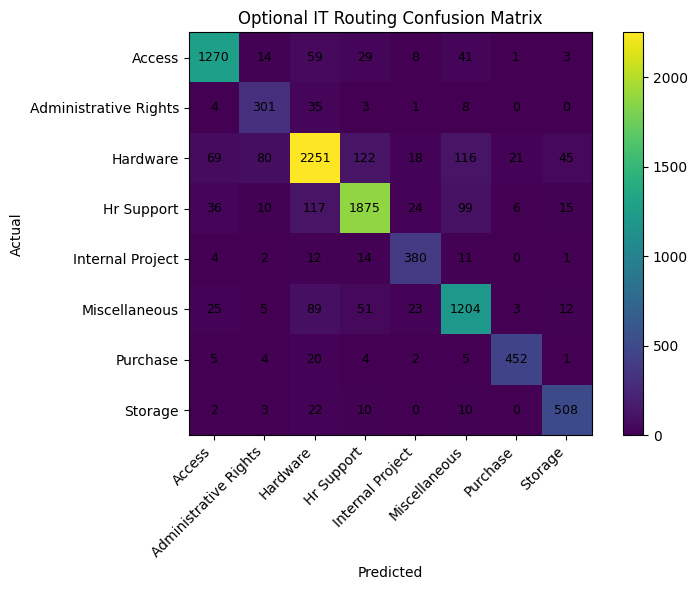


Optional IT routing prediction examples:


,ticket_text,actual_route,predicted_route,routing_confidence,correct_prediction,routing_action
0,target par backup alarm alarm alarm changed st...,Miscellaneous,Miscellaneous,0.829088,1,Auto-route to predicted queue
1,new starter am discipline refused offer re sta...,Hr Support,Hr Support,0.773747,1,Route with human review
2,enrich user tuesday february pm re enrich user...,Access,Access,0.931180,1,Auto-route to predicted queue
3,confluence user needed for thursday confluence...,Access,Access,0.999372,1,Auto-route to predicted queue
4,add users to confluence security tuesday decem...,Access,Access,0.877457,1,Auto-route to predicted queue
5,issue hello help please with here attached ima...,Hr Support,Hr Support,0.665611,1,Route with human review
6,time sheet submission error sent thursday subm...,Hr Support,Hr Support,0.993624,1,Auto-route to predicted queue
7,for account needed for notes hi myself had few...,Hardware,Hardware,0.463178,1,Manual triage required
8,meeting connection issue sent thursday decembe...,Hardware,Hardware,0.923411,1,Auto-route to predicted queue
9,opportunities to be closed pas friday july opp...,Internal Project,Internal Project,0.502319,1,Route with human review



Optional IT routing action distribution:


,routing_action,count,percent
0,Auto-route to predicted queue,5144,53.78
1,Route with human review,2770,28.96
2,Manual triage required,1651,17.26


Skipped intermediate model: optional_it_routing_model.pkl


...

Skipped intermediate file: optional_it_routing_model_metrics.csv
Skipped intermediate file: optional_it_routing_predictions.csv

PART D: BASELINE ROUTING MODEL COMPARISON


,model_name,dataset,target,input_text,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,number_of_classes,recommended_use
0,Baseline Original Queue Routing Logistic Regre...,multilingual_ticket_dataset,original_queue_label,ticket_text_with_tags_plus_type_priority_if_av...,0.5512,0.5295,0.5810,0.5496,0.5525,10,Baseline only; improved grouped routing model ...
1,Optional IT Routing Logistic Regression,it_ticket_classification_dataset,routing_label,NaN,0.8616,0.8516,0.8767,0.8630,0.8620,8,Optional comparison model; useful to show clea...


Skipped intermediate file: baseline_routing_model_comparison.csv

PART E: BASELINE ROUTING DEMO TEST
Baseline original queue routing demo predictions:


,subject,predicted_original_queue,routing_confidence,routing_action
0,Payment gateway down for all customers,Billing And Payments,0.9976,Auto-route to predicted queue
1,Need password reset,Billing And Payments,0.3763,Manual triage required
2,Laptop screen flickering,Product Support,0.2467,Manual triage required
3,API returning 500 errors,Technical Support,0.4730,Manual triage required
4,Question about invoice,Billing And Payments,0.9806,Auto-route to predicted queue


Skipped intermediate file: baseline_original_queue_demo_predictions.csv


In [20]:
section_header("SECTION 5: BASELINE QUEUE ROUTING MODEL + OPTIONAL IT ROUTING MODEL")

# PART A: ROUTING HELPER FUNCTIONS

section_header("PART A: ROUTING HELPER FUNCTIONS")

def evaluate_routing_model(y_true, y_pred, model_name):
    """
    Evaluates a multiclass routing model.
    """
    metrics = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

    print(f"\nRouting metrics for {model_name}:")
    display(pd.DataFrame([metrics]).round(4))

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return metrics


def create_routing_results_df(X_test, y_test, y_pred, y_proba):
    """
    Creates clean routing prediction output dataframe.
    """
    results_df = pd.DataFrame({
        "ticket_text": X_test.values,
        "actual_route": y_test.values,
        "predicted_route": y_pred,
        "routing_confidence": y_proba.max(axis=1)
    })

    results_df["correct_prediction"] = (
        results_df["actual_route"] == results_df["predicted_route"]
    ).astype(int)

    results_df["routing_action"] = results_df["routing_confidence"].apply(get_queue_action)

    return results_df


section_header("PART A COMPLETE: ROUTING HELPERS READY")


# PART B: BASELINE MULTILINGUAL QUEUE ROUTING MODEL

section_header("PART B: BASELINE MULTILINGUAL QUEUE ROUTING MODEL")

# 1. Prepare baseline routing dataset

baseline_queue_df = multi_queue_model_df.copy()

if "ticket_text_with_tags" in baseline_queue_df.columns:
    baseline_queue_df["model_text"] = baseline_queue_df["ticket_text_with_tags"].fillna("").astype(str)
else:
    baseline_queue_df["model_text"] = baseline_queue_df["ticket_text"].fillna("").astype(str)

# Add some context if available
if "ticket_type_label" in baseline_queue_df.columns:
    baseline_queue_df["model_text"] = (
        baseline_queue_df["model_text"] + " ticket_type_" +
        baseline_queue_df["ticket_type_label"].fillna("").astype(str)
    )

if "priority_3class" in baseline_queue_df.columns:
    baseline_queue_df["model_text"] = (
        baseline_queue_df["model_text"] + " priority_" +
        baseline_queue_df["priority_3class"].fillna("").astype(str)
    )

baseline_queue_df["model_text"] = baseline_queue_df["model_text"].apply(clean_text_basic)

baseline_queue_df["queue_label"] = (
    baseline_queue_df["queue_label"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

baseline_queue_df = baseline_queue_df[
    (baseline_queue_df["model_text"].str.strip() != "") &
    (baseline_queue_df["queue_label"].str.lower() != "unknown")
].copy()

print("Baseline queue routing dataset shape:")
print(baseline_queue_df.shape)

print("\nOriginal queue label distribution:")
display(categorical_distribution(baseline_queue_df, "queue_label", top_n=20))

plot_value_counts(
    baseline_queue_df,
    "queue_label",
    title="Baseline Routing: Original Queue Distribution",
    top_n=12,
    rotation=40
)


# 2. Train-test split

X_queue_base = baseline_queue_df["model_text"]
y_queue_base = baseline_queue_df["queue_label"]

Xq_base_train, Xq_base_test, yq_base_train, yq_base_test = train_test_split(
    X_queue_base,
    y_queue_base,
    test_size=0.20,
    random_state=42,
    stratify=y_queue_base
)

print("\nBaseline queue routing train size:", len(Xq_base_train))
print("Baseline queue routing test size:", len(Xq_base_test))


# 3. Train baseline Logistic Regression model

baseline_queue_routing_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=50000,
            ngram_range=(1, 3),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True,
            stop_words="english"
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2500,
            class_weight="balanced",
            C=2.0,
            random_state=42,
            n_jobs=-1
        )
    )
])

baseline_queue_routing_model.fit(Xq_base_train, yq_base_train)

yq_base_pred = baseline_queue_routing_model.predict(Xq_base_test)
yq_base_proba = safe_predict_proba(baseline_queue_routing_model, Xq_base_test)

baseline_queue_metrics = evaluate_routing_model(
    y_true=yq_base_test,
    y_pred=yq_base_pred,
    model_name="Baseline Original Queue Routing Logistic Regression"
)

baseline_queue_labels = sorted(y_queue_base.unique())

baseline_queue_cm_df = plot_clean_confusion_matrix(
    y_true=yq_base_test,
    y_pred=yq_base_pred,
    labels=baseline_queue_labels,
    title="Baseline Original Queue Routing Confusion Matrix"
)

baseline_queue_results_df = create_routing_results_df(
    X_test=Xq_base_test,
    y_test=yq_base_test,
    y_pred=yq_base_pred,
    y_proba=yq_base_proba
)

print("\nBaseline queue routing prediction examples:")
display(baseline_queue_results_df.head(10))

print("\nBaseline routing action distribution:")
baseline_routing_action_summary = (
    baseline_queue_results_df["routing_action"]
    .value_counts()
    .reset_index()
)

baseline_routing_action_summary.columns = ["routing_action", "count"]
baseline_routing_action_summary["percent"] = (
    baseline_routing_action_summary["count"] / len(baseline_queue_results_df) * 100
).round(2)

display(baseline_routing_action_summary)

print("\nBaseline incorrect prediction examples:")
display(
    baseline_queue_results_df[
        baseline_queue_results_df["correct_prediction"] == 0
    ].head(10)
)


# 4. Save baseline queue model and outputs

save_model(baseline_queue_routing_model, "baseline_original_queue_routing_model.pkl")

baseline_queue_metrics_df = pd.DataFrame([{
    "model_name": "Baseline Original Queue Routing Logistic Regression",
    "dataset": "multilingual_ticket_dataset",
    "target": "original_queue_label",
    "input_text": "ticket_text_with_tags_plus_type_priority_if_available",
    "accuracy": baseline_queue_metrics["accuracy"],
    "macro_precision": baseline_queue_metrics["macro_precision"],
    "macro_recall": baseline_queue_metrics["macro_recall"],
    "macro_f1": baseline_queue_metrics["macro_f1"],
    "weighted_f1": baseline_queue_metrics["weighted_f1"],
    "number_of_classes": len(baseline_queue_labels),
    "recommended_use": "Baseline only; improved grouped routing model should be used for final demo."
}])

display(baseline_queue_metrics_df.round(4))

save_output(baseline_queue_metrics_df, "baseline_original_queue_routing_metrics.csv")
save_output(baseline_queue_results_df, "baseline_original_queue_routing_predictions.csv")


# PART C: OPTIONAL IT ROUTING MODEL

section_header("PART C: OPTIONAL IT ROUTING MODEL")

# 1. Prepare IT routing dataset

if not it_routing_model_df.empty:

    it_route_df = it_routing_model_df[
        ["ticket_text", "routing_label"]
    ].copy()

    it_route_df["ticket_text"] = it_route_df["ticket_text"].fillna("").astype(str).apply(clean_text_basic)
    it_route_df["routing_label"] = it_route_df["routing_label"].fillna("Unknown").astype(str).str.strip()

    it_route_df = it_route_df[
        (it_route_df["ticket_text"].str.strip() != "") &
        (it_route_df["routing_label"].str.lower() != "unknown")
    ].copy()

    print("Optional IT routing dataset shape:")
    print(it_route_df.shape)

    print("\nIT routing label distribution:")
    display(categorical_distribution(it_route_df, "routing_label", top_n=20))

    plot_value_counts(
        it_route_df,
        "routing_label",
        title="Optional IT Routing: Label Distribution",
        top_n=12,
        rotation=35
    )

    # 2. Train-test split

    X_it_route = it_route_df["ticket_text"]
    y_it_route = it_route_df["routing_label"]

    Xit_train, Xit_test, yit_train, yit_test = train_test_split(
        X_it_route,
        y_it_route,
        test_size=0.20,
        random_state=42,
        stratify=y_it_route
    )

    print("\nIT routing train size:", len(Xit_train))
    print("IT routing test size:", len(Xit_test))

    # 3. Train IT routing model

    optional_it_routing_model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 3),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                stop_words="english"
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2500,
                class_weight="balanced",
                C=2.0,
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    optional_it_routing_model.fit(Xit_train, yit_train)

    yit_pred = optional_it_routing_model.predict(Xit_test)
    yit_proba = safe_predict_proba(optional_it_routing_model, Xit_test)

    optional_it_metrics = evaluate_routing_model(
        y_true=yit_test,
        y_pred=yit_pred,
        model_name="Optional IT Routing Logistic Regression"
    )

    it_labels = sorted(y_it_route.unique())

    optional_it_cm_df = plot_clean_confusion_matrix(
        y_true=yit_test,
        y_pred=yit_pred,
        labels=it_labels,
        title="Optional IT Routing Confusion Matrix"
    )

    optional_it_results_df = create_routing_results_df(
        X_test=Xit_test,
        y_test=yit_test,
        y_pred=yit_pred,
        y_proba=yit_proba
    )

    print("\nOptional IT routing prediction examples:")
    display(optional_it_results_df.head(10))

    print("\nOptional IT routing action distribution:")
    optional_it_action_summary = (
        optional_it_results_df["routing_action"]
        .value_counts()
        .reset_index()
    )

    optional_it_action_summary.columns = ["routing_action", "count"]
    optional_it_action_summary["percent"] = (
        optional_it_action_summary["count"] / len(optional_it_results_df) * 100
    ).round(2)

    display(optional_it_action_summary)

    # 4. Save optional IT routing outputs

    save_model(optional_it_routing_model, "optional_it_routing_model.pkl")

    optional_it_metrics_df = pd.DataFrame([{
        "model_name": "Optional IT Routing Logistic Regression",
        "dataset": "it_ticket_classification_dataset",
        "target": "routing_label",
        "accuracy": optional_it_metrics["accuracy"],
        "macro_precision": optional_it_metrics["macro_precision"],
        "macro_recall": optional_it_metrics["macro_recall"],
        "macro_f1": optional_it_metrics["macro_f1"],
        "weighted_f1": optional_it_metrics["weighted_f1"],
        "number_of_classes": len(it_labels),
        "recommended_use": "Optional comparison model; useful to show clearer labels perform better."
    }])

    display(optional_it_metrics_df.round(4))

    save_output(optional_it_metrics_df, "optional_it_routing_model_metrics.csv")
    save_output(optional_it_results_df, "optional_it_routing_predictions.csv")

else:
    print("it_routing_model_df is empty. Skipping optional IT routing model.")

    optional_it_metrics_df = pd.DataFrame()
    optional_it_results_df = pd.DataFrame()


# PART D: BASELINE ROUTING MODEL COMPARISON

section_header("PART D: BASELINE ROUTING MODEL COMPARISON")

routing_comparison_tables = [baseline_queue_metrics_df]

if not optional_it_metrics_df.empty:
    routing_comparison_tables.append(optional_it_metrics_df)

baseline_routing_comparison_df = pd.concat(
    routing_comparison_tables,
    ignore_index=True
)

display(baseline_routing_comparison_df.round(4))

save_output(baseline_routing_comparison_df, "baseline_routing_model_comparison.csv")


# PART E: BASELINE ROUTING DEMO TEST

section_header("PART E: BASELINE ROUTING DEMO TEST")

baseline_routing_demo_tickets = pd.DataFrame([
    {
        "subject": "Payment gateway down for all customers",
        "body": "Customers are unable to complete checkout and payments are failing.",
        "tags": "payment checkout transaction outage billing"
    },
    {
        "subject": "Need password reset",
        "body": "I forgot my password and cannot log in to my account.",
        "tags": "login password account access"
    },
    {
        "subject": "Laptop screen flickering",
        "body": "My laptop screen keeps flickering when I connect it to an external monitor.",
        "tags": "hardware laptop monitor device"
    },
    {
        "subject": "API returning 500 errors",
        "body": "Our production API integration is failing with repeated 500 errors.",
        "tags": "api technical error production integration"
    },
    {
        "subject": "Question about invoice",
        "body": "I have a question about a recent invoice charge.",
        "tags": "invoice billing charge payment"
    }
])

baseline_routing_demo_tickets["model_text"] = (
    baseline_routing_demo_tickets["subject"] + " " +
    baseline_routing_demo_tickets["body"] + " " +
    baseline_routing_demo_tickets["tags"]
).apply(clean_text_basic)

baseline_routing_demo_tickets["predicted_original_queue"] = baseline_queue_routing_model.predict(
    baseline_routing_demo_tickets["model_text"]
)

baseline_demo_proba = safe_predict_proba(
    baseline_queue_routing_model,
    baseline_routing_demo_tickets["model_text"]
)

baseline_routing_demo_tickets["routing_confidence"] = baseline_demo_proba.max(axis=1)
baseline_routing_demo_tickets["routing_action"] = baseline_routing_demo_tickets["routing_confidence"].apply(get_queue_action)

print("Baseline original queue routing demo predictions:")
display(
    baseline_routing_demo_tickets[
        [
            "subject",
            "predicted_original_queue",
            "routing_confidence",
            "routing_action"
        ]
    ].round(4)
)

save_output(baseline_routing_demo_tickets, "baseline_original_queue_demo_predictions.csv")

## Section 5B: Improved Grouped Routing Model with Confidence Analysis

This section improves the routing model by grouping similar queue labels into broader business-friendly routing groups. For example, Technical Support, IT Support, Product Support, and Service Outages are grouped into **Technical / Product Support**.

This makes the routing task more realistic for first-level triage and improves model performance. The section also uses confidence bucket analysis to understand when the model is safe to auto-route and when human review is needed.


SECTION 5B: IMPROVED GROUPED ROUTING MODEL WITH OUTER/INNER HOLDOUT

PART B: CREATE IMPROVED ROUTING DATASET
Improved routing dataset shape:
(27644, 23)

Original queue distribution:


,queue_label,count,percent
0,Technical Support,8351,30.21
1,Product Support,5251,19.00
2,Customer Service,4266,15.43
3,It Support,3432,12.41
4,Billing And Payments,2783,10.07
5,Returns And Exchanges,1434,5.19
6,Service Outages And Maintenance,1148,4.15
7,Human Resources,576,2.08
8,General Inquiry,403,1.46



Grouped routing distribution:


,routing_group,count,percent
0,Technical / Product Support,18182,65.77
1,Customer Service,6103,22.08
2,Billing,2783,10.07
3,Business Support,576,2.08


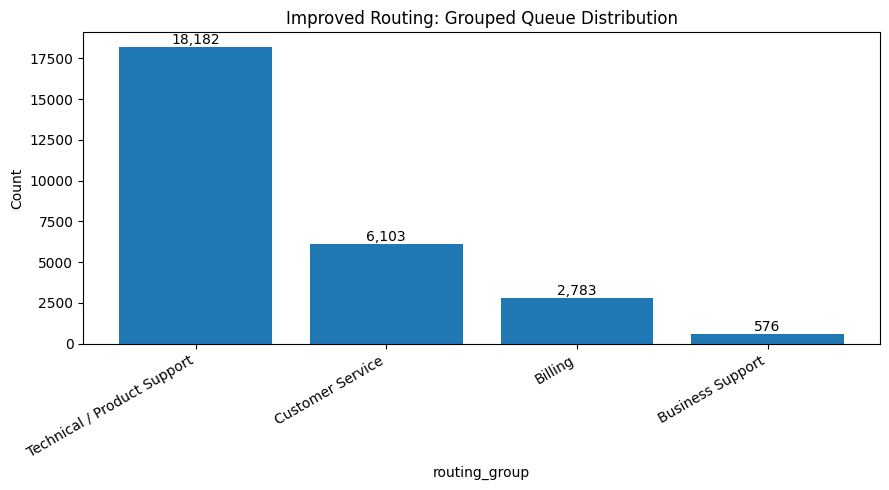

,original_queue,routing_group
0,Technical Support,Technical / Product Support
1,IT Support,Technical / Product Support
2,Product Support,Technical / Product Support
3,Service Outages And Maintenance,Technical / Product Support
4,Billing And Payments,Billing
5,Customer Service,Customer Service
6,Returns And Exchanges,Customer Service
7,General Inquiry,Customer Service
8,Sales And Pre-Sales,Business Support
9,Human Resources,Business Support


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/routing_group_mapping.csv

PART C: OUTER HOLDOUT + INNER VALIDATION SPLIT
Outer train size: 22115
Outer test size: 5529
Inner train size: 16586
Inner validation size: 5529

Outer test distribution:


,routing_group,count,percent
0,Technical / Product Support,3636,65.76
1,Customer Service,1221,22.08
2,Billing,557,10.07
3,Business Support,115,2.08



PART D: DEFINE CANDIDATE ROUTING MODELS
Routing candidate models:
- Grouped Routing Logistic Regression - word 1-2gram
- Grouped Routing Logistic Regression - word 1-3gram
- Grouped Routing SGD Logistic
- Grouped Routing Complement Naive Bayes
- Grouped Routing Calibrated LinearSVC

PART E: INNER VALIDATION MODEL SELECTION

----------------------------------------------------------------------------------------------------
Training routing candidate model: Grouped Routing Logistic Regression - word 1-2gram
----------------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------------
Training routing candidate model: Grouped Routing Logistic Regression - word 1-3gram
----------------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------------

,model_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
2,Grouped Routing SGD Logistic,0.7947,0.7807,0.6596,0.7029,0.7900
4,Grouped Routing Calibrated LinearSVC,0.7967,0.8288,0.6107,0.6761,0.7816
1,Grouped Routing Logistic Regression - word 1-3...,0.7616,0.7040,0.6972,0.6978,0.7662
0,Grouped Routing Logistic Regression - word 1-2...,0.7609,0.6926,0.6993,0.6942,0.7659
3,Grouped Routing Complement Naive Bayes,0.7036,0.7007,0.5501,0.5789,0.7095


...

,model_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
2,Grouped Routing SGD Logistic,0.7947,0.7807,0.6596,0.7029,0.79



PART F: TRAIN FINAL ROUTING MODEL ON OUTER TRAIN

FINAL GROUPED ROUTING OUTER TEST METRICS:


,model_name,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Final Grouped Routing Model - Grouped Routing ...,0.8061,0.7857,0.673,0.7162,0.801



Final grouped routing classification report:
                             precision    recall  f1-score   support

                    Billing       0.83      0.75      0.79       557
           Business Support       0.82      0.47      0.60       115
           Customer Service       0.65      0.57      0.61      1221
Technical / Product Support       0.85      0.90      0.88      3636

                   accuracy                           0.81      5529
                  macro avg       0.79      0.67      0.72      5529
               weighted avg       0.80      0.81      0.80      5529

Final Grouped Routing Model - Outer Test Confusion Matrix


,Predicted Billing,Predicted Business Support,Predicted Customer Service,Predicted Technical / Product Support
Actual Billing,416,2,63,76
Actual Business Support,6,54,20,35
Actual Customer Service,39,3,697,482
Actual Technical / Product Support,39,7,300,3290


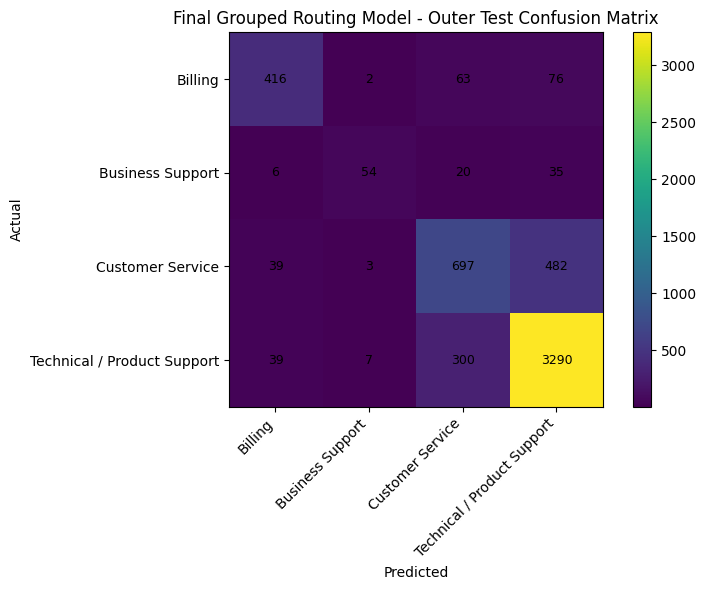


PART G: FINAL ROUTING PREDICTION OUTPUT TABLE
Final grouped routing prediction examples:


,ticket_text,actual_routing_group,predicted_routing_group,routing_confidence,correct_prediction,routing_action
0,issues with digital marketing campaign discrep...,Billing,Billing,0.9895,1,Auto-route to predicted queue
1,delays in data processing at financial institu...,Technical / Product Support,Technical / Product Support,0.8925,1,Auto-route to predicted queue
2,service outages our marketing agency is facing...,Technical / Product Support,Technical / Product Support,0.9825,1,Auto-route to predicted queue
3,sicherheitsfall potenzieller verlust medizinis...,Technical / Product Support,Technical / Product Support,0.4990,1,Manual triage required
4,dringende sicherheitsgef hrdung im gesundheits...,Technical / Product Support,Technical / Product Support,0.8586,1,Auto-route to predicted queue
5,concerns with marketing efforts we have encoun...,Technical / Product Support,Technical / Product Support,0.9188,1,Auto-route to predicted queue
6,urgent major system failure noted customer sup...,Technical / Product Support,Technical / Product Support,0.9358,1,Auto-route to predicted queue
7,software problem assistance required resolve t...,Technical / Product Support,Technical / Product Support,0.4357,1,Manual triage required
8,optimierung von datenanalyse-tools ich schreib...,Customer Service,Technical / Product Support,0.5632,0,Route with human review
9,problem mit digitalen marketing-werkzeugen die...,Technical / Product Support,Technical / Product Support,0.9186,1,Auto-route to predicted queue



Final grouped routing action distribution:


,routing_action,count,percent
0,Route with human review,2559,46.28
1,Auto-route to predicted queue,2454,44.38
2,Manual triage required,516,9.33



Incorrect grouped routing examples:


,ticket_text,actual_routing_group,predicted_routing_group,routing_confidence,correct_prediction,routing_action
8,optimierung von datenanalyse-tools ich schreib...,Customer Service,Technical / Product Support,0.5632,0,Route with human review
16,versto gegen datenschutz im medizinischen sekt...,Customer Service,Technical / Product Support,0.6628,0,Route with human review
23,would you like to receive information about di...,Technical / Product Support,Customer Service,0.5411,0,Route with human review
26,sicherheitsvorfall melden unbefugter zugriff a...,Billing,Technical / Product Support,0.7487,0,Route with human review
34,can you offer assistance with integrating cass...,Technical / Product Support,Customer Service,0.7599,0,Route with human review
38,assistance with digital marketing tactics inqu...,Billing,Customer Service,0.3977,0,Manual triage required
49,problem with recent integration update dear cu...,Customer Service,Technical / Product Support,0.9056,0,Auto-route to predicted queue
51,berarbeitete unterst tzung f r ineffektive mar...,Customer Service,Technical / Product Support,0.8357,0,Auto-route to predicted queue
52,schutz medizinischer datensysteme k nnten sie ...,Technical / Product Support,Customer Service,0.4349,0,Manual triage required
58,request for marketing support there is an expe...,Technical / Product Support,Customer Service,0.5971,0,Route with human review



PART H: ROUTING CONFIDENCE BUCKET ANALYSIS
Routing confidence bucket summary:


,confidence_bucket,ticket_count,accuracy,avg_confidence
0,Low confidence (<0.50),516,50.39,0.446
1,Medium confidence (0.50-0.80),2559,72.37,0.655
2,High confidence (>=0.80),2454,95.56,0.905


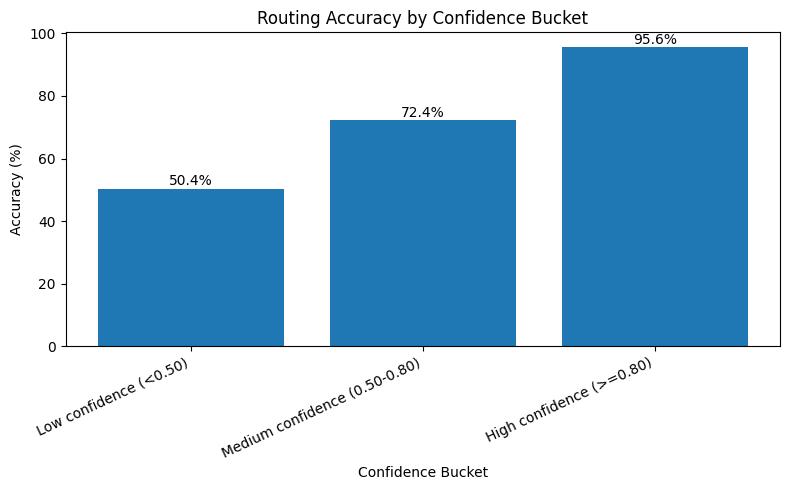

Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/routing_confidence_bucket_summary.csv

PART I: DEMO TEST USING FINAL GROUPED ROUTING MODEL
Final grouped routing demo predictions:


,subject,predicted_routing_group,routing_confidence,routing_action
0,Payment gateway down for all customers,Billing,0.9912,Auto-route to predicted queue
1,Need password reset,Billing,0.5970,Route with human review
2,Laptop screen flickering,Technical / Product Support,0.9086,Auto-route to predicted queue
3,API returning 500 errors,Technical / Product Support,0.8841,Auto-route to predicted queue
4,Question about invoice,Billing,0.9853,Auto-route to predicted queue



PART J: SAVE FINAL GROUPED ROUTING MODEL AND OUTPUTS
Saved model: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Models/final_grouped_queue_routing_model.pkl


,model_name,dataset,split_strategy,target,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,number_of_routing_groups,recommended_use
0,Final Grouped Routing Model - Grouped Routing ...,multilingual_ticket_dataset,outer_train_test_plus_inner_validation_holdout,routing_group,0.8061,0.7857,0.673,0.7162,0.801,4,Final routing model for TriageIQ demo


Skipped intermediate file: grouped_queue_routing_model_metrics.csv
Skipped intermediate file: grouped_queue_routing_predictions.csv
Skipped intermediate file: grouped_queue_routing_demo_predictions.csv

SECTION 5B COMPLETE: IMPROVED GROUPED ROUTING MODEL TRAINED AND SAVED


In [21]:
section_header("SECTION 5B: IMPROVED GROUPED ROUTING MODEL WITH OUTER/INNER HOLDOUT")

# PART A: CREATE IMPROVED ROUTING DATASET

section_header("PART B: CREATE IMPROVED ROUTING DATASET")

improved_route_df = multi_queue_model_df.copy()

# 1. Build stronger model text

if "ticket_text_with_tags" in improved_route_df.columns:
    improved_route_df["base_text"] = improved_route_df["ticket_text_with_tags"].fillna("").astype(str)
else:
    improved_route_df["base_text"] = improved_route_df["ticket_text"].fillna("").astype(str)

improved_route_df["model_text"] = improved_route_df["base_text"]

if "ticket_type_label" in improved_route_df.columns:
    improved_route_df["model_text"] = (
        improved_route_df["model_text"] + " ticket_type_" +
        improved_route_df["ticket_type_label"].fillna("").astype(str)
    )

if "priority_3class" in improved_route_df.columns:
    improved_route_df["model_text"] = (
        improved_route_df["model_text"] + " priority_" +
        improved_route_df["priority_3class"].fillna("").astype(str)
    )

improved_route_df["model_text"] = improved_route_df["model_text"].apply(clean_text_basic)

# 2. Group original queue labels into broader routing groups

def map_queue_to_business_group(queue_label):
    """
    Maps original queue labels into broader business-friendly routing groups.
    """

    q = str(queue_label).strip().lower()

    if q in [
        "technical support",
        "it support",
        "service outages and maintenance",
        "product support"
    ]:
        return "Technical / Product Support"

    elif q in [
        "billing and payments"
    ]:
        return "Billing"

    elif q in [
        "customer service",
        "returns and exchanges",
        "general inquiry"
    ]:
        return "Customer Service"

    elif q in [
        "sales and pre-sales",
        "human resources"
    ]:
        return "Business Support"

    else:
        return "Other"


improved_route_df["routing_group"] = improved_route_df["queue_label"].apply(map_queue_to_business_group)

# Remove weak/unknown rows
improved_route_df = improved_route_df[
    (improved_route_df["model_text"].str.strip() != "") &
    (improved_route_df["routing_group"] != "Other")
].copy()

print("Improved routing dataset shape:")
print(improved_route_df.shape)

print("\nOriginal queue distribution:")
display(categorical_distribution(improved_route_df, "queue_label", top_n=15))

print("\nGrouped routing distribution:")
display(categorical_distribution(improved_route_df, "routing_group", top_n=10))

plot_value_counts(
    improved_route_df,
    "routing_group",
    title="Improved Routing: Grouped Queue Distribution",
    top_n=10,
    rotation=30
)

# Save mapping table for report/slides
routing_group_mapping_df = pd.DataFrame([
    {"original_queue": "Technical Support", "routing_group": "Technical / Product Support"},
    {"original_queue": "IT Support", "routing_group": "Technical / Product Support"},
    {"original_queue": "Product Support", "routing_group": "Technical / Product Support"},
    {"original_queue": "Service Outages And Maintenance", "routing_group": "Technical / Product Support"},
    {"original_queue": "Billing And Payments", "routing_group": "Billing"},
    {"original_queue": "Customer Service", "routing_group": "Customer Service"},
    {"original_queue": "Returns And Exchanges", "routing_group": "Customer Service"},
    {"original_queue": "General Inquiry", "routing_group": "Customer Service"},
    {"original_queue": "Sales And Pre-Sales", "routing_group": "Business Support"},
    {"original_queue": "Human Resources", "routing_group": "Business Support"}
])

display(routing_group_mapping_df)
save_output(routing_group_mapping_df, "routing_group_mapping.csv")


# PART C: OUTER HOLDOUT + INNER VALIDATION SPLIT

section_header("PART C: OUTER HOLDOUT + INNER VALIDATION SPLIT")

X_route = improved_route_df["model_text"]
y_route = improved_route_df["routing_group"]

# Outer split: untouched final test set
X_route_outer_train, X_route_outer_test, y_route_outer_train, y_route_outer_test = train_test_split(
    X_route,
    y_route,
    test_size=0.20,
    random_state=42,
    stratify=y_route
)

# Inner split: model selection validation set
X_route_inner_train, X_route_inner_val, y_route_inner_train, y_route_inner_val = train_test_split(
    X_route_outer_train,
    y_route_outer_train,
    test_size=0.25,
    random_state=42,
    stratify=y_route_outer_train
)

print("Outer train size:", len(X_route_outer_train))
print("Outer test size:", len(X_route_outer_test))
print("Inner train size:", len(X_route_inner_train))
print("Inner validation size:", len(X_route_inner_val))

print("\nOuter test distribution:")
outer_test_dist = y_route_outer_test.value_counts().reset_index()
outer_test_dist.columns = ["routing_group", "count"]
outer_test_dist["percent"] = (outer_test_dist["count"] / len(y_route_outer_test) * 100).round(2)
display(outer_test_dist)


# PART D: DEFINE CANDIDATE ROUTING MODELS

section_header("PART D: DEFINE CANDIDATE ROUTING MODELS")

routing_candidate_models = {
    "Grouped Routing Logistic Regression - word 1-2gram": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                stop_words="english"
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                C=2.0,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "Grouped Routing Logistic Regression - word 1-3gram": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=70000,
                ngram_range=(1, 3),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                stop_words="english"
            )
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2500,
                class_weight="balanced",
                C=2.0,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "Grouped Routing SGD Logistic": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=70000,
                ngram_range=(1, 3),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                stop_words="english"
            )
        ),
        (
            "classifier",
            SGDClassifier(
                loss="log_loss",
                alpha=1e-5,
                penalty="l2",
                class_weight="balanced",
                max_iter=2000,
                random_state=42,
                n_jobs=-1
            )
        )
    ]),

    "Grouped Routing Complement Naive Bayes": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=50000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                stop_words="english"
            )
        ),
        (
            "classifier",
            ComplementNB(alpha=0.3)
        )
    ]),

    "Grouped Routing Calibrated LinearSVC": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=70000,
                ngram_range=(1, 3),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                stop_words="english"
            )
        ),
        (
            "classifier",
            CalibratedClassifierCV(
                estimator=LinearSVC(
                    class_weight="balanced",
                    C=1.0,
                    random_state=42
                ),
                cv=3
            )
        )
    ])
}

print("Routing candidate models:")
for model_name in routing_candidate_models.keys():
    print("-", model_name)


# PART E: INNER VALIDATION MODEL SELECTION

section_header("PART E: INNER VALIDATION MODEL SELECTION")

routing_validation_results = []

for model_name, model in routing_candidate_models.items():
    subsection_header(f"Training routing candidate model: {model_name}")

    temp_model = clone(model)
    temp_model.fit(X_route_inner_train, y_route_inner_train)

    val_pred = temp_model.predict(X_route_inner_val)

    val_metrics = evaluate_multiclass_model(
        y_true=y_route_inner_val,
        y_pred=val_pred,
        model_name=model_name
    )

    routing_validation_results.append(val_metrics)

routing_validation_results_df = pd.DataFrame(routing_validation_results)

print("\nGrouped routing validation model comparison:")
display(
    routing_validation_results_df
    .sort_values(["weighted_f1", "macro_f1"], ascending=False)
    .round(4)
)

save_output(routing_validation_results_df, "grouped_routing_inner_validation_results.csv")

# Select best model by weighted F1, then macro F1
best_routing_row = (
    routing_validation_results_df
    .sort_values(["weighted_f1", "macro_f1"], ascending=False)
    .iloc[0]
)

best_routing_model_name = best_routing_row["model_name"]

print("\nSelected best routing model from inner validation:")
print(best_routing_model_name)

display(pd.DataFrame([best_routing_row]).round(4))


# PART F: TRAIN FINAL ROUTING MODEL ON OUTER TRAIN

section_header("PART F: TRAIN FINAL ROUTING MODEL ON OUTER TRAIN")

final_routing_model = clone(routing_candidate_models[best_routing_model_name])

final_routing_model.fit(
    X_route_outer_train,
    y_route_outer_train
)

final_route_test_pred = final_routing_model.predict(X_route_outer_test)
final_route_test_proba = safe_predict_proba(final_routing_model, X_route_outer_test)

final_routing_metrics = evaluate_multiclass_model(
    y_true=y_route_outer_test,
    y_pred=final_route_test_pred,
    model_name=f"Final Grouped Routing Model - {best_routing_model_name}"
)

print("\nFINAL GROUPED ROUTING OUTER TEST METRICS:")
display(pd.DataFrame([final_routing_metrics]).round(4))

print("\nFinal grouped routing classification report:")
print(classification_report(y_route_outer_test, final_route_test_pred, zero_division=0))

routing_group_labels = sorted(y_route.unique())

final_grouped_routing_cm_df = plot_clean_confusion_matrix(
    y_true=y_route_outer_test,
    y_pred=final_route_test_pred,
    labels=routing_group_labels,
    title="Final Grouped Routing Model - Outer Test Confusion Matrix"
)


# PART G: FINAL ROUTING PREDICTION OUTPUT TABLE

section_header("PART G: FINAL ROUTING PREDICTION OUTPUT TABLE")

final_routing_results_df = pd.DataFrame({
    "ticket_text": X_route_outer_test.values,
    "actual_routing_group": y_route_outer_test.values,
    "predicted_routing_group": final_route_test_pred,
    "routing_confidence": final_route_test_proba.max(axis=1)
})

final_routing_results_df["correct_prediction"] = (
    final_routing_results_df["actual_routing_group"] ==
    final_routing_results_df["predicted_routing_group"]
).astype(int)

final_routing_results_df["routing_action"] = final_routing_results_df["routing_confidence"].apply(get_queue_action)

print("Final grouped routing prediction examples:")
display(final_routing_results_df.head(10).round(4))

print("\nFinal grouped routing action distribution:")
routing_action_summary = (
    final_routing_results_df["routing_action"]
    .value_counts()
    .reset_index()
)

routing_action_summary.columns = ["routing_action", "count"]
routing_action_summary["percent"] = (
    routing_action_summary["count"] / len(final_routing_results_df) * 100
).round(2)

display(routing_action_summary)

print("\nIncorrect grouped routing examples:")
display(
    final_routing_results_df[
        final_routing_results_df["correct_prediction"] == 0
    ].head(10).round(4)
)


# PART H: CONFIDENCE BUCKET ANALYSIS

section_header("PART H: ROUTING CONFIDENCE BUCKET ANALYSIS")

confidence_analysis_df = final_routing_results_df.copy()

confidence_analysis_df["confidence_bucket"] = pd.cut(
    confidence_analysis_df["routing_confidence"],
    bins=[0, 0.50, 0.80, 1.00],
    labels=[
        "Low confidence (<0.50)",
        "Medium confidence (0.50-0.80)",
        "High confidence (>=0.80)"
    ],
    include_lowest=True
)

confidence_bucket_summary_df = (
    confidence_analysis_df
    .groupby("confidence_bucket")
    .agg(
        ticket_count=("correct_prediction", "count"),
        accuracy=("correct_prediction", "mean"),
        avg_confidence=("routing_confidence", "mean")
    )
    .reset_index()
)

confidence_bucket_summary_df["accuracy"] = (
    confidence_bucket_summary_df["accuracy"] * 100
).round(2)

confidence_bucket_summary_df["avg_confidence"] = (
    confidence_bucket_summary_df["avg_confidence"]
).round(3)

print("Routing confidence bucket summary:")
display(confidence_bucket_summary_df)

plt.figure(figsize=(8, 5))
plt.bar(
    confidence_bucket_summary_df["confidence_bucket"].astype(str),
    confidence_bucket_summary_df["accuracy"]
)

plt.title("Routing Accuracy by Confidence Bucket")
plt.xlabel("Confidence Bucket")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=25, ha="right")

for i, v in enumerate(confidence_bucket_summary_df["accuracy"]):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

save_output(confidence_bucket_summary_df, "routing_confidence_bucket_summary.csv")


# PART I: DEMO TEST USING FINAL GROUPED ROUTING MODEL

section_header("PART I: DEMO TEST USING FINAL GROUPED ROUTING MODEL")

routing_demo_tickets_final = pd.DataFrame([
    {
        "subject": "Payment gateway down for all customers",
        "body": "Customers are unable to complete checkout and payments are failing.",
        "tags": "payment checkout transaction outage billing"
    },
    {
        "subject": "Need password reset",
        "body": "I forgot my password and cannot log in to my account.",
        "tags": "login password account access"
    },
    {
        "subject": "Laptop screen flickering",
        "body": "My laptop screen keeps flickering when I connect it to an external monitor.",
        "tags": "hardware laptop monitor device"
    },
    {
        "subject": "API returning 500 errors",
        "body": "Our production API integration is failing with repeated 500 errors.",
        "tags": "api technical error production integration"
    },
    {
        "subject": "Question about invoice",
        "body": "I have a question about a recent invoice charge.",
        "tags": "invoice billing charge payment"
    }
])

routing_demo_tickets_final["model_text"] = (
    routing_demo_tickets_final["subject"] + " " +
    routing_demo_tickets_final["body"] + " " +
    routing_demo_tickets_final["tags"]
).apply(clean_text_basic)

routing_demo_tickets_final["predicted_routing_group"] = final_routing_model.predict(
    routing_demo_tickets_final["model_text"]
)

routing_demo_final_proba = safe_predict_proba(
    final_routing_model,
    routing_demo_tickets_final["model_text"]
)

routing_demo_tickets_final["routing_confidence"] = routing_demo_final_proba.max(axis=1)
routing_demo_tickets_final["routing_action"] = routing_demo_tickets_final["routing_confidence"].apply(get_queue_action)

print("Final grouped routing demo predictions:")
display(
    routing_demo_tickets_final[
        [
            "subject",
            "predicted_routing_group",
            "routing_confidence",
            "routing_action"
        ]
    ].round(4)
)


# PART J: SAVE FINAL GROUPED ROUTING MODEL AND OUTPUTS

section_header("PART J: SAVE FINAL GROUPED ROUTING MODEL AND OUTPUTS")

final_routing_model_name = f"Final Grouped Routing Model - {best_routing_model_name}"

save_model(final_routing_model, "final_grouped_queue_routing_model.pkl")

final_grouped_routing_metrics_df = pd.DataFrame([{
    "model_name": final_routing_model_name,
    "dataset": "multilingual_ticket_dataset",
    "split_strategy": "outer_train_test_plus_inner_validation_holdout",
    "target": "routing_group",
    "accuracy": final_routing_metrics["accuracy"],
    "macro_precision": final_routing_metrics["macro_precision"],
    "macro_recall": final_routing_metrics["macro_recall"],
    "macro_f1": final_routing_metrics["macro_f1"],
    "weighted_f1": final_routing_metrics["weighted_f1"],
    "number_of_routing_groups": len(routing_group_labels),
    "recommended_use": "Final routing model for TriageIQ demo"
}])

display(final_grouped_routing_metrics_df.round(4))

save_output(final_grouped_routing_metrics_df, "grouped_queue_routing_model_metrics.csv")
save_output(final_routing_results_df, "grouped_queue_routing_predictions.csv")
save_output(routing_demo_tickets_final, "grouped_queue_routing_demo_predictions.csv")

section_header("SECTION 5B COMPLETE: IMPROVED GROUPED ROUTING MODEL TRAINED AND SAVED")

## Section 6: SLA Risk Scoring and Optional SLA Machine Learning Models

This section handles SLA risk. SLA breach means the support team misses the promised response or resolution deadline.

The notebook tests Logistic Regression and XGBoost models for SLA breach prediction. Since the SLA models do not show strong predictive performance, the final system uses a transparent rule-based SLA risk score instead. This rule-based score considers priority, issue complexity, subscription type, customer segment, previous tickets, and support channel.


SECTION 6: SLA RISK SCORING + OPTIONAL SLA ML MODELS

PART A: DEFINE UPDATED RULE-BASED SLA RISK SCORE
Updated rule-based SLA risk examples:


,example,predicted_priority,issue_complexity_score,subscription_type,customer_segment,previous_tickets,channel,sla_risk_score,sla_breach_probability,sla_risk_level,sla_action
0,High priority enterprise issue,High,9,enterprise,corporate,8,web form,12,0.95,High SLA Risk,Escalate or assign immediately
1,Normal password reset,Normal,2,basic,individual,1,email,0,0.00,Low SLA Risk,Normal handling
2,Medium complexity small business issue,Needs Review,5,premium,small business,3,chat,6,0.60,Medium SLA Risk,Review queue and monitor closely



PART B: PREPARE SLA ML DATASET
SLA model dataset shape:
(200000, 29)

SLA target distribution:


,label,count,percent
0,SLA Breach,100043,50.02
1,No SLA Breach,99957,49.98



PART C: OPTIONAL SLA LOGISTIC REGRESSION MODEL
SLA feature columns:
['issue_text', 'product_clean', 'category_clean', 'priority_clean', 'channel_clean', 'region_clean', 'subscription_type_clean', 'customer_segment_clean', 'language_clean', 'customer_tenure_months', 'previous_tickets', 'issue_complexity_score', 'created_year', 'created_month', 'created_dayofweek', 'created_hour', 'created_is_weekend', 'created_is_business_hours', 'has_outage_keyword', 'has_payment_keyword', 'has_access_keyword', 'has_technical_keyword', 'has_hardware_keyword', 'has_urgent_keyword', 'text_length', 'word_count', 'question_mark_count', 'exclamation_count']

SLA train size: 160000
SLA test size: 40000

Optional SLA Logistic Regression metrics:


,model_name,accuracy,precision,recall,f1,roc_auc
0,Optional SLA Logistic Regression,0.496,0.4961,0.4889,0.4925,0.4924



Classification report:
              precision    recall  f1-score   support

   No Breach       0.50      0.50      0.50     19991
      Breach       0.50      0.49      0.49     20009

    accuracy                           0.50     40000
   macro avg       0.50      0.50      0.50     40000
weighted avg       0.50      0.50      0.50     40000

Optional SLA Logistic Regression Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,10056,9935
Actual 1,10227,9782


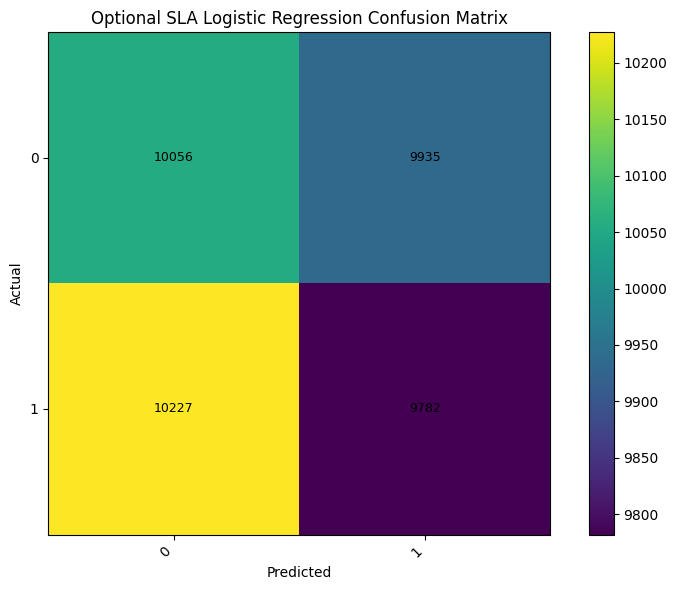

Skipped intermediate model: optional_sla_logistic_model.pkl

PART D: OPTIONAL SLA XGBOOST MODEL

Optional SLA XGBoost metrics:


,model_name,accuracy,precision,recall,f1,roc_auc
0,Optional SLA XGBoost,0.4953,0.4955,0.4978,0.4967,0.4959



Classification report:
              precision    recall  f1-score   support

   No Breach       0.50      0.49      0.49     19991
      Breach       0.50      0.50      0.50     20009

    accuracy                           0.50     40000
   macro avg       0.50      0.50      0.50     40000
weighted avg       0.50      0.50      0.50     40000

Optional SLA XGBoost Confusion Matrix


,Predicted 0,Predicted 1
Actual 0,9851,10140
Actual 1,10048,9961


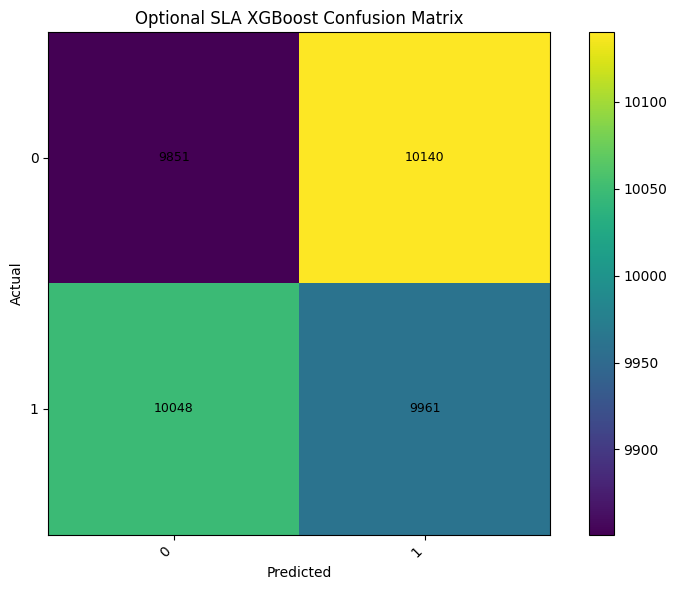

Skipped intermediate model: optional_sla_xgboost_model.pkl

PART E: SLA MODEL COMPARISON AND FINAL DECISION
Optional SLA ML model comparison:


,model_name,accuracy,precision,recall,f1,roc_auc
0,Optional SLA Logistic Regression,0.4960,0.4961,0.4889,0.4925,0.4924
1,Optional SLA XGBoost,0.4953,0.4955,0.4978,0.4967,0.4959



Final SLA decision:


,final_sla_method,best_sla_ml_auc,decision_note
0,rule_based,0.495937,SLA ML models did not show strong predictive s...


Skipped intermediate file: optional_sla_model_comparison.csv
Skipped intermediate file: sla_final_decision.csv

PART F: ADD UPDATED RULE-BASED SLA RISK TO DASHBOARD DATA
Dashboard data with updated rule-based SLA risk shape:
(200000, 37)

Updated Rule-Based SLA Risk Added to Dashboard Data


,ticket_id,priority_3class,demo_priority_label,issue_complexity_score,subscription_type,customer_segment,previous_tickets,channel,sla_risk_score,sla_risk_level,sla_action
0,1,High,High,4.0,Free,Small Business,6.0,Email,6,Medium SLA Risk,Review queue and monitor closely
1,2,High,High,2.0,Premium,Small Business,20.0,Email,7,Medium SLA Risk,Review queue and monitor closely
2,3,Medium,Needs Review,4.0,Premium,Corporate,20.0,Chat,7,Medium SLA Risk,Review queue and monitor closely
3,4,Medium,Needs Review,7.0,Enterprise,Corporate,18.0,Social Media,9,High SLA Risk,Escalate or assign immediately
4,5,High,High,3.0,Enterprise,Corporate,8.0,Email,9,High SLA Risk,Escalate or assign immediately
5,6,Low,Normal,9.0,Enterprise,Corporate,2.0,Social Media,8,High SLA Risk,Escalate or assign immediately
6,7,Medium,Needs Review,5.0,Basic,Corporate,7.0,Phone,7,Medium SLA Risk,Review queue and monitor closely
7,8,Low,Normal,7.0,Free,Individual,20.0,Phone,4,Low SLA Risk,Normal handling
8,9,Low,Normal,3.0,Enterprise,Individual,12.0,Chat,5,Medium SLA Risk,Review queue and monitor closely
9,10,High,High,10.0,Free,Individual,5.0,Social Media,8,High SLA Risk,Escalate or assign immediately


Showing first 10 rows out of 200,000 rows.

Updated rule-based SLA risk distribution:


,sla_risk_level,count,percent
0,Medium SLA Risk,88437,44.22
1,High SLA Risk,79406,39.70
2,Low SLA Risk,32157,16.08


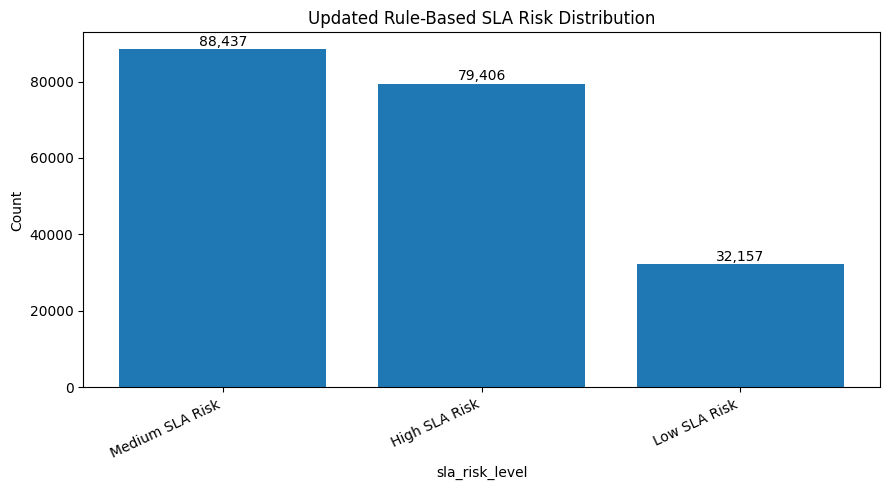

Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/triageiq_dashboard_data_with_rule_sla.csv


In [22]:
section_header("SECTION 6: SLA RISK SCORING + OPTIONAL SLA ML MODELS")


# PART A: DEFINE UPDATED RULE-BASED SLA RISK SCORE

section_header("PART A: DEFINE UPDATED RULE-BASED SLA RISK SCORE")

def rule_based_sla_risk(
    predicted_priority,
    issue_complexity_score=5,
    subscription_type="premium",
    customer_segment="small business",
    previous_tickets=2,
    channel="web form"
):

    score = 0

    # 1. Priority impact

    if predicted_priority == "High":
        score += 3
    elif predicted_priority == "Needs Review":
        score += 1

    # 2. Complexity impact

    try:
        issue_complexity_score = float(issue_complexity_score)
    except Exception:
        issue_complexity_score = 5

    if issue_complexity_score >= 8:
        score += 3
    elif issue_complexity_score >= 5:
        score += 1

    # 3. Customer value impact

    subscription_type = str(subscription_type).lower().strip()
    customer_segment = str(customer_segment).lower().strip()

    if subscription_type == "enterprise":
        score += 2
    elif subscription_type == "premium":
        score += 1

    if customer_segment in ["corporate", "enterprise"]:
        score += 2
    elif customer_segment in ["small business", "business"]:
        score += 1

    # 4. Previous ticket activity impact

    try:
        previous_tickets = float(previous_tickets)
    except Exception:
        previous_tickets = 2

    if previous_tickets >= 6:
        score += 2
    elif previous_tickets >= 3:
        score += 1

    # 5. Channel urgency impact

    channel = str(channel).lower().strip()

    if channel in ["phone", "chat", "social media"]:
        score += 1

    # 6. Updated stricter SLA risk thresholds

    if score >= 8:
        risk_level = "High SLA Risk"
        action = "Escalate or assign immediately"
    elif score >= 5:
        risk_level = "Medium SLA Risk"
        action = "Review queue and monitor closely"
    else:
        risk_level = "Low SLA Risk"
        action = "Normal handling"

    probability_like_score = min(score / 10, 0.95)

    return {
        "sla_risk_score": score,
        "sla_breach_probability": round(probability_like_score, 4),
        "sla_risk_level": risk_level,
        "sla_action": action
    }


# Test updated SLA rule

sla_rule_examples = pd.DataFrame([
    {
        "example": "High priority enterprise issue",
        "predicted_priority": "High",
        "issue_complexity_score": 9,
        "subscription_type": "enterprise",
        "customer_segment": "corporate",
        "previous_tickets": 8,
        "channel": "web form"
    },
    {
        "example": "Normal password reset",
        "predicted_priority": "Normal",
        "issue_complexity_score": 2,
        "subscription_type": "basic",
        "customer_segment": "individual",
        "previous_tickets": 1,
        "channel": "email"
    },
    {
        "example": "Medium complexity small business issue",
        "predicted_priority": "Needs Review",
        "issue_complexity_score": 5,
        "subscription_type": "premium",
        "customer_segment": "small business",
        "previous_tickets": 3,
        "channel": "chat"
    }
])

sla_rule_results = []

for _, row in sla_rule_examples.iterrows():
    result = rule_based_sla_risk(
        predicted_priority=row["predicted_priority"],
        issue_complexity_score=row["issue_complexity_score"],
        subscription_type=row["subscription_type"],
        customer_segment=row["customer_segment"],
        previous_tickets=row["previous_tickets"],
        channel=row["channel"]
    )

    combined = row.to_dict()
    combined.update(result)
    sla_rule_results.append(combined)

sla_rule_results_df = pd.DataFrame(sla_rule_results)

print("Updated rule-based SLA risk examples:")
display(sla_rule_results_df)


# PART B: PREPARE SLA ML DATASET

section_header("PART B: PREPARE SLA ML DATASET")

if not sla_model_df.empty:
    sla_df = sla_model_df.copy()

    sla_df = sla_df[
        sla_df["sla_breached_binary"].notna()
    ].copy()

    sla_df["sla_breached_binary"] = sla_df["sla_breached_binary"].astype(int)

    print("SLA model dataset shape:")
    print(sla_df.shape)

    print("\nSLA target distribution:")
    sla_target_dist = (
        sla_df["sla_breached_binary"]
        .value_counts()
        .reset_index()
    )

    sla_target_dist.columns = ["sla_breached_binary", "count"]
    sla_target_dist["label"] = sla_target_dist["sla_breached_binary"].map({
        0: "No SLA Breach",
        1: "SLA Breach"
    })
    sla_target_dist["percent"] = (
        sla_target_dist["count"] / len(sla_df) * 100
    ).round(2)

    display(sla_target_dist[["label", "count", "percent"]])

else:
    print("sla_model_df is empty. SLA ML models will be skipped.")
    sla_df = pd.DataFrame()


# PART C: OPTIONAL SLA LOGISTIC REGRESSION MODEL

section_header("PART C: OPTIONAL SLA LOGISTIC REGRESSION MODEL")

sla_lr_metrics = None
sla_logistic_model = None

if not sla_df.empty:

    sla_target_col = "sla_breached_binary"
    sla_text_col = "issue_text"

    sla_categorical_cols = [
        "product_clean",
        "category_clean",
        "priority_clean",
        "channel_clean",
        "region_clean",
        "subscription_type_clean",
        "customer_segment_clean",
        "language_clean"
    ]

    sla_numeric_cols = [
        "customer_tenure_months",
        "previous_tickets",
        "issue_complexity_score",
        "created_year",
        "created_month",
        "created_dayofweek",
        "created_hour",
        "created_is_weekend",
        "created_is_business_hours",
        "has_outage_keyword",
        "has_payment_keyword",
        "has_access_keyword",
        "has_technical_keyword",
        "has_hardware_keyword",
        "has_urgent_keyword",
        "text_length",
        "word_count",
        "question_mark_count",
        "exclamation_count"
    ]

    sla_categorical_cols = [col for col in sla_categorical_cols if col in sla_df.columns]
    sla_numeric_cols = [col for col in sla_numeric_cols if col in sla_df.columns]

    if sla_text_col not in sla_df.columns:
        sla_df[sla_text_col] = ""

    sla_df[sla_text_col] = sla_df[sla_text_col].fillna("").astype(str)

    for col in sla_categorical_cols:
        sla_df[col] = sla_df[col].fillna("unknown").astype(str)

    for col in sla_numeric_cols:
        sla_df[col] = pd.to_numeric(sla_df[col], errors="coerce")
        sla_df[col] = sla_df[col].fillna(sla_df[col].median())

    sla_feature_cols = [sla_text_col] + sla_categorical_cols + sla_numeric_cols

    print("SLA feature columns:")
    print(sla_feature_cols)

    X_sla = sla_df[sla_feature_cols]
    y_sla = sla_df[sla_target_col]

    X_sla_train, X_sla_test, y_sla_train, y_sla_test = train_test_split(
        X_sla,
        y_sla,
        test_size=0.20,
        random_state=42,
        stratify=y_sla
    )

    print("\nSLA train size:", len(X_sla_train))
    print("SLA test size:", len(X_sla_test))

    sla_preprocessor = ColumnTransformer(
        transformers=[
            (
                "text",
                TfidfVectorizer(
                    max_features=10000,
                    ngram_range=(1, 2),
                    min_df=2,
                    max_df=0.95,
                    sublinear_tf=True,
                    stop_words="english"
                ),
                sla_text_col
            ),
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore"),
                sla_categorical_cols
            ),
            (
                "numeric",
                StandardScaler(),
                sla_numeric_cols
            )
        ],
        remainder="drop"
    )

    sla_logistic_model = Pipeline([
        ("preprocessor", sla_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    sla_logistic_model.fit(X_sla_train, y_sla_train)

    sla_lr_proba = safe_predict_proba(sla_logistic_model, X_sla_test)[:, 1]
    sla_lr_pred = (sla_lr_proba >= 0.50).astype(int)

    sla_lr_metrics = evaluate_binary_model(
        y_true=y_sla_test,
        y_pred=sla_lr_pred,
        y_proba=sla_lr_proba,
        model_name="Optional SLA Logistic Regression"
    )

    print("\nOptional SLA Logistic Regression metrics:")
    display(pd.DataFrame([sla_lr_metrics]).round(4))

    print("\nClassification report:")
    print(
        classification_report(
            y_sla_test,
            sla_lr_pred,
            target_names=["No Breach", "Breach"],
            zero_division=0
        )
    )

    plot_clean_confusion_matrix(
        y_true=y_sla_test,
        y_pred=sla_lr_pred,
        labels=[0, 1],
        title="Optional SLA Logistic Regression Confusion Matrix"
    )

    save_model(sla_logistic_model, "optional_sla_logistic_model.pkl")

else:
    print("Skipping SLA Logistic Regression because sla_df is empty.")


# PART D: OPTIONAL SLA XGBOOST MODEL

section_header("PART D: OPTIONAL SLA XGBOOST MODEL")

sla_xgb_metrics = None
sla_xgb_model = None

if not sla_df.empty and XGBOOST_AVAILABLE:

    sla_xgb_model = Pipeline([
        ("preprocessor", sla_preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.07,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    sla_xgb_model.fit(X_sla_train, y_sla_train)

    sla_xgb_proba = safe_predict_proba(sla_xgb_model, X_sla_test)[:, 1]
    sla_xgb_pred = (sla_xgb_proba >= 0.50).astype(int)

    sla_xgb_metrics = evaluate_binary_model(
        y_true=y_sla_test,
        y_pred=sla_xgb_pred,
        y_proba=sla_xgb_proba,
        model_name="Optional SLA XGBoost"
    )

    print("\nOptional SLA XGBoost metrics:")
    display(pd.DataFrame([sla_xgb_metrics]).round(4))

    print("\nClassification report:")
    print(
        classification_report(
            y_sla_test,
            sla_xgb_pred,
            target_names=["No Breach", "Breach"],
            zero_division=0
        )
    )

    plot_clean_confusion_matrix(
        y_true=y_sla_test,
        y_pred=sla_xgb_pred,
        labels=[0, 1],
        title="Optional SLA XGBoost Confusion Matrix"
    )

    save_model(sla_xgb_model, "optional_sla_xgboost_model.pkl")

elif not XGBOOST_AVAILABLE:
    print("Skipping SLA XGBoost because XGBoost is not available.")
else:
    print("Skipping SLA XGBoost because sla_df is empty.")


# PART E: SLA MODEL COMPARISON AND FINAL DECISION

section_header("PART E: SLA MODEL COMPARISON AND FINAL DECISION")

sla_model_comparison_rows = []

if sla_lr_metrics is not None:
    sla_model_comparison_rows.append(sla_lr_metrics)

if sla_xgb_metrics is not None:
    sla_model_comparison_rows.append(sla_xgb_metrics)

if len(sla_model_comparison_rows) > 0:
    sla_model_comparison_df = pd.DataFrame(sla_model_comparison_rows)
else:
    sla_model_comparison_df = pd.DataFrame(columns=[
        "model_name",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ])

print("Optional SLA ML model comparison:")
display(sla_model_comparison_df.round(4))

if not sla_model_comparison_df.empty:
    best_sla_ml_auc = sla_model_comparison_df["roc_auc"].max()
else:
    best_sla_ml_auc = np.nan

if pd.notna(best_sla_ml_auc) and best_sla_ml_auc >= 0.65:
    sla_final_method = "rule_based_for_demo_ml_available_for_future"
    sla_decision_note = (
        "SLA ML model shows some signal, but final demo uses rule-based SLA scoring "
        "because it is easier to explain and safer for a prototype."
    )
else:
    sla_final_method = "rule_based"
    sla_decision_note = (
        "SLA ML models did not show strong predictive signal, so final demo uses transparent "
        "business-rule SLA scoring instead of overclaiming weak model performance."
    )

sla_decision_df = pd.DataFrame([{
    "final_sla_method": sla_final_method,
    "best_sla_ml_auc": best_sla_ml_auc,
    "decision_note": sla_decision_note
}])

print("\nFinal SLA decision:")
display(sla_decision_df)

save_output(sla_model_comparison_df, "optional_sla_model_comparison.csv")
save_output(sla_decision_df, "sla_final_decision.csv")


# PART F: ADD UPDATED RULE-BASED SLA RISK TO DASHBOARD DATA

section_header("PART F: ADD UPDATED RULE-BASED SLA RISK TO DASHBOARD DATA")

if not support_dashboard_df.empty:
    dashboard_sla_df = support_dashboard_df.copy()

    def convert_priority_3class_to_demo_priority(priority_3class):
        if priority_3class == "High":
            return "High"
        elif priority_3class == "Medium":
            return "Needs Review"
        else:
            return "Normal"

    if "priority_3class" in dashboard_sla_df.columns:
        dashboard_sla_df["demo_priority_label"] = dashboard_sla_df["priority_3class"].apply(
            convert_priority_3class_to_demo_priority
        )
    else:
        dashboard_sla_df["demo_priority_label"] = "Normal"

    default_dashboard_fields = {
        "issue_complexity_score": 5,
        "subscription_type": "premium",
        "customer_segment": "small business",
        "previous_tickets": 2,
        "channel": "web form"
    }

    for col, default_value in default_dashboard_fields.items():
        if col not in dashboard_sla_df.columns:
            dashboard_sla_df[col] = default_value

    rule_sla_rows = []

    for _, row in dashboard_sla_df.iterrows():
        result = rule_based_sla_risk(
            predicted_priority=row["demo_priority_label"],
            issue_complexity_score=row.get("issue_complexity_score", 5),
            subscription_type=row.get("subscription_type", "premium"),
            customer_segment=row.get("customer_segment", "small business"),
            previous_tickets=row.get("previous_tickets", 2),
            channel=row.get("channel", "web form")
        )

        rule_sla_rows.append(result)

    rule_sla_df = pd.DataFrame(rule_sla_rows)

    dashboard_sla_df = pd.concat(
        [
            dashboard_sla_df.reset_index(drop=True),
            rule_sla_df.reset_index(drop=True)
        ],
        axis=1
    )

    print("Dashboard data with updated rule-based SLA risk shape:")
    print(dashboard_sla_df.shape)

    display_cols = [
        "ticket_id",
        "priority_3class",
        "demo_priority_label",
        "issue_complexity_score",
        "subscription_type",
        "customer_segment",
        "previous_tickets",
        "channel",
        "sla_risk_score",
        "sla_risk_level",
        "sla_action"
    ]

    display_cols = [col for col in display_cols if col in dashboard_sla_df.columns]

    display_table(
        dashboard_sla_df[display_cols],
        title="Updated Rule-Based SLA Risk Added to Dashboard Data",
        max_rows=10
    )

    print("\nUpdated rule-based SLA risk distribution:")
    display(categorical_distribution(dashboard_sla_df, "sla_risk_level"))

    plot_value_counts(
        dashboard_sla_df,
        "sla_risk_level",
        title="Updated Rule-Based SLA Risk Distribution",
        top_n=10,
        rotation=25
    )

    save_output(dashboard_sla_df, "triageiq_dashboard_data_with_rule_sla.csv")

else:
    print("support_dashboard_df is empty. Could not create dashboard_sla_df.")
    dashboard_sla_df = pd.DataFrame()

## Section 7: Final TriageIQ Prediction Workflow and Response Generator

This section combines the main project components into one final TriageIQ workflow. When a new support ticket is entered, the system predicts priority, recommends a routing group, calculates SLA risk, gives a final action recommendation, and generates a first-response draft.

This section also includes simple keyword-based routing overrides for obvious cases like password/login issues and billing/payment issues. The final output is designed as an agent-assist workflow, meaning a human support agent reviews the AI recommendation before action is taken.

In [23]:
section_header("SECTION 7: FINAL TRIAGEIQ PREDICTION WORKFLOW + RESPONSE GENERATOR")

# PART A: LOAD FINAL MODELS

section_header("PART A: LOAD FINAL MODELS")

try:
    final_priority_model = load_model("final_priority_model.pkl")
except Exception as e:
    print("Could not load final priority model from file.")
    print("Using final_priority_model from notebook memory if available.")
    print("Error:", e)

try:
    final_routing_model = load_model("final_grouped_queue_routing_model.pkl")
except Exception as e:
    print("Could not load final grouped routing model from file.")
    print("Using final_routing_model from notebook memory if available.")
    print("Error:", e)

print("\nFinal models ready:")
print("- final_priority_model")
print("- final_routing_model")


# PART B: BUSINESS ACTION HELPER FUNCTIONS

section_header("PART B: FINAL BUSINESS ACTION HELPER FUNCTIONS")

def get_final_recommendation(predicted_priority, routing_confidence, sla_risk_level):
    """
    Combines priority, routing confidence, and SLA risk into one final action.
    """

    if predicted_priority == "High" or sla_risk_level == "High SLA Risk":
        return "Escalate to human agent immediately"

    elif predicted_priority == "Needs Review":
        return "Send to human triage review before routing"

    elif routing_confidence < 0.50:
        return "Manual triage required due to low routing confidence"

    elif sla_risk_level == "Medium SLA Risk":
        return "Assign quickly and monitor SLA"

    else:
        return "Route normally with AI-drafted first response"


def human_review_required(predicted_priority, routing_confidence, sla_risk_level):
    """
    In this prototype, all AI-generated responses require human review.
    """
    return True


def human_review_reason(predicted_priority, routing_confidence, sla_risk_level):
    """
    Explains why a human should review the AI output.
    """

    reasons = []

    if predicted_priority in ["High", "Needs Review"]:
        reasons.append("priority requires agent review")

    if routing_confidence < 0.80:
        reasons.append("routing confidence is not high enough for automatic routing")

    if sla_risk_level in ["High SLA Risk", "Medium SLA Risk"]:
        reasons.append("SLA risk should be monitored by a support agent")

    reasons.append("AI-generated response should be reviewed before sending")

    return "; ".join(reasons)


section_header("PART B COMPLETE: BUSINESS ACTION FUNCTIONS READY")


# PART C: ROUTING OVERRIDE HELPER FUNCTION

section_header("PART C: ROUTING OVERRIDE HELPER FUNCTION")

def route_with_business_override(routing_text):
    """
    Uses simple high-confidence business rules before ML routing.

    Why:
    Some obvious ticket types like password reset or invoice questions
    should not depend only on the ML model.

    Returns:
    predicted_queue, routing_confidence, routing_method
    """

    routing_text_lower = str(routing_text).lower()

    access_keywords = [
        "password",
        "login",
        "log in",
        "sign in",
        "account access",
        "reset",
        "locked",
        "authentication",
        "permission",
        "cannot access",
        "can't access"
    ]

    billing_keywords = [
        "invoice",
        "billing",
        "charge",
        "refund",
        "payment",
        "transaction",
        "checkout",
        "fee"
    ]

    if any(keyword in routing_text_lower for keyword in access_keywords):
        return "Technical / Product Support", 0.90, "Keyword override: access/account issue"

    elif any(keyword in routing_text_lower for keyword in billing_keywords):
        return "Billing", 0.90, "Keyword override: billing/payment issue"

    else:
        predicted_queue = final_routing_model.predict([routing_text])[0]
        routing_proba = safe_predict_proba(final_routing_model, [routing_text])
        routing_confidence = float(np.max(routing_proba))

        return predicted_queue, routing_confidence, "ML grouped routing model"


section_header("PART C COMPLETE: ROUTING OVERRIDE FUNCTION READY")


# PART D: ROUTING-AWARE RESPONSE DRAFT GENERATOR

section_header("PART D: ROUTING-AWARE RESPONSE DRAFT GENERATOR")

def get_response_tone(predicted_priority, sla_risk_level):
    if predicted_priority == "High" or sla_risk_level == "High SLA Risk":
        return "urgent"
    elif predicted_priority == "Needs Review" or sla_risk_level == "Medium SLA Risk":
        return "careful"
    else:
        return "standard"


def get_next_step_message(predicted_priority, predicted_queue, sla_risk_level):
    if predicted_priority == "High" or sla_risk_level == "High SLA Risk":
        return (
            f"We are escalating this to the {predicted_queue} team for immediate review. "
            "Our team will prioritize the investigation and provide an update as soon as possible."
        )

    elif predicted_priority == "Needs Review" or sla_risk_level == "Medium SLA Risk":
        return (
            f"We are routing this to the {predicted_queue} team and flagging it for review. "
            "A support agent will verify the details and make sure it is handled within the expected service window."
        )

    else:
        return (
            f"We are assigning this to the {predicted_queue} team for review. "
            "They will investigate and follow up with the next update."
        )


def get_routing_specific_info_request(predicted_queue):
    queue_lower = str(predicted_queue).lower()

    if "billing" in queue_lower:
        return (
            "To help us review this faster, please share the invoice number, payment reference, "
            "transaction date, or a screenshot of the charge if available."
        )

    elif "technical" in queue_lower or "product" in queue_lower:
        return (
            "To help our technical team investigate faster, please share any error messages, screenshots, "
            "timestamps, affected users, browser/device details, or recent changes."
        )

    elif "customer" in queue_lower:
        return (
            "To help us assist you faster, please share your order ID, account details, "
            "or any screenshots related to the request."
        )

    elif "business" in queue_lower:
        return (
            "To help route this correctly, please share the department, request type, timeline, "
            "and any relevant business context."
        )

    else:
        return (
            "Please share any additional details, screenshots, timestamps, or affected user information "
            "that may help us investigate."
        )


def generate_first_response_draft(triage_result):
    """
    Generates a routing-aware first-response draft.
    Human review is required before sending.
    """

    subject = triage_result.get("subject", "")
    predicted_priority = triage_result.get("predicted_priority", "Normal")
    predicted_queue = triage_result.get("predicted_routing_team", "Support")
    sla_risk_level = triage_result.get("sla_risk_level", "Low SLA Risk")

    tone = get_response_tone(predicted_priority, sla_risk_level)
    next_step = get_next_step_message(predicted_priority, predicted_queue, sla_risk_level)
    extra_info_request = get_routing_specific_info_request(predicted_queue)

    if tone == "urgent":
        opening = (
            "Thank you for contacting support. We understand that this issue may be urgent "
            "and could affect normal business operations."
        )
    elif tone == "careful":
        opening = (
            "Thank you for reaching out. We have received your ticket and are flagging it for careful review."
        )
    else:
        opening = (
            "Thank you for contacting support. We have received your ticket."
        )

    response = f"""
Hello,

{opening}

We have received your ticket regarding: "{subject}".

{next_step}

{extra_info_request}

Best regards,
TriageIQ Support Team
""".strip()

    return response


section_header("PART D COMPLETE: RESPONSE GENERATOR READY")


# PART E: FINAL TRIAGEIQ PREDICTION FUNCTION

section_header("PART E: FINAL TRIAGEIQ PREDICTION FUNCTION")

def triageiq_predict(
    subject,
    body,
    product="web portal",
    category="technical issue",
    channel="web form",
    region="north america",
    subscription_type="premium",
    customer_tenure_months=12,
    previous_tickets=2,
    issue_complexity_score=5,
    customer_segment="small business",
    language="english",
    tags=""
):

    # 1. Clean ticket text

    raw_ticket_text = f"{subject} {body}"
    ticket_text = clean_text_basic(raw_ticket_text)

    routing_text = clean_text_basic(f"{subject} {body} {tags}")

    # 2. Predict priority

    priority_proba = safe_predict_proba(final_priority_model, [ticket_text])
    probability_high = float(priority_proba[0][1])

    predicted_priority = classify_priority_from_probability(probability_high)
    priority_action = get_priority_action(predicted_priority)

    # 3. Predict grouped routing team with business override

    predicted_queue, routing_confidence, routing_method = route_with_business_override(routing_text)

    routing_action = get_queue_action(routing_confidence)

    # 4. Rule-based SLA risk scoring

    sla_result = rule_based_sla_risk(
        predicted_priority=predicted_priority,
        issue_complexity_score=issue_complexity_score,
        subscription_type=subscription_type,
        customer_segment=customer_segment,
        previous_tickets=previous_tickets,
        channel=channel
    )

    sla_risk_score = sla_result["sla_risk_score"]
    sla_breach_probability = sla_result["sla_breach_probability"]
    sla_risk_level = sla_result["sla_risk_level"]
    sla_action = sla_result["sla_action"]

    # 5. Final recommendation and human review

    final_recommendation = get_final_recommendation(
        predicted_priority=predicted_priority,
        routing_confidence=routing_confidence,
        sla_risk_level=sla_risk_level
    )

    review_required = human_review_required(
        predicted_priority=predicted_priority,
        routing_confidence=routing_confidence,
        sla_risk_level=sla_risk_level
    )

    review_reason = human_review_reason(
        predicted_priority=predicted_priority,
        routing_confidence=routing_confidence,
        sla_risk_level=sla_risk_level
    )

    # 6. Create result

    result = {
        "subject": subject,
        "body": body,
        "clean_ticket_text": ticket_text,
        "routing_text": routing_text,

        "predicted_priority": predicted_priority,
        "priority_high_probability": round(probability_high, 4),
        "priority_action": priority_action,

        "predicted_routing_team": predicted_queue,
        "routing_confidence": round(routing_confidence, 4),
        "routing_action": routing_action,
        "routing_method": routing_method,

        "sla_risk_score": sla_risk_score,
        "sla_breach_probability": sla_breach_probability,
        "sla_risk_level": sla_risk_level,
        "sla_action": sla_action,
        "sla_method_used": "Rule-based SLA risk score",

        "final_recommendation": final_recommendation,
        "human_review_required": review_required,
        "human_review_reason": review_reason,

        "product": product,
        "category": category,
        "channel": channel,
        "region": region,
        "subscription_type": subscription_type,
        "customer_tenure_months": customer_tenure_months,
        "previous_tickets": previous_tickets,
        "issue_complexity_score": issue_complexity_score,
        "customer_segment": customer_segment,
        "language": language,
        "tags": tags
    }

    result["first_response_draft"] = generate_first_response_draft(result)

    return result

# PART F: CREATE FINAL DEMO TICKETS

section_header("PART F: CREATE FINAL DEMO TICKETS")

demo_tickets_df = pd.DataFrame([
    {
        "demo_id": 1,
        "subject": "Payment gateway down for all customers",
        "body": "Customers are unable to complete checkout. Multiple users are reporting failed payment transactions since this morning.",
        "product": "payment gateway",
        "category": "payment problem",
        "channel": "web form",
        "region": "north america",
        "subscription_type": "enterprise",
        "customer_tenure_months": 36,
        "previous_tickets": 8,
        "issue_complexity_score": 9,
        "customer_segment": "corporate",
        "language": "english",
        "tags": "payment checkout transaction outage billing",
        "expected_business_scenario": "High urgency revenue-impacting issue"
    },
    {
        "demo_id": 2,
        "subject": "Need password reset",
        "body": "I forgot my password and cannot log in to my account. Please help me reset it.",
        "product": "web portal",
        "category": "login issue",
        "channel": "email",
        "region": "north america",
        "subscription_type": "basic",
        "customer_tenure_months": 8,
        "previous_tickets": 1,
        "issue_complexity_score": 2,
        "customer_segment": "individual",
        "language": "english",
        "tags": "login password account access",
        "expected_business_scenario": "Routine access issue"
    },
    {
        "demo_id": 3,
        "subject": "Laptop screen flickering during meetings",
        "body": "My laptop screen keeps flickering whenever I connect it to the external monitor during client meetings.",
        "product": "internal device",
        "category": "hardware",
        "channel": "chat",
        "region": "north america",
        "subscription_type": "premium",
        "customer_tenure_months": 18,
        "previous_tickets": 3,
        "issue_complexity_score": 5,
        "customer_segment": "small business",
        "language": "english",
        "tags": "hardware laptop monitor device",
        "expected_business_scenario": "Medium hardware support issue"
    },
    {
        "demo_id": 4,
        "subject": "API returning 500 errors",
        "body": "Our production API integration is failing with repeated 500 errors. This is blocking order processing for our operations team.",
        "product": "api service",
        "category": "performance issue",
        "channel": "web form",
        "region": "north america",
        "subscription_type": "enterprise",
        "customer_tenure_months": 24,
        "previous_tickets": 5,
        "issue_complexity_score": 8,
        "customer_segment": "corporate",
        "language": "english",
        "tags": "api technical error production integration",
        "expected_business_scenario": "High urgency technical issue"
    },
    {
        "demo_id": 5,
        "subject": "Question about invoice",
        "body": "I have a question about a recent invoice charge. Can someone explain what this fee is for?",
        "product": "billing system",
        "category": "billing question",
        "channel": "email",
        "region": "north america",
        "subscription_type": "basic",
        "customer_tenure_months": 6,
        "previous_tickets": 0,
        "issue_complexity_score": 2,
        "customer_segment": "individual",
        "language": "english",
        "tags": "invoice billing charge payment",
        "expected_business_scenario": "Low or medium billing inquiry"
    }
])

display_table(
    demo_tickets_df,
    title="Final Demo Tickets",
    max_rows=10
)

save_output(demo_tickets_df, "triageiq_demo_tickets.csv")


# PART G: RUN FINAL TRIAGEIQ DEMO PREDICTIONS

section_header("PART G: RUN FINAL TRIAGEIQ DEMO PREDICTIONS")

demo_prediction_results = []

for _, row in demo_tickets_df.iterrows():
    result = triageiq_predict(
        subject=row["subject"],
        body=row["body"],
        product=row["product"],
        category=row["category"],
        channel=row["channel"],
        region=row["region"],
        subscription_type=row["subscription_type"],
        customer_tenure_months=row["customer_tenure_months"],
        previous_tickets=row["previous_tickets"],
        issue_complexity_score=row["issue_complexity_score"],
        customer_segment=row["customer_segment"],
        language=row["language"],
        tags=row["tags"]
    )

    result["demo_id"] = row["demo_id"]
    result["expected_business_scenario"] = row["expected_business_scenario"]

    demo_prediction_results.append(result)

demo_predictions_df = pd.DataFrame(demo_prediction_results)

front_cols = [
    "demo_id",
    "subject",
    "predicted_priority",
    "priority_high_probability",
    "priority_action",
    "predicted_routing_team",
    "routing_confidence",
    "routing_action",
    "routing_method",
    "sla_risk_score",
    "sla_risk_level",
    "sla_breach_probability",
    "sla_action",
    "final_recommendation",
    "human_review_required",
    "human_review_reason",
    "first_response_draft",
    "expected_business_scenario"
]

front_cols = [col for col in front_cols if col in demo_predictions_df.columns]
remaining_cols = [col for col in demo_predictions_df.columns if col not in front_cols]

demo_predictions_df = demo_predictions_df[front_cols + remaining_cols]

print("Final TriageIQ demo predictions:")
display(
    demo_predictions_df[
        [
            "demo_id",
            "subject",
            "predicted_priority",
            "priority_high_probability",
            "predicted_routing_team",
            "routing_confidence",
            "routing_method",
            "sla_risk_level",
            "final_recommendation",
            "human_review_required"
        ]
    ].round(4)
)

save_output(demo_predictions_df, "triageiq_demo_predictions_with_responses.csv")


# PART H: DISPLAY RESPONSE DRAFTS CLEANLY

section_header("PART H: DISPLAY AI-GENERATED FIRST RESPONSE DRAFTS")

for _, row in demo_predictions_df.iterrows():
    print("\n" + "=" * 120)
    print(f"Ticket {row['demo_id']}: {row['subject']}")
    print("-" * 120)
    print(f"Expected scenario: {row['expected_business_scenario']}")
    print(f"Predicted priority: {row['predicted_priority']} | Probability High: {row['priority_high_probability']}")
    print(f"Predicted routing team: {row['predicted_routing_team']} | Confidence: {row['routing_confidence']}")
    print(f"Routing method: {row['routing_method']}")
    print(f"SLA risk: {row['sla_risk_level']} | SLA risk score: {row['sla_risk_score']}")
    print(f"Final recommendation: {row['final_recommendation']}")
    print(f"Human review reason: {row['human_review_reason']}")
    print("\nDraft response:")
    print(row["first_response_draft"])


# PART I: APP CONFIG FILE

section_header("PART I: CREATE APP CONFIG FILE")

app_config_df = pd.DataFrame([
    {
        "config_name": "normal_priority_threshold",
        "value": NORMAL_PRIORITY_THRESHOLD,
        "description": "Below this probability, ticket is treated as Normal priority."
    },
    {
        "config_name": "high_priority_threshold",
        "value": HIGH_PRIORITY_THRESHOLD,
        "description": "At or above this probability, ticket is treated as High priority."
    },
    {
        "config_name": "auto_route_confidence_threshold",
        "value": 0.80,
        "description": "Auto-route only when routing confidence is at least this value."
    },
    {
        "config_name": "manual_review_routing_threshold",
        "value": 0.50,
        "description": "Below this routing confidence, manual triage is required."
    },
    {
        "config_name": "human_review_required",
        "value": True,
        "description": "All AI-generated responses require human review before sending."
    },
    {
        "config_name": "sla_method",
        "value": "rule_based",
        "description": "SLA risk uses transparent business-rule scoring in this prototype."
    },
    {
        "config_name": "routing_model",
        "value": "grouped_queue_routing_model_with_keyword_override",
        "description": "Routing uses grouped categories plus keyword override for obvious billing/access tickets."
    }
])

display(app_config_df)
save_output(app_config_df, "triageiq_app_config.csv")


# PART J: FINAL MODEL COMPONENT SUMMARY

section_header("PART J: FINAL MODEL COMPONENT SUMMARY")

priority_high_recall = np.nan
priority_high_fn_rate = np.nan
priority_roc_auc = np.nan
priority_accuracy = np.nan

try:
    priority_high_recall = priority_config_df.loc[0, "outer_test_high_recall"]
    priority_high_fn_rate = priority_config_df.loc[0, "outer_test_high_false_negative_rate"]
    priority_roc_auc = priority_config_df.loc[0, "outer_test_roc_auc"]
    priority_accuracy = priority_config_df.loc[0, "outer_test_accuracy"]
except Exception:
    pass

routing_weighted_f1 = np.nan
routing_accuracy = np.nan

try:
    routing_weighted_f1 = final_grouped_routing_metrics_df.loc[0, "weighted_f1"]
    routing_accuracy = final_grouped_routing_metrics_df.loc[0, "accuracy"]
except Exception:
    pass

best_sla_auc = np.nan

try:
    best_sla_auc = sla_decision_df.loc[0, "best_sla_ml_auc"]
except Exception:
    pass

final_model_comparison_summary_df = pd.DataFrame([
    {
        "component": "High Priority Detection",
        "method": final_priority_model_name if "final_priority_model_name" in globals() else "Binary text classifier",
        "input": "Ticket subject + body",
        "output": "High / Needs Review / Normal",
        "main_metric": "High Recall",
        "main_metric_value": priority_high_recall,
        "secondary_metric": "ROC-AUC",
        "secondary_metric_value": priority_roc_auc,
        "business_value": "Catches urgent tickets early and reduces missed high-priority issues.",
        "final_use": "Main priority/escalation model"
    },
    {
        "component": "Grouped Queue Routing",
        "method": "Grouped text classifier with keyword override",
        "input": "Ticket subject + body + optional tags",
        "output": "Business-friendly routing group",
        "main_metric": "Weighted F1",
        "main_metric_value": routing_weighted_f1,
        "secondary_metric": "Accuracy",
        "secondary_metric_value": routing_accuracy,
        "business_value": "Routes tickets to the correct broad support group and reduces manual triage.",
        "final_use": "Main routing model"
    },
    {
        "component": "SLA Risk Scoring",
        "method": "Transparent rule-based score",
        "input": "Predicted priority, complexity, customer segment, subscription type, previous tickets, channel",
        "output": "Low / Medium / High SLA Risk",
        "main_metric": "Explainability",
        "main_metric_value": np.nan,
        "secondary_metric": "Best optional SLA ML ROC-AUC",
        "secondary_metric_value": best_sla_auc,
        "business_value": "Flags tickets needing faster attention without overclaiming weak SLA ML results.",
        "final_use": "Prototype SLA risk indicator"
    },
    {
        "component": "First Response Draft",
        "method": "Controlled routing-aware response template",
        "input": "Ticket subject, predicted priority, routing group, SLA risk",
        "output": "Human-reviewed response draft",
        "main_metric": "Human review required",
        "main_metric_value": np.nan,
        "secondary_metric": "Not applicable",
        "secondary_metric_value": np.nan,
        "business_value": "Reduces repetitive writing and speeds up first response.",
        "final_use": "Agent-assist feature"
    }
])

display(final_model_comparison_summary_df)
save_output(final_model_comparison_summary_df, "final_model_comparison_summary.csv")


# PART K: FINAL PROJECT NARRATIVE SUMMARY

section_header("PART K: FINAL PROJECT NARRATIVE SUMMARY")

project_narrative_summary_df = pd.DataFrame([
    {
        "section": "Business Problem",
        "summary": "Support teams spend significant time manually reading, prioritizing, routing, and responding to tickets."
    },
    {
        "section": "Target Customer",
        "summary": "SaaS, IT, e-commerce, and customer support teams handling medium-to-high ticket volume."
    },
    {
        "section": "AI Solution",
        "summary": "TriageIQ predicts priority, recommends a routing group, scores SLA risk, and drafts a first response for human review."
    },
    {
        "section": "Main AI Models",
        "summary": "A high-priority detection model and an improved grouped routing model using ticket text."
    },
    {
        "section": "Routing Improvement",
        "summary": "The final workflow uses grouped routing categories plus keyword overrides for obvious access and billing issues."
    },
    {
        "section": "SLA Approach",
        "summary": "Rule-based SLA risk scoring is used because optional SLA ML models did not show strong predictive signal."
    },
    {
        "section": "Human-in-the-Loop Design",
        "summary": "AI outputs are recommendations. Support agents review priority, routing, and response drafts before action."
    },
    {
        "section": "Business Value",
        "summary": "Faster first response, fewer missed urgent tickets, improved routing consistency, and reduced manual triage effort."
    },
    {
        "section": "Limitations",
        "summary": "Some datasets are synthetic or anonymized, routing groups are broader than original queues, and production deployment would require real company data and monitoring."
    }
])

display(project_narrative_summary_df)
save_output(project_narrative_summary_df, "final_project_narrative_summary.csv")

section_header("SECTION 7 COMPLETE: UPDATED FINAL TRIAGEIQ WORKFLOW READY")


SECTION 7: FINAL TRIAGEIQ PREDICTION WORKFLOW + RESPONSE GENERATOR

PART A: LOAD FINAL MODELS
Loaded model: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Models/final_priority_model.pkl
Loaded model: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Models/final_grouped_queue_routing_model.pkl

Final models ready:
- final_priority_model
- final_routing_model

PART B: FINAL BUSINESS ACTION HELPER FUNCTIONS

PART B COMPLETE: BUSINESS ACTION FUNCTIONS READY

PART C: ROUTING OVERRIDE HELPER FUNCTION

PART C COMPLETE: ROUTING OVERRIDE FUNCTION READY

PART D: ROUTING-AWARE RESPONSE DRAFT GENERATOR

PART D COMPLETE: RESPONSE GENERATOR READY

PART E: FINAL TRIAGEIQ PREDICTION FUNCTION

PART F: CREATE FINAL DEMO TICKETS

Final Demo Tickets


,demo_id,subject,body,product,category,channel,region,subscription_type,customer_tenure_months,previous_tickets,issue_complexity_score,customer_segment,language,tags,expected_business_scenario
0,1,Payment gateway down for all customers,Customers are unable to complete checkout. Mul...,payment gateway,payment problem,web form,north america,enterprise,36,8,9,corporate,english,payment checkout transaction outage billing,High urgency revenue-impacting issue
1,2,Need password reset,I forgot my password and cannot log in to my a...,web portal,login issue,email,north america,basic,8,1,2,individual,english,login password account access,Routine access issue
2,3,Laptop screen flickering during meetings,My laptop screen keeps flickering whenever I c...,internal device,hardware,chat,north america,premium,18,3,5,small business,english,hardware laptop monitor device,Medium hardware support issue
3,4,API returning 500 errors,Our production API integration is failing with...,api service,performance issue,web form,north america,enterprise,24,5,8,corporate,english,api technical error production integration,High urgency technical issue
4,5,Question about invoice,I have a question about a recent invoice charg...,billing system,billing question,email,north america,basic,6,0,2,individual,english,invoice billing charge payment,Low or medium billing inquiry


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/triageiq_demo_tickets.csv

PART G: RUN FINAL TRIAGEIQ DEMO PREDICTIONS
Final TriageIQ demo predictions:


,demo_id,subject,predicted_priority,priority_high_probability,predicted_routing_team,routing_confidence,routing_method,sla_risk_level,final_recommendation,human_review_required
0,1,Payment gateway down for all customers,High,0.7656,Billing,0.9000,Keyword override: billing/payment issue,High SLA Risk,Escalate to human agent immediately,True
1,2,Need password reset,Needs Review,0.3150,Technical / Product Support,0.9000,Keyword override: access/account issue,Low SLA Risk,Send to human triage review before routing,True
2,3,Laptop screen flickering during meetings,Normal,0.1164,Technical / Product Support,0.8598,ML grouped routing model,Medium SLA Risk,Assign quickly and monitor SLA,True
3,4,API returning 500 errors,High,0.5919,Technical / Product Support,0.9406,ML grouped routing model,High SLA Risk,Escalate to human agent immediately,True
4,5,Question about invoice,Needs Review,0.2301,Billing,0.9000,Keyword override: billing/payment issue,Low SLA Risk,Send to human triage review before routing,True


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/triageiq_demo_predictions_with_responses.csv

PART H: DISPLAY AI-GENERATED FIRST RESPONSE DRAFTS

Ticket 1: Payment gateway down for all customers
------------------------------------------------------------------------------------------------------------------------
Expected scenario: High urgency revenue-impacting issue
Predicted priority: High | Probability High: 0.7656
Predicted routing team: Billing | Confidence: 0.9
Routing method: Keyword override: billing/payment issue
SLA risk: High SLA Risk | SLA risk score: 12
Final recommendation: Escalate to human agent immediately
Human review reason: priority requires agent review; SLA risk should be monitored by a support agent; AI-generated response should be reviewed before sending

Draft response:
Hello,

Thank you for contacting support. We understand that this issue may be urgent and could affect normal business operations.

We have received your t

...

Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/triageiq_app_config.csv

PART J: FINAL MODEL COMPONENT SUMMARY


,component,method,input,output,main_metric,main_metric_value,secondary_metric,secondary_metric_value,business_value,final_use
0,High Priority Detection,Final Priority Model - Priority SGD Logistic,Ticket subject + body,High / Needs Review / Normal,High Recall,0.952551,ROC-AUC,0.799647,Catches urgent tickets early and reduces misse...,Main priority/escalation model
1,Grouped Queue Routing,Grouped text classifier with keyword override,Ticket subject + body + optional tags,Business-friendly routing group,Weighted F1,0.800992,Accuracy,0.806113,Routes tickets to the correct broad support gr...,Main routing model
2,SLA Risk Scoring,Transparent rule-based score,"Predicted priority, complexity, customer segme...",Low / Medium / High SLA Risk,Explainability,NaN,Best optional SLA ML ROC-AUC,0.495937,Flags tickets needing faster attention without...,Prototype SLA risk indicator
3,First Response Draft,Controlled routing-aware response template,"Ticket subject, predicted priority, routing gr...",Human-reviewed response draft,Human review required,NaN,Not applicable,NaN,Reduces repetitive writing and speeds up first...,Agent-assist feature


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/final_model_comparison_summary.csv

PART K: FINAL PROJECT NARRATIVE SUMMARY


,section,summary
0,Business Problem,Support teams spend significant time manually ...
1,Target Customer,"SaaS, IT, e-commerce, and customer support tea..."
2,AI Solution,"TriageIQ predicts priority, recommends a routi..."
3,Main AI Models,A high-priority detection model and an improve...
4,Routing Improvement,The final workflow uses grouped routing catego...
5,SLA Approach,Rule-based SLA risk scoring is used because op...
6,Human-in-the-Loop Design,AI outputs are recommendations. Support agents...
7,Business Value,"Faster first response, fewer missed urgent tic..."
8,Limitations,"Some datasets are synthetic or anonymized, rou..."


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/final_project_narrative_summary.csv

SECTION 7 COMPLETE: UPDATED FINAL TRIAGEIQ WORKFLOW READY


## Section 8: Final Dashboard, KPI Summary, Responsible AI, and Output Check

This final section creates the business-facing outputs for the report, presentation, and Streamlit app. It generates KPI summaries, dashboard-ready data, model performance summaries, responsible AI risks, executive summaries, and final demo outputs.

The section also checks which final files and models are saved. These saved outputs are used later in Streamlit to build the interactive dashboard and live triage demo.


SECTION 8: FINAL DASHBOARD VISUALS, KPI SUMMARY, RESPONSIBLE AI, AND OUTPUT CHECK

PART A: PREPARE FINAL DASHBOARD DATA
Using dashboard_sla_df with rule-based SLA risk.
Final dashboard dataset shape:
(200000, 37)

Final Dashboard Dataset Preview


,ticket_id,product,category,priority,priority_3class,status,channel,region,subscription_type,customer_tenure_months,...,high_complexity_issue,sla_breached_label,escalated_label,first_response_time_bucket,resolution_time_bucket,demo_priority_label,sla_risk_score,sla_breach_probability,sla_risk_level,sla_action
0,1,Web Portal,Account Suspension,Urgent,High,Open,Email,North America,Free,36.0,...,0,SLA Breach,Not Escalated,1-3 days,3-5 days,High,6,0.6,Medium SLA Risk,Review queue and monitor closely
1,2,Mobile App,Performance Issue,Urgent,High,Closed,Email,South America,Premium,54.0,...,0,SLA Breach,Escalated,1-3 days,3-5 days,High,7,0.7,Medium SLA Risk,Review queue and monitor closely
2,3,Web Portal,Performance Issue,Medium,Medium,Closed,Chat,Europe,Premium,60.0,...,0,SLA Breach,Escalated,12-24 hours,3-5 days,Needs Review,7,0.7,Medium SLA Risk,Review queue and monitor closely
3,4,Payment Gateway,Subscription Cancellation,Medium,Medium,Closed,Social Media,Asia,Enterprise,58.0,...,0,No SLA Breach,Escalated,1-3 days,Over 7 days,Needs Review,9,0.9,High SLA Risk,Escalate or assign immediately
4,5,Web Portal,Feature Request,High,High,Pending Customer,Email,Asia,Enterprise,1.0,...,0,No SLA Breach,Escalated,1-3 days,5-7 days,High,9,0.9,High SLA Risk,Escalate or assign immediately


Showing first 5 rows out of 200,000 rows.
Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/triageiq_dashboard_data.csv

PART B: FINAL BUSINESS KPI CARDS
Business KPI Cards:


,kpi,value,business_meaning
0,Total Tickets,"200,000",Total support tickets available for dashboard ...
1,SLA Breach Rate,50.02%,Percentage of tickets that missed the promised...
2,Escalation Rate,50.21%,Percentage of tickets escalated for additional...
3,Average First Response Time,36.31 hours,Average time before the first response to the ...
4,Average Resolution Time,120.54 hours,Average time taken to resolve support tickets.
5,Average Customer Satisfaction,3.00 / 5,Average customer satisfaction score across tic...
6,High SLA Risk Tickets,39.70%,Percentage of tickets flagged as high SLA risk...


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/final_business_kpi_cards.csv

PART C: BUSINESS KPI IMPACT SUMMARY
Business KPI Impact Summary:


,business_kpi,current_problem,how_triageiq_helps,measurement_method
0,First Response Time,"Agents spend time manually reading, routing, a...","TriageIQ predicts priority, recommends routing...",Compare average first response time before vs....
1,Missed High-Priority Tickets,Urgent tickets can be buried inside the queue ...,The high-priority detection model flags urgent...,Track high-priority recall and false negative ...
2,Routing Accuracy,"Wrong routing causes handoffs, delays, and rep...",The grouped routing model recommends the corre...,Compare AI-recommended route with final human-...
3,SLA Breach Risk,Managers may not know which tickets are likely...,The SLA risk score flags tickets needing faste...,"Track SLA breach rate, high-risk ticket outcom..."
4,Agent Workload,Support agents spend time on repetitive triage...,"AI assists with classification, routing, and d...",Estimate minutes saved per ticket and total mo...
5,Customer Satisfaction,Slow response and poor routing reduce customer...,Faster acknowledgement and better routing can ...,Compare CSAT before vs. after TriageIQ deploym...


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/final_business_kpi_summary.csv

PART D: FINAL MODEL PERFORMANCE SUMMARY
Final Model Performance Summary:


,final_priority_model_name,split_strategy,selected_threshold_from_validation,normal_priority_threshold,high_priority_threshold,outer_test_accuracy,outer_test_high_precision,outer_test_high_recall,outer_test_high_f1,outer_test_high_false_negative_rate,...,macro_recall,macro_f1,weighted_f1,number_of_classes,recommended_use,number_of_routing_groups,precision,recall,f1,roc_auc
0,Final Priority Model - Priority SGD Logistic,outer_train_test_plus_inner_validation_holdout,0.2,0.2,0.55,0.549099,0.46281,0.952551,0.622951,0.047449,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.580975,0.549592,0.552485,10.0,Baseline only; improved grouped routing model ...,NaN,NaN,NaN,NaN,NaN
2,NaN,outer_train_test_plus_inner_validation_holdout,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.673027,0.716190,0.800992,NaN,Final routing model for TriageIQ demo,4.0,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.496120,0.488880,0.492473,0.492366
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.495547,0.497826,0.496684,0.495937


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/final_model_performance_all.csv

PART E: CLEAN DASHBOARD VISUALS


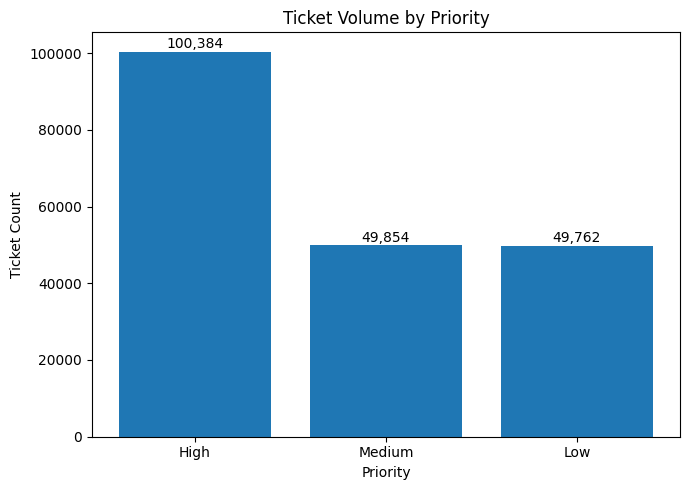

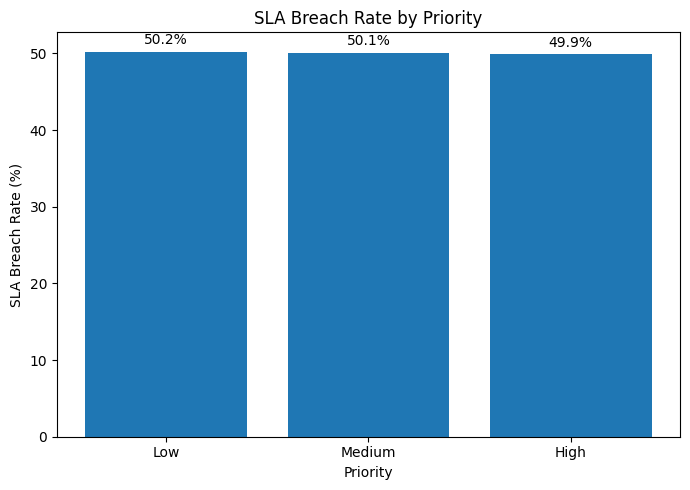

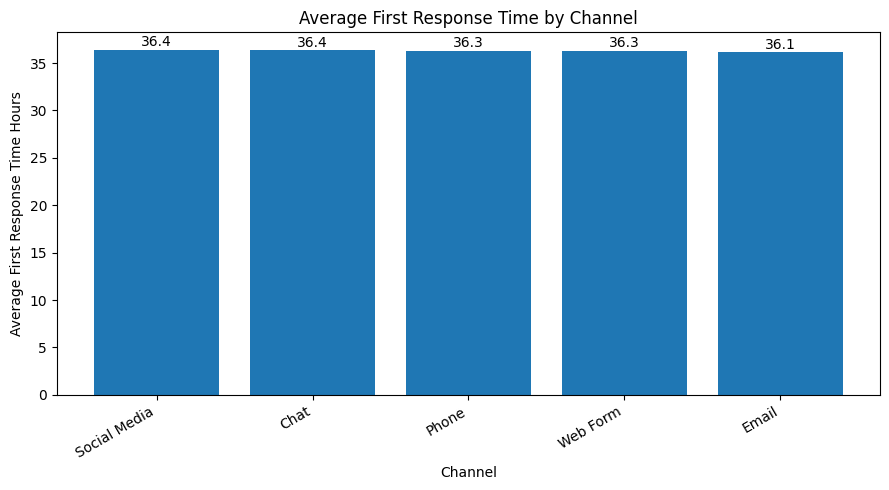

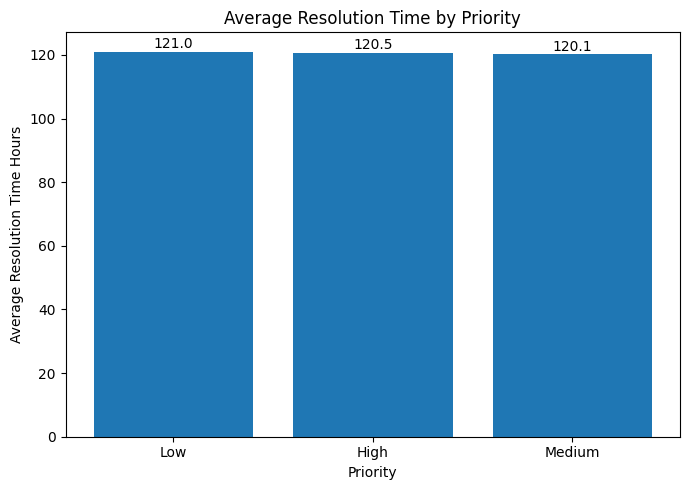

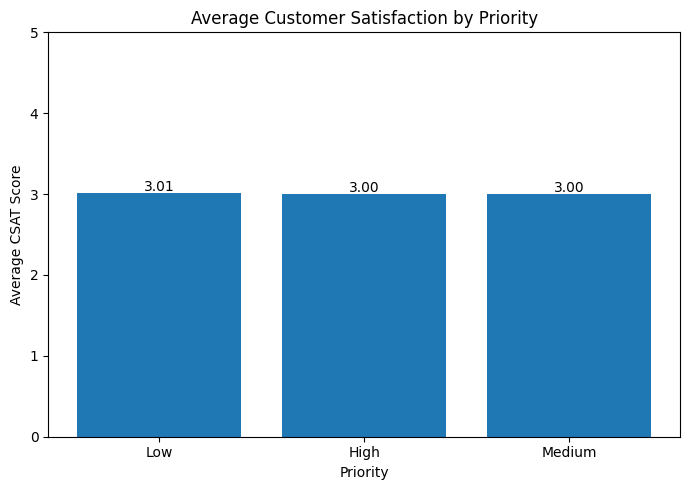

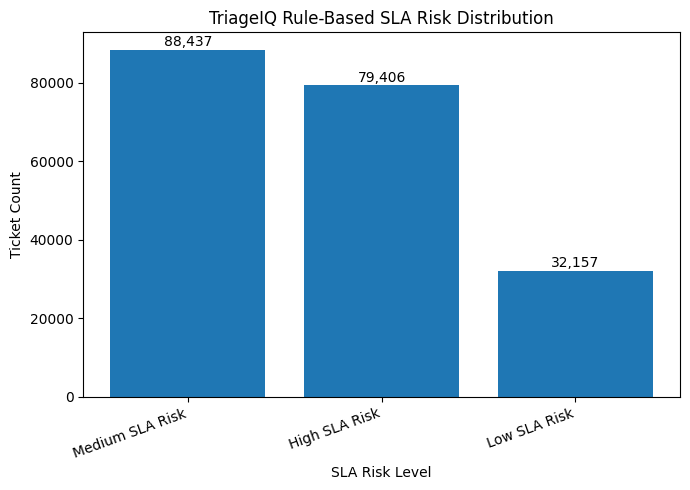

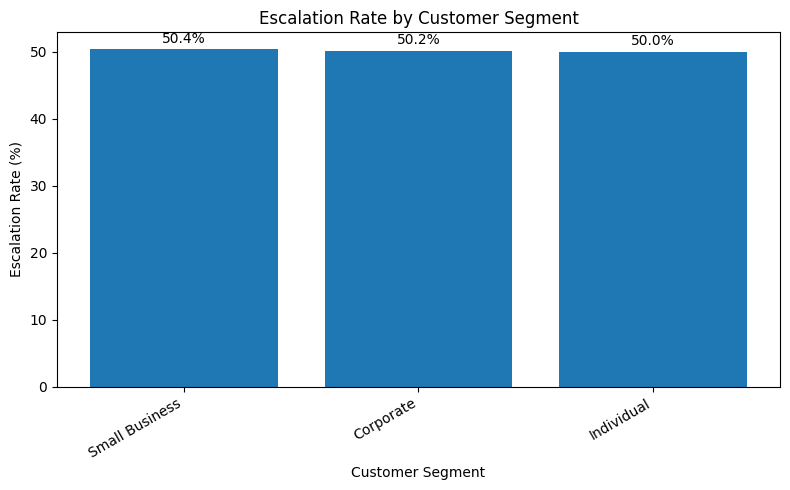


PART F: FINAL DEMO OUTPUT DISPLAY
Final Demo Prediction Summary:


,demo_id,subject,predicted_priority,priority_high_probability,predicted_routing_team,routing_confidence,sla_risk_level,final_recommendation,human_review_required
0,1,Payment gateway down for all customers,High,0.766,Billing,0.900,High SLA Risk,Escalate to human agent immediately,True
1,2,Need password reset,Needs Review,0.315,Technical / Product Support,0.900,Low SLA Risk,Send to human triage review before routing,True
2,3,Laptop screen flickering during meetings,Normal,0.116,Technical / Product Support,0.860,Medium SLA Risk,Assign quickly and monitor SLA,True
3,4,API returning 500 errors,High,0.592,Technical / Product Support,0.941,High SLA Risk,Escalate to human agent immediately,True
4,5,Question about invoice,Needs Review,0.230,Billing,0.900,Low SLA Risk,Send to human triage review before routing,True


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/final_demo_prediction_summary.csv

PART G: RESPONSIBLE AI SUMMARY
Responsible AI / Risk Mitigation Summary:


,risk_area,why_it_matters,mitigation
0,Missed high-priority tickets,A truly urgent customer issue may not be escal...,"Optimize for high recall, use Needs Review zon..."
1,Too many false high-priority alerts,Agents may become overloaded or ignore alerts.,Use High / Needs Review / Normal labels instea...
2,Wrong queue routing,A ticket sent to the wrong group may bounce be...,Use confidence thresholds. Auto-route only whe...
3,Weak SLA ML model,A weak predictive model can create misleading ...,Use transparent rule-based SLA scoring in the ...
4,Synthetic or anonymized data limitation,Synthetic datasets may be cleaner or more bala...,Label datasets clearly and treat results as pr...
5,Privacy and sensitive ticket content,"Tickets may contain names, emails, account IDs...",Remove unnecessary PII fields and redact sensi...
6,AI-generated response errors,"Drafted responses may be incomplete, incorrect...",Do not auto-send AI-generated responses; requi...
7,Data leakage,Using future workflow fields can make model pe...,Use only real-time-safe features for deploymen...
8,Language and fairness limitation,The model may perform differently across langu...,"Monitor performance by language, customer segm..."


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/final_responsible_ai_summary.csv

PART H: FINAL EXECUTIVE SUMMARY TABLE


,area,summary
0,Problem,"Support teams manually read, prioritize, route..."
1,Solution,TriageIQ is an AI-assisted support triage syst...
2,Priority Model,Uses ticket text to detect high-priority ticke...
3,Routing Model,Uses grouped business routing categories to re...
4,SLA Risk,Uses transparent rule-based scoring because op...
5,Human-in-the-Loop,AI outputs are recommendations. Human agents r...
6,Business Value,"Reduces manual triage effort, catches urgent t..."
7,Limitations,Some datasets are synthetic/anonymized; routin...


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/final_executive_summary.csv

PART I: FINAL OUTPUT FILE CHECK
Files saved in Output Datasets folder:
- final_business_kpi_cards.csv
- final_business_kpi_summary.csv
- final_demo_prediction_summary.csv
- final_executive_summary.csv
- final_model_comparison_summary.csv
- final_model_performance_all.csv
- final_project_narrative_summary.csv
- final_responsible_ai_summary.csv
- final_submission_checklist.csv
- routing_confidence_bucket_summary.csv
- routing_group_mapping.csv
- triageiq_app_config.csv
- triageiq_dashboard_data.csv
- triageiq_dashboard_data_with_rule_sla.csv
- triageiq_demo_predictions_with_responses.csv
- triageiq_demo_tickets.csv
Skipped intermediate file: final_output_file_check.csv

Models saved in Models folder:
- final_grouped_queue_routing_model.pkl
- final_priority_model.pkl
Skipped intermediate file: final_model_file_check.csv

PART J: FINAL SUBMISSION READINESS CHECKLIST


,deliverable,status,notes
0,PowerPoint Slides,Prepare separately,"Use final executive summary, model metrics, KP..."
1,Video of Team Presenting Slides,Prepare separately,Record team pitch and explanation of business ...
2,Project Report,Prepare separately,"Use final project narrative, business KPI summ..."
3,Code File / Notebook,Ready after final run,Submit this completed notebook or exported .py...
4,Software Demo Video,Prepare after Streamlit/app demo,Show user entering a ticket and TriageIQ retur...
5,Output CSV Files,Ready after final run,Files are saved in Output Datasets folder.
6,Saved Models,Ready after final run,Models are saved in Models folder.


Saved: /content/drive/MyDrive/BUDT 751 AI Project - Group 2/Datasets/Output Datasets/final_submission_checklist.csv

SECTION 8 COMPLETE: FINAL DASHBOARD, KPI, RESPONSIBLE AI, AND OUTPUT CHECKS READY


In [24]:
section_header("SECTION 8: FINAL DASHBOARD VISUALS, KPI SUMMARY, RESPONSIBLE AI, AND OUTPUT CHECK")


# PART A: PREPARE FINAL DASHBOARD DATA

section_header("PART A: PREPARE FINAL DASHBOARD DATA")

# Use dashboard_sla_df if available because it includes rule-based SLA risk.
# Otherwise fall back to support_dashboard_df.

if "dashboard_sla_df" in globals() and isinstance(dashboard_sla_df, pd.DataFrame) and not dashboard_sla_df.empty:
    final_dashboard_df = dashboard_sla_df.copy()
    print("Using dashboard_sla_df with rule-based SLA risk.")
elif "support_dashboard_df" in globals() and isinstance(support_dashboard_df, pd.DataFrame) and not support_dashboard_df.empty:
    final_dashboard_df = support_dashboard_df.copy()
    print("Using support_dashboard_df because dashboard_sla_df was not available.")
else:
    final_dashboard_df = pd.DataFrame()
    print("No dashboard dataset available.")

print("Final dashboard dataset shape:")
print(final_dashboard_df.shape)

if not final_dashboard_df.empty:
    display_table(
        final_dashboard_df,
        title="Final Dashboard Dataset Preview",
        max_rows=5
    )

    save_output(final_dashboard_df, "triageiq_dashboard_data.csv")


# PART B: FINAL BUSINESS KPI CARDS

section_header("PART B: FINAL BUSINESS KPI CARDS")

kpi_cards = []

if not final_dashboard_df.empty:

    kpi_cards.append({
        "kpi": "Total Tickets",
        "value": f"{len(final_dashboard_df):,}",
        "business_meaning": "Total support tickets available for dashboard analysis."
    })

    if "sla_breached_binary" in final_dashboard_df.columns:
        kpi_cards.append({
            "kpi": "SLA Breach Rate",
            "value": f"{final_dashboard_df['sla_breached_binary'].mean() * 100:.2f}%",
            "business_meaning": "Percentage of tickets that missed the promised support deadline."
        })

    if "escalated_binary" in final_dashboard_df.columns:
        kpi_cards.append({
            "kpi": "Escalation Rate",
            "value": f"{final_dashboard_df['escalated_binary'].mean() * 100:.2f}%",
            "business_meaning": "Percentage of tickets escalated for additional support."
        })

    if "first_response_time_hours" in final_dashboard_df.columns:
        kpi_cards.append({
            "kpi": "Average First Response Time",
            "value": f"{final_dashboard_df['first_response_time_hours'].mean():.2f} hours",
            "business_meaning": "Average time before the first response to the customer."
        })

    if "resolution_time_hours" in final_dashboard_df.columns:
        kpi_cards.append({
            "kpi": "Average Resolution Time",
            "value": f"{final_dashboard_df['resolution_time_hours'].mean():.2f} hours",
            "business_meaning": "Average time taken to resolve support tickets."
        })

    if "customer_satisfaction_score" in final_dashboard_df.columns:
        kpi_cards.append({
            "kpi": "Average Customer Satisfaction",
            "value": f"{final_dashboard_df['customer_satisfaction_score'].mean():.2f} / 5",
            "business_meaning": "Average customer satisfaction score across tickets."
        })

    if "sla_risk_level" in final_dashboard_df.columns:
        high_sla_risk_rate = (
            final_dashboard_df["sla_risk_level"]
            .eq("High SLA Risk")
            .mean() * 100
        )

        kpi_cards.append({
            "kpi": "High SLA Risk Tickets",
            "value": f"{high_sla_risk_rate:.2f}%",
            "business_meaning": "Percentage of tickets flagged as high SLA risk by TriageIQ."
        })

business_kpi_cards_df = pd.DataFrame(kpi_cards)

print("Business KPI Cards:")
display(business_kpi_cards_df)

save_output(business_kpi_cards_df, "final_business_kpi_cards.csv")


# PART C: BUSINESS KPI IMPACT SUMMARY

section_header("PART C: BUSINESS KPI IMPACT SUMMARY")

business_kpi_summary_df = pd.DataFrame([
    {
        "business_kpi": "First Response Time",
        "current_problem": "Agents spend time manually reading, routing, and drafting responses.",
        "how_triageiq_helps": "TriageIQ predicts priority, recommends routing, and drafts a response immediately.",
        "measurement_method": "Compare average first response time before vs. after TriageIQ."
    },
    {
        "business_kpi": "Missed High-Priority Tickets",
        "current_problem": "Urgent tickets can be buried inside the queue and handled too late.",
        "how_triageiq_helps": "The high-priority detection model flags urgent tickets for faster human review.",
        "measurement_method": "Track high-priority recall and false negative rate."
    },
    {
        "business_kpi": "Routing Accuracy",
        "current_problem": "Wrong routing causes handoffs, delays, and repeated triage work.",
        "how_triageiq_helps": "The grouped routing model recommends the correct broad support group.",
        "measurement_method": "Compare AI-recommended route with final human-approved route."
    },
    {
        "business_kpi": "SLA Breach Risk",
        "current_problem": "Managers may not know which tickets are likely to become late.",
        "how_triageiq_helps": "The SLA risk score flags tickets needing faster attention.",
        "measurement_method": "Track SLA breach rate, high-risk ticket outcomes, and escalation delay."
    },
    {
        "business_kpi": "Agent Workload",
        "current_problem": "Support agents spend time on repetitive triage and first-response writing.",
        "how_triageiq_helps": "AI assists with classification, routing, and draft response generation.",
        "measurement_method": "Estimate minutes saved per ticket and total monthly hours saved."
    },
    {
        "business_kpi": "Customer Satisfaction",
        "current_problem": "Slow response and poor routing reduce customer trust.",
        "how_triageiq_helps": "Faster acknowledgement and better routing can improve customer experience.",
        "measurement_method": "Compare CSAT before vs. after TriageIQ deployment."
    }
])

print("Business KPI Impact Summary:")
display(business_kpi_summary_df)

save_output(business_kpi_summary_df, "final_business_kpi_summary.csv")


# PART D: FINAL MODEL PERFORMANCE SUMMARY

section_header("PART D: FINAL MODEL PERFORMANCE SUMMARY")

model_performance_tables = []

# Priority model summary
if "priority_config_df" in globals() and isinstance(priority_config_df, pd.DataFrame) and not priority_config_df.empty:
    priority_perf = priority_config_df.copy()
    priority_perf["component"] = "High Priority Detection"
    model_performance_tables.append(priority_perf)

# Baseline routing summary
if "baseline_queue_metrics_df" in globals() and isinstance(baseline_queue_metrics_df, pd.DataFrame) and not baseline_queue_metrics_df.empty:
    baseline_route_perf = baseline_queue_metrics_df.copy()
    baseline_route_perf["component"] = "Baseline Original Queue Routing"
    model_performance_tables.append(baseline_route_perf)

# Improved grouped routing summary
if "final_grouped_routing_metrics_df" in globals() and isinstance(final_grouped_routing_metrics_df, pd.DataFrame) and not final_grouped_routing_metrics_df.empty:
    grouped_route_perf = final_grouped_routing_metrics_df.copy()
    grouped_route_perf["component"] = "Improved Grouped Queue Routing"
    model_performance_tables.append(grouped_route_perf)

# SLA comparison
if "sla_model_comparison_df" in globals() and isinstance(sla_model_comparison_df, pd.DataFrame) and not sla_model_comparison_df.empty:
    sla_perf = sla_model_comparison_df.copy()
    sla_perf["component"] = "Optional SLA ML Models"
    model_performance_tables.append(sla_perf)

if model_performance_tables:
    final_model_performance_all_df = pd.concat(model_performance_tables, ignore_index=True, sort=False)
else:
    final_model_performance_all_df = pd.DataFrame()

print("Final Model Performance Summary:")
display(final_model_performance_all_df)

save_output(final_model_performance_all_df, "final_model_performance_all.csv")


# PART E: CLEAN DASHBOARD VISUALS

section_header("PART E: CLEAN DASHBOARD VISUALS")

if not final_dashboard_df.empty:

    # 1. Ticket volume by priority

    if "priority_3class" in final_dashboard_df.columns:
        priority_counts = final_dashboard_df["priority_3class"].value_counts()

        plt.figure(figsize=(7, 5))
        plt.bar(priority_counts.index.astype(str), priority_counts.values)
        plt.title("Ticket Volume by Priority")
        plt.xlabel("Priority")
        plt.ylabel("Ticket Count")

        for i, v in enumerate(priority_counts.values):
            plt.text(i, v + max(priority_counts.values) * 0.01, f"{v:,}", ha="center")

        plt.tight_layout()
        plt.show()

    # 2. SLA breach rate by priority

    if "priority_3class" in final_dashboard_df.columns and "sla_breached_binary" in final_dashboard_df.columns:
        sla_by_priority = (
            final_dashboard_df
            .groupby("priority_3class")["sla_breached_binary"]
            .mean()
            .sort_values(ascending=False) * 100
        )

        plt.figure(figsize=(7, 5))
        plt.bar(sla_by_priority.index.astype(str), sla_by_priority.values)
        plt.title("SLA Breach Rate by Priority")
        plt.xlabel("Priority")
        plt.ylabel("SLA Breach Rate (%)")

        for i, v in enumerate(sla_by_priority.values):
            plt.text(i, v + 1, f"{v:.1f}%", ha="center")

        plt.tight_layout()
        plt.show()

    # 3. Average first response time by channel

    if "channel" in final_dashboard_df.columns and "first_response_time_hours" in final_dashboard_df.columns:
        response_by_channel = (
            final_dashboard_df
            .groupby("channel")["first_response_time_hours"]
            .mean()
            .sort_values(ascending=False)
        )

        plt.figure(figsize=(9, 5))
        plt.bar(response_by_channel.index.astype(str), response_by_channel.values)
        plt.title("Average First Response Time by Channel")
        plt.xlabel("Channel")
        plt.ylabel("Average First Response Time Hours")
        plt.xticks(rotation=30, ha="right")

        for i, v in enumerate(response_by_channel.values):
            plt.text(i, v + max(response_by_channel.values) * 0.01, f"{v:.1f}", ha="center")

        plt.tight_layout()
        plt.show()

    # 4. Average resolution time by priority

    if "priority_3class" in final_dashboard_df.columns and "resolution_time_hours" in final_dashboard_df.columns:
        resolution_by_priority = (
            final_dashboard_df
            .groupby("priority_3class")["resolution_time_hours"]
            .mean()
            .sort_values(ascending=False)
        )

        plt.figure(figsize=(7, 5))
        plt.bar(resolution_by_priority.index.astype(str), resolution_by_priority.values)
        plt.title("Average Resolution Time by Priority")
        plt.xlabel("Priority")
        plt.ylabel("Average Resolution Time Hours")

        for i, v in enumerate(resolution_by_priority.values):
            plt.text(i, v + max(resolution_by_priority.values) * 0.01, f"{v:.1f}", ha="center")

        plt.tight_layout()
        plt.show()

    # 5. Customer satisfaction by priority

    if "priority_3class" in final_dashboard_df.columns and "customer_satisfaction_score" in final_dashboard_df.columns:
        satisfaction_by_priority = (
            final_dashboard_df
            .groupby("priority_3class")["customer_satisfaction_score"]
            .mean()
            .sort_values(ascending=False)
        )

        plt.figure(figsize=(7, 5))
        plt.bar(satisfaction_by_priority.index.astype(str), satisfaction_by_priority.values)
        plt.title("Average Customer Satisfaction by Priority")
        plt.xlabel("Priority")
        plt.ylabel("Average CSAT Score")

        for i, v in enumerate(satisfaction_by_priority.values):
            plt.text(i, v + 0.03, f"{v:.2f}", ha="center")

        plt.ylim(0, 5)
        plt.tight_layout()
        plt.show()

    # 6. Rule-based SLA risk distribution

    if "sla_risk_level" in final_dashboard_df.columns:
        sla_risk_counts = final_dashboard_df["sla_risk_level"].value_counts()

        plt.figure(figsize=(7, 5))
        plt.bar(sla_risk_counts.index.astype(str), sla_risk_counts.values)
        plt.title("TriageIQ Rule-Based SLA Risk Distribution")
        plt.xlabel("SLA Risk Level")
        plt.ylabel("Ticket Count")
        plt.xticks(rotation=20, ha="right")

        for i, v in enumerate(sla_risk_counts.values):
            plt.text(i, v + max(sla_risk_counts.values) * 0.01, f"{v:,}", ha="center")

        plt.tight_layout()
        plt.show()

    # 7. Escalation rate by customer segment

    if "customer_segment" in final_dashboard_df.columns and "escalated_binary" in final_dashboard_df.columns:
        escalation_by_segment = (
            final_dashboard_df
            .groupby("customer_segment")["escalated_binary"]
            .mean()
            .sort_values(ascending=False) * 100
        )

        plt.figure(figsize=(8, 5))
        plt.bar(escalation_by_segment.index.astype(str), escalation_by_segment.values)
        plt.title("Escalation Rate by Customer Segment")
        plt.xlabel("Customer Segment")
        plt.ylabel("Escalation Rate (%)")
        plt.xticks(rotation=30, ha="right")

        for i, v in enumerate(escalation_by_segment.values):
            plt.text(i, v + 1, f"{v:.1f}%", ha="center")

        plt.tight_layout()
        plt.show()

else:
    print("No dashboard data available for visuals.")


# PART F: FINAL DEMO OUTPUT DISPLAY

section_header("PART F: FINAL DEMO OUTPUT DISPLAY")

if "demo_predictions_df" in globals() and isinstance(demo_predictions_df, pd.DataFrame) and not demo_predictions_df.empty:

    demo_display_cols = [
        "demo_id",
        "subject",
        "predicted_priority",
        "priority_high_probability",
        "predicted_routing_team",
        "routing_confidence",
        "sla_risk_level",
        "final_recommendation",
        "human_review_required"
    ]

    demo_display_cols = [col for col in demo_display_cols if col in demo_predictions_df.columns]

    demo_clean_display_df = demo_predictions_df[demo_display_cols].copy()

    if "priority_high_probability" in demo_clean_display_df.columns:
        demo_clean_display_df["priority_high_probability"] = demo_clean_display_df["priority_high_probability"].round(3)

    if "routing_confidence" in demo_clean_display_df.columns:
        demo_clean_display_df["routing_confidence"] = demo_clean_display_df["routing_confidence"].round(3)

    print("Final Demo Prediction Summary:")
    display(demo_clean_display_df)

    save_output(demo_clean_display_df, "final_demo_prediction_summary.csv")

else:
    print("demo_predictions_df not available.")


# PART G: RESPONSIBLE AI SUMMARY

section_header("PART G: RESPONSIBLE AI SUMMARY")

responsible_ai_summary_df = pd.DataFrame([
    {
        "risk_area": "Missed high-priority tickets",
        "why_it_matters": "A truly urgent customer issue may not be escalated quickly.",
        "mitigation": "Optimize for high recall, use Needs Review zone, and require human escalation workflow."
    },
    {
        "risk_area": "Too many false high-priority alerts",
        "why_it_matters": "Agents may become overloaded or ignore alerts.",
        "mitigation": "Use High / Needs Review / Normal labels instead of forcing every case into High or Not High."
    },
    {
        "risk_area": "Wrong queue routing",
        "why_it_matters": "A ticket sent to the wrong group may bounce between teams and take longer to resolve.",
        "mitigation": "Use confidence thresholds. Auto-route only when confidence is high; otherwise require human review."
    },
    {
        "risk_area": "Weak SLA ML model",
        "why_it_matters": "A weak predictive model can create misleading risk scores.",
        "mitigation": "Use transparent rule-based SLA scoring in the prototype and state this limitation clearly."
    },
    {
        "risk_area": "Synthetic or anonymized data limitation",
        "why_it_matters": "Synthetic datasets may be cleaner or more balanced than real customer support data.",
        "mitigation": "Label datasets clearly and treat results as prototype evidence, not production performance."
    },
    {
        "risk_area": "Privacy and sensitive ticket content",
        "why_it_matters": "Tickets may contain names, emails, account IDs, IPs, logs, or other sensitive information.",
        "mitigation": "Remove unnecessary PII fields and redact sensitive text before using AI systems."
    },
    {
        "risk_area": "AI-generated response errors",
        "why_it_matters": "Drafted responses may be incomplete, incorrect, or too confident.",
        "mitigation": "Do not auto-send AI-generated responses; require support agent review before sending."
    },
    {
        "risk_area": "Data leakage",
        "why_it_matters": "Using future workflow fields can make model performance look better than real deployment performance.",
        "mitigation": "Use only real-time-safe features for deployment-facing models."
    },
    {
        "risk_area": "Language and fairness limitation",
        "why_it_matters": "The model may perform differently across languages, customer groups, or ticket styles.",
        "mitigation": "Monitor performance by language, customer segment, and channel before production deployment."
    }
])

print("Responsible AI / Risk Mitigation Summary:")
display(responsible_ai_summary_df)

save_output(responsible_ai_summary_df, "final_responsible_ai_summary.csv")


# PART H: FINAL EXECUTIVE SUMMARY TABLE

section_header("PART H: FINAL EXECUTIVE SUMMARY TABLE")

final_executive_summary_df = pd.DataFrame([
    {
        "area": "Problem",
        "summary": "Support teams manually read, prioritize, route, and respond to tickets, creating delays and inconsistent handling."
    },
    {
        "area": "Solution",
        "summary": "TriageIQ is an AI-assisted support triage system that predicts priority, recommends routing, scores SLA risk, and drafts first responses."
    },
    {
        "area": "Priority Model",
        "summary": "Uses ticket text to detect high-priority tickets. Optimized for recall because missing urgent tickets is more costly than reviewing extra tickets."
    },
    {
        "area": "Routing Model",
        "summary": "Uses grouped business routing categories to reduce label overlap and improve routing reliability."
    },
    {
        "area": "SLA Risk",
        "summary": "Uses transparent rule-based scoring because optional SLA ML models did not show strong predictive signal."
    },
    {
        "area": "Human-in-the-Loop",
        "summary": "AI outputs are recommendations. Human agents review routing decisions and response drafts before action."
    },
    {
        "area": "Business Value",
        "summary": "Reduces manual triage effort, catches urgent tickets earlier, improves routing consistency, and speeds up customer acknowledgement."
    },
    {
        "area": "Limitations",
        "summary": "Some datasets are synthetic/anonymized; routing uses broader groups; production use would require real company data, monitoring, and retraining."
    }
])

display(final_executive_summary_df)

save_output(final_executive_summary_df, "final_executive_summary.csv")


# PART I: FINAL OUTPUT FILE CHECK

section_header("PART I: FINAL OUTPUT FILE CHECK")

print("Files saved in Output Datasets folder:")
if os.path.exists(OUTPUT_FOLDER):
    output_files = sorted(os.listdir(OUTPUT_FOLDER))

    for file_name in output_files:
        print("-", file_name)

    output_file_check_df = pd.DataFrame({
        "file_name": output_files,
        "folder": OUTPUT_FOLDER
    })

    save_output(output_file_check_df, "final_output_file_check.csv")
else:
    print("Output folder does not exist.")

print("\nModels saved in Models folder:")
if os.path.exists(MODEL_FOLDER):
    model_files = sorted(os.listdir(MODEL_FOLDER))

    for file_name in model_files:
        print("-", file_name)

    model_file_check_df = pd.DataFrame({
        "model_file_name": model_files,
        "folder": MODEL_FOLDER
    })

    save_output(model_file_check_df, "final_model_file_check.csv")
else:
    print("Model folder does not exist.")


# PART J: FINAL SUBMISSION READINESS CHECKLIST

section_header("PART J: FINAL SUBMISSION READINESS CHECKLIST")

final_submission_checklist_df = pd.DataFrame([
    {
        "deliverable": "PowerPoint Slides",
        "status": "Prepare separately",
        "notes": "Use final executive summary, model metrics, KPI summary, and demo screenshots."
    },
    {
        "deliverable": "Video of Team Presenting Slides",
        "status": "Prepare separately",
        "notes": "Record team pitch and explanation of business problem, AI workflow, model performance, and demo."
    },
    {
        "deliverable": "Project Report",
        "status": "Prepare separately",
        "notes": "Use final project narrative, business KPI summary, responsible AI summary, and limitations."
    },
    {
        "deliverable": "Code File / Notebook",
        "status": "Ready after final run",
        "notes": "Submit this completed notebook or exported .py file."
    },
    {
        "deliverable": "Software Demo Video",
        "status": "Prepare after Streamlit/app demo",
        "notes": "Show user entering a ticket and TriageIQ returning priority, routing, SLA risk, recommendation, and response draft."
    },
    {
        "deliverable": "Output CSV Files",
        "status": "Ready after final run",
        "notes": "Files are saved in Output Datasets folder."
    },
    {
        "deliverable": "Saved Models",
        "status": "Ready after final run",
        "notes": "Models are saved in Models folder."
    }
])

display(final_submission_checklist_df)

save_output(final_submission_checklist_df, "final_submission_checklist.csv")


section_header("SECTION 8 COMPLETE: FINAL DASHBOARD, KPI, RESPONSIBLE AI, AND OUTPUT CHECKS READY")


# ONLY FOR DISPLAYING OUTPUTS: GRAPHS / CHARTS etc.

In [25]:
# Final optional visual showcase section
# This section only displays important final project results in a clean format.
# It does not change model training, saved files, or project logic.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except Exception:
    PLOTLY_AVAILABLE = False
    print("Plotly not available. Falling back to matplotlib charts.")

from IPython.display import display, Markdown, HTML


# Helper function to show clean section titles
def show_section(title, description=None):
    display(Markdown(f"## {title}"))
    if description:
        display(Markdown(description))


# Helper function to safely get an existing dataframe from notebook memory
def get_existing_dataframe(variable_name):
    if variable_name in globals():
        obj = globals()[variable_name]
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            return obj.copy()
    return pd.DataFrame()


# Helper function to style tables
def show_table(df, caption=None, max_rows=None):
    if df.empty:
        print("No data available.")
        return

    display_df = df.copy()

    if max_rows is not None and len(display_df) > max_rows:
        display_df = display_df.head(max_rows)

    styled = (
        display_df.style
        .set_properties(**{
            "text-align": "left",
            "border": "1px solid #ddd",
            "padding": "6px"
        })
        .set_table_styles([
            {
                "selector": "th",
                "props": [
                    ("background-color", "#f2f2f2"),
                    ("font-weight", "bold"),
                    ("text-align", "left"),
                    ("border", "1px solid #ddd"),
                    ("padding", "6px")
                ]
            },
            {
                "selector": "caption",
                "props": [
                    ("caption-side", "top"),
                    ("font-size", "16px"),
                    ("font-weight", "bold"),
                    ("text-align", "left")
                ]
            }
        ])
    )

    if caption:
        styled = styled.set_caption(caption)

    display(styled)


# Helper function to create a clean count table
def create_count_table(df, column):
    if df.empty or column not in df.columns:
        return pd.DataFrame()

    output = (
        df[column]
        .fillna("Missing")
        .astype(str)
        .value_counts()
        .reset_index()
    )

    output.columns = [column, "count"]
    output["percent"] = (output["count"] / output["count"].sum() * 100).round(2)

    return output


# Helper function for one clean bar chart
def show_bar_chart(df, x_col, y_col, title, x_title=None, y_title=None):
    if df.empty or x_col not in df.columns or y_col not in df.columns:
        print(f"Cannot display chart: {title}")
        return

    if PLOTLY_AVAILABLE:
        fig = px.bar(
            df,
            x=x_col,
            y=y_col,
            text=y_col,
            title=title
        )

        fig.update_traces(textposition="outside")

        fig.update_layout(
            xaxis_title=x_title if x_title else x_col,
            yaxis_title=y_title if y_title else y_col,
            height=430,
            margin=dict(l=40, r=40, t=80, b=80),
            showlegend=False
        )

        fig.show()

    else:
        plt.figure(figsize=(9, 5))
        plt.bar(df[x_col].astype(str), df[y_col])
        plt.title(title)
        plt.xlabel(x_title if x_title else x_col)
        plt.ylabel(y_title if y_title else y_col)
        plt.xticks(rotation=30, ha="right")

        for i, v in enumerate(df[y_col]):
            plt.text(i, v, str(round(v, 2)), ha="center", va="bottom")

        plt.tight_layout()
        plt.show()


# Main function to display the final project results
def display_triageiq_final_visual_report():

    dashboard_df = get_existing_dataframe("final_dashboard_df")

    if dashboard_df.empty:
        dashboard_df = get_existing_dataframe("dashboard_sla_df")

    if dashboard_df.empty:
        dashboard_df = get_existing_dataframe("support_dashboard_df")

    kpi_cards_df = get_existing_dataframe("business_kpi_cards_df")
    model_summary_df = get_existing_dataframe("final_model_comparison_summary_df")
    model_performance_df = get_existing_dataframe("final_model_performance_all_df")
    demo_df = get_existing_dataframe("demo_predictions_df")
    confidence_df = get_existing_dataframe("confidence_bucket_summary_df")
    responsible_ai_df = get_existing_dataframe("responsible_ai_summary_df")
    executive_summary_df = get_existing_dataframe("final_executive_summary_df")

    display(Markdown("# TriageIQ Final Results Showcase"))
    display(Markdown(
        "This section displays the most important final project outputs in a clean stakeholder-friendly format. "
        "It uses the final variables already created in the notebook and does not modify any model or saved file."
    ))

    # Executive summary
    show_section(
        "1. Executive Summary",
        "This table summarizes the project problem, solution, business value, and limitations."
    )

    if not executive_summary_df.empty:
        show_table(executive_summary_df, "Final Executive Summary")
    else:
        display(Markdown(
            "**TriageIQ** is an AI-assisted support ticket triage system that predicts priority, "
            "routes tickets, scores SLA risk, and drafts first responses for human review."
        ))

    # KPI cards
    show_section(
        "2. Business KPI Cards",
        "These cards summarize the main support operations metrics used in the project."
    )

    if not kpi_cards_df.empty:
        cards_html = """
        <div style="display: flex; flex-wrap: wrap; gap: 16px;">
        """

        for _, row in kpi_cards_df.iterrows():
            cards_html += f"""
            <div style="
                border: 1px solid #ddd;
                border-radius: 12px;
                padding: 16px;
                width: 230px;
                background-color: #fafafa;
                box-shadow: 1px 1px 4px rgba(0,0,0,0.08);
            ">
                <h4 style="margin-bottom: 8px;">{row.get('kpi', '')}</h4>
                <h2 style="margin: 0; color: #1f77b4;">{row.get('value', '')}</h2>
                <p style="font-size: 13px; color: #555;">{row.get('business_meaning', '')}</p>
            </div>
            """

        cards_html += "</div>"
        display(HTML(cards_html))
    else:
        print("KPI cards dataframe not available.")

    # Dashboard overview
    show_section(
        "3. Support Ticket Dashboard Overview",
        "This section shows the most useful operational charts from the dashboard dataset."
    )

    if not dashboard_df.empty:
        show_table(dashboard_df.head(10), "Dashboard Data Preview")

        if "priority_3class" in dashboard_df.columns:
            priority_count_df = create_count_table(dashboard_df, "priority_3class")

            show_bar_chart(
                priority_count_df,
                x_col="priority_3class",
                y_col="count",
                title="Ticket Volume by Priority",
                x_title="Priority",
                y_title="Ticket Count"
            )

        if "sla_risk_level" in dashboard_df.columns:
            sla_risk_df = create_count_table(dashboard_df, "sla_risk_level")

            show_bar_chart(
                sla_risk_df,
                x_col="sla_risk_level",
                y_col="count",
                title="Rule-Based SLA Risk Distribution",
                x_title="SLA Risk Level",
                y_title="Ticket Count"
            )

        if "priority_3class" in dashboard_df.columns and "sla_breached_binary" in dashboard_df.columns:
            sla_by_priority_df = (
                dashboard_df
                .groupby("priority_3class")["sla_breached_binary"]
                .mean()
                .reset_index()
            )

            sla_by_priority_df["sla_breach_rate_percent"] = (
                sla_by_priority_df["sla_breached_binary"] * 100
            ).round(2)

            show_bar_chart(
                sla_by_priority_df,
                x_col="priority_3class",
                y_col="sla_breach_rate_percent",
                title="SLA Breach Rate by Priority",
                x_title="Priority",
                y_title="SLA Breach Rate (%)"
            )

        if "channel" in dashboard_df.columns and "first_response_time_hours" in dashboard_df.columns:
            response_by_channel_df = (
                dashboard_df
                .groupby("channel")["first_response_time_hours"]
                .mean()
                .sort_values(ascending=False)
                .reset_index()
            )

            response_by_channel_df["first_response_time_hours"] = (
                response_by_channel_df["first_response_time_hours"].round(2)
            )

            show_bar_chart(
                response_by_channel_df,
                x_col="channel",
                y_col="first_response_time_hours",
                title="Average First Response Time by Channel",
                x_title="Channel",
                y_title="Average First Response Time Hours"
            )
    else:
        print("Dashboard dataframe not available.")

    # Model summary
    show_section(
        "4. Final Model and Component Summary",
        "This table summarizes the final TriageIQ components and their main business value."
    )

    if not model_summary_df.empty:
        show_table(model_summary_df, "Final Model Component Summary")

    if not model_performance_df.empty:
        show_table(model_performance_df, "Detailed Model Performance Table", max_rows=10)

    # Routing confidence
    show_section(
        "5. Routing Confidence Analysis",
        "This chart shows why TriageIQ uses human review when routing confidence is low or medium."
    )

    if not confidence_df.empty:
        show_table(confidence_df, "Routing Confidence Bucket Summary")

        if "confidence_bucket" in confidence_df.columns and "accuracy" in confidence_df.columns:
            show_bar_chart(
                confidence_df,
                x_col="confidence_bucket",
                y_col="accuracy",
                title="Routing Accuracy by Confidence Bucket",
                x_title="Confidence Bucket",
                y_title="Accuracy (%)"
            )
    else:
        print("Routing confidence summary not available.")

    # Demo predictions
    show_section(
        "6. Final Demo Predictions",
        "These are sample tickets processed through the final TriageIQ workflow."
    )

    if not demo_df.empty:
        demo_cols = [
            "demo_id",
            "subject",
            "predicted_priority",
            "priority_high_probability",
            "predicted_routing_team",
            "routing_confidence",
            "routing_method",
            "sla_risk_level",
            "final_recommendation",
            "human_review_required"
        ]

        demo_cols = [col for col in demo_cols if col in demo_df.columns]

        show_table(demo_df[demo_cols], "Final Demo Prediction Summary")

        if "predicted_priority" in demo_df.columns:
            demo_priority_df = create_count_table(demo_df, "predicted_priority")

            show_bar_chart(
                demo_priority_df,
                x_col="predicted_priority",
                y_col="count",
                title="Demo Tickets by Predicted Priority",
                x_title="Predicted Priority",
                y_title="Ticket Count"
            )

        if "first_response_draft" in demo_df.columns:
            display(Markdown("### Generated First-Response Drafts"))

            for _, row in demo_df.iterrows():
                ticket_id = row.get("demo_id", "")
                subject = row.get("subject", "")
                draft = row.get("first_response_draft", "")

                display(Markdown(f"#### Ticket {ticket_id}: {subject}"))
                display(Markdown(f"```text\n{draft}\n```"))
    else:
        print("Demo predictions dataframe not available.")

    # Responsible AI
    show_section(
        "7. Responsible AI and Risk Mitigation",
        "This table explains the key risks of using AI for support triage and how the project addresses them."
    )

    if not responsible_ai_df.empty:
        show_table(responsible_ai_df, "Responsible AI Summary")
    else:
        print("Responsible AI summary not available.")


# Run the final visual report
display_triageiq_final_visual_report()

# TriageIQ Final Results Showcase

This section displays the most important final project outputs in a clean stakeholder-friendly format. It uses the final variables already created in the notebook and does not modify any model or saved file.

## 1. Executive Summary

This table summarizes the project problem, solution, business value, and limitations.

,area,summary
0,Problem,"Support teams manually read, prioritize, route, and respond to tickets, creating delays and inconsistent handling."
1,Solution,"TriageIQ is an AI-assisted support triage system that predicts priority, recommends routing, scores SLA risk, and drafts first responses."
2,Priority Model,Uses ticket text to detect high-priority tickets. Optimized for recall because missing urgent tickets is more costly than reviewing extra tickets.
3,Routing Model,Uses grouped business routing categories to reduce label overlap and improve routing reliability.
4,SLA Risk,Uses transparent rule-based scoring because optional SLA ML models did not show strong predictive signal.
5,Human-in-the-Loop,AI outputs are recommendations. Human agents review routing decisions and response drafts before action.
6,Business Value,"Reduces manual triage effort, catches urgent tickets earlier, improves routing consistency, and speeds up customer acknowledgement."
7,Limitations,"Some datasets are synthetic/anonymized; routing uses broader groups; production use would require real company data, monitoring, and retraining."


...

#### Ticket 5: Question about invoice

```text
Hello,

Thank you for reaching out. We have received your ticket and are flagging it for careful review.

We have received your ticket regarding: "Question about invoice".

We are routing this to the Billing team and flagging it for review. A support agent will verify the details and make sure it is handled within the expected service window.

To help us review this faster, please share the invoice number, payment reference, transaction date, or a screenshot of the charge if available.

Best regards,
TriageIQ Support Team
```

## 7. Responsible AI and Risk Mitigation

This table explains the key risks of using AI for support triage and how the project addresses them.

,risk_area,why_it_matters,mitigation
0,Missed high-priority tickets,A truly urgent customer issue may not be escalated quickly.,"Optimize for high recall, use Needs Review zone, and require human escalation workflow."
1,Too many false high-priority alerts,Agents may become overloaded or ignore alerts.,Use High / Needs Review / Normal labels instead of forcing every case into High or Not High.
2,Wrong queue routing,A ticket sent to the wrong group may bounce between teams and take longer to resolve.,Use confidence thresholds. Auto-route only when confidence is high; otherwise require human review.
3,Weak SLA ML model,A weak predictive model can create misleading risk scores.,Use transparent rule-based SLA scoring in the prototype and state this limitation clearly.
4,Synthetic or anonymized data limitation,Synthetic datasets may be cleaner or more balanced than real customer support data.,"Label datasets clearly and treat results as prototype evidence, not production performance."
5,Privacy and sensitive ticket content,"Tickets may contain names, emails, account IDs, IPs, logs, or other sensitive information.",Remove unnecessary PII fields and redact sensitive text before using AI systems.
6,AI-generated response errors,"Drafted responses may be incomplete, incorrect, or too confident.",Do not auto-send AI-generated responses; require support agent review before sending.
7,Data leakage,Using future workflow fields can make model performance look better than real deployment performance.,Use only real-time-safe features for deployment-facing models.
8,Language and fairness limitation,"The model may perform differently across languages, customer groups, or ticket styles.","Monitor performance by language, customer segment, and channel before production deployment."


## Conclusion
TriageIQ demonstrates a complete AI-assisted support triage workflow. The final system predicts ticket priority, recommends a support routing group, scores SLA risk using transparent business rules, and generates a response draft for human review.

The strongest technical result is the improved grouped routing model and the confidence-based routing logic. The system is designed as an agent-assist tool, not a fully automated replacement for support agents.